# Utils

In [1]:
import argparse
import glob
from pathlib import Path
import xarray as xr
import numpy.ma as ma
import sys
import os
#import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import cmocean
sys.argv = [""]
mask = np.load('../utils/mask_nanuk1.npy')[:-1]
print(np.shape(mask))
area = np.load('../utils/area_nanuk1.npy')[:,5:-5]
print(np.shape(area))

import matplotlib.pyplot as plt
import cmocean
plt.style.use('../utils/work.mplstyle')
#mask = np.load("data/mask_SIL_regions.npy")
mask = np.load("../utils/mask_nanuk1.npy")[:-1]
mask_nan = mask.astype(float)        # make sure it’s float
mask_nan[mask_nan == 0] = np.nan     # replace 0 with NaN
print(np.shape(mask_nan))
mask_CA = np.load("../utils/mask_reduced_CA.npy")[:,5:-5]
mask_CA_nan = mask_CA.astype(float)        # make sure it’s float
mask_CA_nan[mask_CA_nan == 0] = np.nan

(128, 118)
(128, 118)
(128, 118)


In [2]:
# Choose the colormap (e.g., 'thermal')
cmap = cmocean.cm.haline

# Sample N colors from the colormap
N = 9  # Number of colors to sample
colors = cmap(np.linspace(0, 1, N))

# Create a dictionary for easy access
#color_dict = {f"color_{i}": colors[i] for i in range(N)}
color_dict = {}
color_dict["1h"]=colors[2]
color_dict["6h"]=colors[4]
color_dict["12h"]=colors[6]
color_dict["24h"]=colors[7]

# Print the dictionary (for verification)
print(color_dict)

path_1h = '/summer/sasip/workdir/ducharlo/results/2026/grid_1h_new_ts_2/lambda_bias_1_lambda_TV_0.07_lambda_PINN_10/'
path_6h = '/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/'
path_12h = '/summer/sasip/workdir/ducharlo/results/2026/grid_12h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/'
path_24h = '/summer/sasip/workdir/ducharlo/results/2026/grid_24h_new_ts/lambda_bias_1_lambda_TV_0_lambda_PINN_0/'


{'1h': array([0.05980352, 0.35741146, 0.56546298, 1.        ]), '6h': array([0.23483286, 0.57713158, 0.52961673, 1.        ]), '12h': array([0.47947297, 0.79774769, 0.40251764, 1.        ]), '24h': array([0.76736417, 0.8675532 , 0.39579749, 1.        ])}


# Fig 01 - SIV and SIC variability

In [ ]:
nanuk_1h = xr.open_mfdataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h_reduced/test/data_20*_sea_ice_input.nc')
nanuk_24h = xr.open_mfdataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_24h_reduced/test/data_20*_sea_ice_input.nc')


# compute drift magnitude
d1 = (np.sqrt(nanuk_1h["u_ice"][:,:,:,5:-5]**2 + nanuk_1h["v_ice"][:,:,:,5:-5]**2).to_numpy()*mask_CA_nan).flatten()
d24 =(np.sqrt(nanuk_24h["u_ice"][:,:,:,5:-5]**2 + nanuk_24h["v_ice"][:,:,:,5:-5]**2).to_numpy()*mask_CA_nan).flatten()

d1_siv = (nanuk_1h["sivolu"][:,:,:,5:-5].to_numpy()*mask_CA_nan).flatten()
d24_siv = (nanuk_24h["sivolu"][:,:,:,5:-5].to_numpy()*mask_CA_nan).flatten()

def rolling_mean_nan(arr, window):
    out = np.full_like(arr, np.nan, dtype=float)
    half = window // 2
    for i in trange(len(arr)):
        chunk = arr[max(0, i-half) : i+half+1]
        valid = chunk[~np.isnan(chunk)]
        if len(valid) > 0:
            out[i] = valid.mean()
    return out

#Compute 7 days rolling mean
x = rolling_mean_nan(np.nanmean(np.sqrt(nanuk_1h["u_ice"][:,:,:,5:-5]**2 + nanuk_1h["v_ice"][:,:,:,5:-5]**2).to_numpy()*mask_CA_nan, axis = (1, 2, 3)), 167)


In [ ]:
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

fig, axes = plt.subplots(
    2, 2, figsize=(12,9),
    gridspec_kw={'width_ratios': [2, 1]}
)
# Compute your variable
variable = np.sqrt(ds.u_ice**2 + ds.v_ice**2) * mask_CA_nan
variable_mean = variable.mean(axis=(1, 2))

# Compute 7-day rolling mean
#rolling_mean = variable_mean.rolling(time_counter=167, center=True).mean()

axes[0,0].plot(ds.time_counter, (ds.sivolu*mask_CA_nan).mean(axis = (1, 2)), color = "k", label = 'Coupled ice-ocean data')
#axes[0,0].legend(fontsize = 12)
axes[0, 0].set_ylabel("SIV (m)", fontsize = 12)
axes[1, 0].set_ylabel("SID (m/s)", fontsize = 12)

axes[1,0].plot(ds.time_counter, (np.sqrt(ds.u_ice**2 + ds.v_ice**2)*mask_CA_nan).mean(axis = (1, 2)), color = "k", linewidth = 0.5, alpha = 0.3, label = "Hourly output")
axes[1,0].plot(ds.time_counter.isel(time_counter=slice(0, 17539)), x, color="k", linewidth=2, label="7-day rolling mean")
axes[1,0].legend(fontsize = 12)


d1_siv = (nanuk_1h["sivolu"][:,:,:,5:-5].to_numpy()*mask_CA_nan).flatten()
d24_siv = (nanuk_24h["sivolu"][:,:,:,5:-5].to_numpy()*mask_CA_nan).flatten()

axes[0,1].hist(d1_siv[~np.isnan(d1_siv)], alpha=0.5, bins = 500,label="Hourly")

axes[0,1].hist(d24_siv[~np.isnan(d24_siv)], alpha=0.5, bins = 500,label="Daily")
#
#plt.xscale("log")
axes[0,1].set_yscale("log")
axes[0,1].set_xlabel("SIV (m)", fontsize = 12)
axes[0,1].set_title("SIV distribution", fontsize = 12)
axes[0,1].legend(fontsize = 12)
#axes[0,1].grid(True, which='both', ls='--', alpha=0.4)


axes[1,1].hist(d1, alpha=0.5, bins = 500,label="Hourly")

axes[1,1].hist(d24, alpha=0.5, bins = 500,label="Daily")
#
#plt.xscale("log")
axes[1,1].set_yscale("log")
axes[1,1].set_xlabel("SID (m/s)", fontsize = 12)
axes[1,1].set_title("SID distribution", fontsize = 12)
axes[1,1].legend(fontsize = 12)
axes[0,0].grid(True)
axes[0,1].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)

#axes[1,1].grid(True, which='both', ls='--', alpha=0.4)
axes[0,0].set_title("Central Arctic averaged seasonal evolution of SIV", fontsize = 12)
axes[1,0].set_title("Central Arctic averaged seasonal evolution of SID", fontsize = 12)

import matplotlib.pyplot as plt
import numpy as np


axes[0, 0].text(-0.1, 1.05, '(a)', transform=axes[0, 0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[0, 1].text(-0.1, 1.05, '(b)', transform=axes[0, 1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1, 0].text(-0.1, 1.05, '(c)', transform=axes[1, 0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1, 1].text(-0.1, 1.05, '(d)', transform=axes[1, 1].transAxes, fontsize=12, fontweight='bold', va='top')

plt.savefig('fig_intro.pdf')


# Fig 2 - definition of grid and masks

## Load ds, coordinates and access mask

In [3]:
ds = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
ds = ds.sel(time_counter=ds.time_counter.dt.year.isin([2019, 2020]))
#ds= ds.resample(time_counter="24H", offset="12h", label="right", closed="right").mean()
ds = ds.rename({'nav_lon': 'lon','nav_lat': 'lat'})
ds = ds.assign_coords(lat=(("y","x"), ds.lat.values),
                      lon=(("y","x"), ds.lon.values))

/tmp/ipykernel_1059473/1547165009.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
/tmp/ipykernel_1059473/1547165009.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
/tmp/ipykernel_1059473/1547165009.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' inst

In [4]:
coords=xr.open_dataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-N1CPL00-S/mesh_mask_NANUK1_L75_4.2.2.nc')
lon = coords.nav_lon
lat = coords.nav_lat
mask = coords.tmaskutil.isel(time_counter=0)

## Print Atlantic and Pacific Ocean latitude

In [5]:
#Atlantic Ocean Boundary
print(lat[1]*mask[1])

#Atlantic Ocean Boundary
print(lat[-2]*mask[-2])

<xarray.DataArray (x: 118)> Size: 472B
array([ 0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      , 48.586365, 48.63431 , 48.680977,
       48.726288, 48.770176, 48.812572, 48.85342 , 48.892647, 48.9302  ,
       48.966007, 49.000023, 49.032185, 49.06244 , 49.090736, 49.117023,
       49.141254, 49.163383, 49.18336 , 49.201153, 49.216717, 49.230015,
       49.241016, 49.24968 , 49.25598 , 49.25989 , 49.261387, 49.26044 ,
       49.257034, 49.25115 , 49.242764, 49.231873, 49.218464, 49.202522,
       49.184048, 49.163036, 49.139484, 49.113396, 49.084774, 49.053623,
       49.01

In [6]:
# Add the parent directory to the path
sys.path.append(os.path.abspath("../utils"))

# Load Sea ice export functions and get gate coordinates
from compute_sea_ice_export import get_gate_lat_lon, segment_lengths_and_normals, compute_export

# Access gate coordinates
gate_lon, gate_lat = get_gate_lat_lon(ds, gate_lat = 78.8, lon_choice = (-20.0, 10.0), target_ds_km = 100.0 )

## Plot fig 02

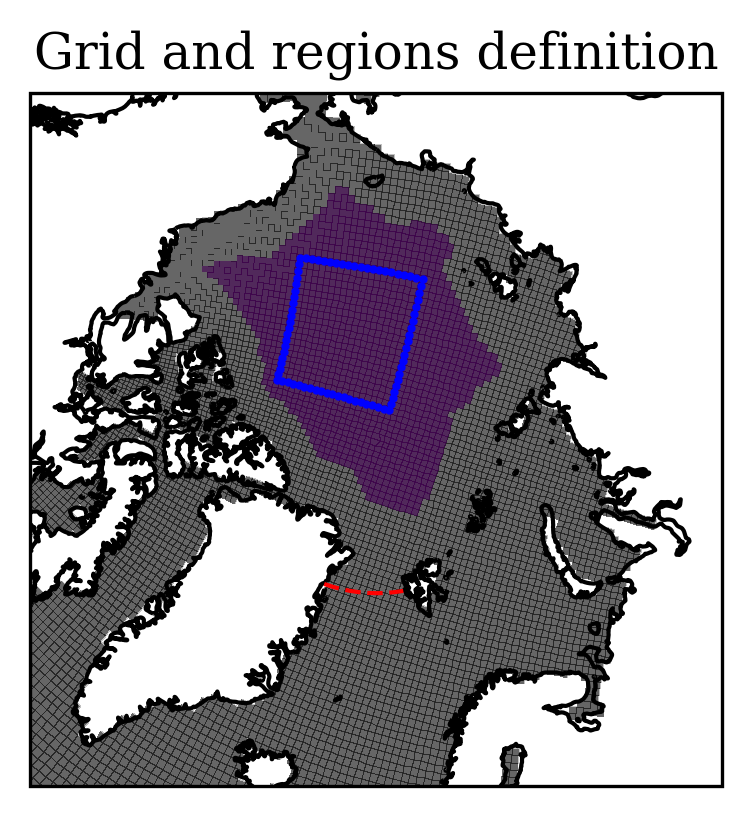

In [9]:
import cartopy.crs as ccrs
import matplotlib.patches as patches

proj = ccrs.NorthPolarStereo()  

fig, ax = plt.subplots(1, 1, figsize=(3,3), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    lon, lat, mask,
    transform=ccrs.PlateCarree(),
    cmap="Greys", alpha=0.6
)

#Central Arctic mask
mask_CA = np.load("../utils/mask_reduced_CA.npy")
mask_CA[mask_CA == 0] = np.nan
ax.pcolormesh(
    lon[:-1], lat[:-1], mask_CA[:,5:-5],
    transform=ccrs.PlateCarree(),
     alpha=0.6
)

# Project PSD rectangle area onto lat/lon
lon_np = lon.values
lat_np = lat.values

x_start, x_end = 50, 70
y_start, y_end = 80, 100

lon_np = lon.values
lat_np = lat.values

x_start, x_end = 50, 70
y_start, y_end = 80, 100

boundary_lon = []
boundary_lat = []

# Bottom edge (left → right)
for x in range(x_start, x_end + 1):
    boundary_lon.append(lon_np[y_start, x])
    boundary_lat.append(lat_np[y_start, x])

# Right edge (bottom → top)
for y in range(y_start + 1, y_end + 1):
    boundary_lon.append(lon_np[y, x_end])
    boundary_lat.append(lat_np[y, x_end])

# Top edge (right → left)
for x in range(x_end - 1, x_start - 1, -1):
    boundary_lon.append(lon_np[y_end, x])
    boundary_lat.append(lat_np[y_end, x])

# Left edge (top → bottom)
for y in range(y_end - 1, y_start, -1):
    boundary_lon.append(lon_np[y, x_start])
    boundary_lat.append(lat_np[y, x_start])

vertices = np.column_stack([boundary_lon, boundary_lat])

polygon = patches.Polygon(
    vertices,
    closed=True,
    edgecolor='red',
    facecolor='none',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

#ax.add_patch(polygon)

ax.scatter(
    boundary_lon,
    boundary_lat,
    s=1,
    color='blue',
    transform=ccrs.PlateCarree(),
    zorder=10
)
# --- Coastlines & labels ---
ax.coastlines()
ax.set_title('Grid and regions definition', fontsize=12)


# --- Plot full gate polyline ---
ax.plot(
    gate_lon, gate_lat, "--r", lw=1,
    transform=ccrs.PlateCarree(),
    label="Gate polyline"
)
#ax.text(-20, 90, '1', color='white', fontsize=12, fontweight='bold',
 #       transform=ccrs.PlateCarree())
#ax.text(-2, 72, '2', color='white', fontsize=12, fontweight='bold',
 #       transform=ccrs.PlateCarree())
#ax.scatter(
#    vertices[:,0],
#    vertices[:,1],
#    color='red',
#    s=50,
#    transform=ccrs.PlateCarree(),
#    zorder=10
#)
plt.savefig('fig02.pdf')

# Fig04 - Plot grid search 

In [ ]:
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize = (10, 8))

fs_1h_st = np.load(path_1h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,240].mean(axis = 0)
fs_6h_st = np.load(path_6h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,40].mean(axis = 0)
fs_12h_st = np.load(path_12h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,20].mean(axis = 0)
fs_24h_st = np.load(path_24h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,10].mean(axis = 0)

std_1h_st = np.load(path_1h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,240].std(axis = 0)
std_6h_st = np.load(path_6h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,40].std(axis = 0)
std_12h_st = np.load(path_12h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,20].std(axis = 0)
std_24h_st = np.load(path_24h + 'test_results/post_2_process_cycle_600_fs_mean.npy')[:,10].std(axis = 0)

fs_1h_lt = np.load(path_1h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].mean(axis = 0)
fs_6h_lt = np.load(path_6h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].mean(axis = 0)
fs_12h_lt = np.load(path_12h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].mean(axis = 0)
fs_24h_lt = np.load(path_24h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].mean(axis = 0)

std_1h_lt = np.load(path_1h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].std(axis = 0)
std_6h_lt = np.load(path_6h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].std(axis = 0)
std_12h_lt = np.load(path_12h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].std(axis = 0)
std_24h_lt = np.load(path_24h + 'test_results/post_2_process_cycle_1_fs_mean.npy')[0].std(axis = 0)

from matplotlib import patches



sx, sy = std_1h_st[0],std_1h_lt[0]
        
ell = patches.Ellipse((fs_1h_st[0], fs_1h_lt[0]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["1h"], alpha=0.2, edgecolor='none', zorder=2)
#ax1.add_patch(ell)

sx, sy = std_6h_st[0],std_6h_lt[0]
        
ell = patches.Ellipse((fs_6h_st[0], fs_6h_lt[0]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["6h"], alpha=0.2, edgecolor='none', zorder=2)
#ax1.add_patch(ell)

sx, sy = std_12h_st[0],std_12h_lt[0]
        
ell = patches.Ellipse((fs_12h_st[0], fs_12h_lt[0]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["12h"], alpha=0.2, edgecolor='none', zorder=2)
#ax1.add_patch(ell)

sx, sy = std_24h_st[0],std_24h_lt[0]
        
ell = patches.Ellipse((fs_24h_st[0], fs_24h_lt[0]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["24h"], alpha=0.2, edgecolor='none', zorder=2)
#ax1.add_patch(ell)
# Create the scatter plot
S = 120
scatter = ax1.scatter(
                fs_1h_st[0],
                fs_1h_lt[0],
                c=color_dict["1h"],
                marker='o',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                label='$\Delta t=$1h',
                zorder = 10,
                linewidths=0.5
                )
ax1.scatter(
                fs_6h_st[0],
                fs_6h_lt[0],
                c=color_dict["6h"],
                marker='v',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                label='$\Delta t=$6h',
                zorder = 10,
                linewidths=0.5)
ax1.scatter(
                fs_12h_st[0],
                fs_12h_lt[0],
                c=color_dict["12h"],
                marker='*',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                label='$\Delta t=$12h',
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )
ax1.scatter(
                fs_24h_st[0],
                fs_24h_lt[0],
                c=color_dict["24h"],
                marker='X',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                label='$\Delta t=$24h',
                zorder = 10,
                linewidths=0.5
                )
labels = ['a)', 'b)', 'c)', 'd)']
axes = [ax1, ax2, ax3, ax4]

for ax, label in zip(axes, labels):
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            va='top',
            ha='left')
ax1.legend(fontsize = 8)
sx, sy = std_1h_st[1],std_1h_lt[1]
        
ell = patches.Ellipse((fs_1h_st[1], fs_1h_lt[1]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["1h"], alpha=0.2, edgecolor='none', zorder=2)
#ax2.add_patch(ell)

sx, sy = std_6h_st[1],std_6h_lt[1]
        
ell = patches.Ellipse((fs_6h_st[1], fs_6h_lt[1]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["6h"], alpha=0.2, edgecolor='none', zorder=2)
#ax2.add_patch(ell)

sx, sy = std_12h_st[1],std_12h_lt[1]
        
ell = patches.Ellipse((fs_12h_st[1], fs_12h_lt[1]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["12h"], alpha=0.2, edgecolor='none', zorder=2)
#ax2.add_patch(ell)

sx, sy = std_24h_st[1],std_24h_lt[1]
        
ell = patches.Ellipse((fs_24h_st[1], fs_24h_lt[1]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["24h"], alpha=0.2, edgecolor='none', zorder=2)
#ax2.add_patch(ell)

ax2.scatter(
                fs_1h_st[1],
                fs_1h_lt[1],
                c=color_dict["1h"],
                marker='o',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )
ax2.scatter(
                fs_6h_st[1],
                fs_6h_lt[1],
                c=color_dict["6h"],
                marker='v',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5)
ax2.scatter(
                fs_12h_st[1],
                fs_12h_lt[1],
                c=color_dict["12h"],
                marker='*',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )
ax2.scatter(
                fs_24h_st[1],
                fs_24h_lt[1],
                c=color_dict["24h"],
                marker='X',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )

sx, sy = std_1h_st[2],std_1h_lt[2]
        
ell = patches.Ellipse((fs_1h_st[2], fs_1h_lt[2]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["1h"], alpha=0.2, edgecolor='none', zorder=2)
#ax3.add_patch(ell)

sx, sy = std_6h_st[2],std_6h_lt[2]
        
ell = patches.Ellipse((fs_6h_st[2], fs_6h_lt[2]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["6h"], alpha=0.2, edgecolor='none', zorder=2)
#ax3.add_patch(ell)

sx, sy = std_12h_st[2],std_12h_lt[2]
        
ell = patches.Ellipse((fs_12h_st[2], fs_12h_lt[2]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["12h"], alpha=0.2, edgecolor='none', zorder=2)
#ax3.add_patch(ell)

sx, sy = std_24h_st[2],std_24h_lt[2]
        
ell = patches.Ellipse((fs_24h_st[2], fs_24h_lt[2]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["24h"], alpha=0.2, edgecolor='none', zorder=2)
#ax3.add_patch(ell)

ax3.scatter(
                fs_1h_st[2],
                fs_1h_lt[2],
                c=color_dict["1h"],
                marker='o',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )
ax3.scatter(
                fs_6h_st[2],
                fs_6h_lt[2],
                c=color_dict["6h"],
                marker='v',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5)
ax3.scatter(
                fs_12h_st[2],
                fs_12h_lt[2],
                c=color_dict["12h"],
                marker='*',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )
ax3.scatter(
                fs_24h_st[2],
                fs_24h_lt[2],
                c=color_dict["24h"],
                marker='X',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder = 10,
                linewidths=0.5
                )

sx, sy = std_1h_st[4],std_1h_lt[4]
        
ell = patches.Ellipse((fs_1h_st[4], fs_1h_lt[4]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["1h"], alpha=0.2, edgecolor='k', zorder=2)
#ax4.add_patch(ell)

sx, sy = std_6h_st[4],std_6h_lt[4]
        
ell = patches.Ellipse((fs_6h_st[4], fs_6h_lt[4]), width=sx, height=2*sy, 
                      facecolor=color_dict["6h"], alpha=0.2, edgecolor='k', zorder=2)
#ax4.add_patch(ell)

sx, sy = std_12h_st[4],std_12h_lt[4]
        
ell = patches.Ellipse((fs_12h_st[4], fs_12h_lt[4]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["12h"], alpha=0.2, edgecolor='k', zorder=2)
#ax4.add_patch(ell)

sx, sy = std_24h_st[4],std_24h_lt[4]
        
ell = patches.Ellipse((fs_24h_st[4], fs_24h_lt[4]), width=2*sx, height=2*sy, 
                      facecolor=color_dict["24h"], alpha=0.1, edgecolor='k', zorder=2)
#ax4.add_patch(ell)

ax4.scatter(
                fs_1h_st[4],
                fs_1h_lt[4],
                c=color_dict["1h"],
                marker='o',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                linewidths=0.5,
                zorder=10
                )
ax4.scatter(
                fs_6h_st[4],
                fs_6h_lt[4],
                c=color_dict["6h"],
                marker='v',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder=10,
                linewidths=0.5)
ax4.scatter(
                fs_12h_st[4],
                fs_12h_lt[4],
                c=color_dict["12h"],
                marker='*',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                edgecolors='black',
                zorder=10,
                linewidths=0.5
                )
ax4.scatter(
                fs_24h_st[4],
                fs_24h_lt[4],
                c=color_dict["24h"],
                marker='X',  # Default marker, will be overridden by loop
                s=S,
                alpha=1,
                zorder=10,
                edgecolors='black',
                linewidths=0.5
                )
# Create a legend for lambda values
#legend_elements = [
#    mlines.Line2D([], [], color=plt.cm.viridis(i / len(lambda_bias_values)), marker='o', linestyle='None',
#                  markersize=10, label=r'$\lambda_{{\mathrm{{bias}}}}$={}'.format(lambda_bias))
#    for i, lambda_bias in enumerate(lambda_bias_values)
#] + [
#   mlines.Line2D([], [], color='gray', marker=marker, linestyle='None',
#                  markersize=10, label=r'$\lambda_{{\mathrm{{TV}}}}$={}'.format(lambda_TV))
#    for marker, lambda_TV in zip(['o', 's', '^', '<', '>'], lambda_TV_values)
#] + [
#    mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
#                  markersize=marker, label=r'$\lambda_{{\mathrm{{PINN}}}}$={}'.format(lambda_PINN))
#    for marker, lambda_PINN in zip([1, 5, 7, 10,13], lambda_PINN_values)
#]
#plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1))
ax1.set_xlabel('10 day RMSE (m)', fontsize = 8)
ax1.set_ylabel('1 year RMSE (m)', fontsize = 8)
ax1.set_title('SIV forecast skill', fontsize = 8)
ax1.tick_params(labelsize=8)

ax2.set_xlabel('10 day RMSE', fontsize = 8)
ax2.set_ylabel('1 year RMSE', fontsize = 8)
ax2.set_title('SIC forecast skill', fontsize = 8)
ax2.tick_params(labelsize=8)

ax3.set_xlabel('10 day RMSE (m/s)', fontsize = 8)
ax3.set_ylabel('1 year RMSE (m/s)', fontsize = 8)
ax3.set_title('$\mathrm{SID}_x$ forecast skill', fontsize = 8)
ax3.tick_params(labelsize=8)

ax4.set_xlabel('10 day RMSE (m)', fontsize = 8)
ax4.set_ylabel('1 year RMSE (m)', fontsize = 8)
ax4.set_title('SNV forecast skill', fontsize = 8)
ax4.tick_params(labelsize=8)

plt.grid(True)
plt.savefig('best_search.pdf',format='pdf', bbox_inches='tight', dpi=300)

# Fig 05: Forecast skill

## Load forecast skill

In [22]:
#nanuq_1h = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_1h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_10/post_2_process_True_cycle_1_pred_0.npy')[:,:,:,5:-5]
#nanuq_6h = np.load('/summer/meom/workdir/ducharlo/results/2026/grid_6h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_1/post_2_process_True_cycle_1_pred_0.npy')[:,:,:,5:-5]
#nanuq_12h = np.load('/summer/meom/workdir/ducharlo/results/2026/grid_12h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/post_2_process_True_cycle_1_pred_0.npy')[:,:,:,5:-5]
#nanuq_24h = np.load('/summer/meom/workdir/ducharlo/results/2026/grid_24h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_1/post_2_process_True_cycle_1_pred_0.npy')[:,:,:,5:-5]

fs_1h_bulk = np.load(path_1h + 'test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_1h_surface = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_1h_surface_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_1h_no_oce = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_1h_wo_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')

fs_6h_bulk = np.load(path_6h + 'test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_6h_surface = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_surface_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_6h_no_oce = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_wo_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')

fs_12h_bulk = np.load(path_12h + 'test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_12h_surface = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_12h_surface_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_12h_no_oce = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_12h_wo_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')

fs_24h_bulk = np.load(path_24h + 'test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_24h_surface = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_24h_surface_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')
fs_24h_no_oce = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_24h_wo_ocean/test_results/test_post_2_process_cycle_1300_fs_mean.npy')


fs_pers = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_1h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_10/test_results/test_post_2_process_cycle_1300_fs_mean_pers.npy')



In [16]:
print(fs_24h_no_oce[:,10].mean(axis = 0))

[0.10277746 0.06216136 0.0376157  0.03885643 0.0083335 ]


## Plot forecast skill

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
N = np.arange(250)
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12, 4))

ax1.plot(N[:25:24],fs_24h_bulk[:,:2,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:24],fs_24h_bulk[:,:2,0].mean(axis = 0), color = color_dict["24h"],s=40 ,marker = 's',edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25:24],fs_24h_surface[:,:2,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:24],fs_24h_surface[:,:2,0].mean(axis = 0), color = color_dict["24h"], marker = 'o',s=40,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25:24],fs_24h_no_oce[:,:2,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:24],fs_24h_no_oce[:,:2,0].mean(axis = 0),  color = color_dict["24h"], marker = '<',s=40,edgecolor='black',linewidths=1, zorder = 2) 

ax1.plot(N[:25:12],fs_12h_bulk[:,:3,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:12],fs_12h_bulk[:,:3,0].mean(axis = 0), color = color_dict["12h"],s=40  ,marker = 's',edgecolor='black', zorder = 2)

ax1.plot(N[:25:12],fs_12h_surface[:,:3,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:12],fs_12h_surface[:,:3,0].mean(axis = 0), color = color_dict["12h"], marker = 'o',s=40,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25:12],fs_12h_no_oce[:,:3,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:25:12],fs_12h_no_oce[:,:3,0].mean(axis = 0), color = color_dict["12h"], marker = '<',s=40,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:30:6],fs_6h_bulk[:,:5,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:30:6],fs_6h_bulk[:,:5,0].mean(axis = 0), color = color_dict["6h"],s=40, marker = 's',edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:30:6],fs_6h_surface[:,:5,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:30:6],fs_6h_surface[:,:5,0].mean(axis = 0), color = color_dict["6h"], marker = 'o',s=40,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:30:6],fs_6h_no_oce[:,:5,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax1.scatter(N[:30:6],fs_6h_no_oce[:,:5,0].mean(axis = 0), color = color_dict["6h"], marker = '<',s=40,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25],fs_1h_bulk[:,:25,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, zorder = 1)
ax1.scatter(N[:25],fs_1h_bulk[:,:25,0].mean(axis = 0), label = 'Atmospheric + bulk ocean', color = color_dict["1h"], marker = 's',s=20,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25],fs_1h_surface[:,:25,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, zorder = 1)
ax1.scatter(N[:25],fs_1h_surface[:,:25,0].mean(axis = 0), label = 'Atmospheric + surface ocean', color = color_dict["1h"] , marker = 'o',s=20,edgecolor='black',linewidths=1, zorder = 2)

ax1.plot(N[:25],fs_1h_no_oce[:,:25,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, zorder = 1)
ax1.scatter(N[:25],fs_1h_no_oce[:,:25,0].mean(axis = 0), label = 'Atmospheric only', color = color_dict["1h"], marker = '<',s=20,edgecolor='black',linewidths=1, zorder = 2)


ax1.plot(N[:24],fs_pers[:,:24,0].mean(axis = 0),label = 'Persistence', color = 'k')
ax1.set_xlabel("Lead time (hours)", fontsize = 11)
ax1.set_ylabel("RMSE (m)", fontsize = 11)
ax1.set_title('SIV 1 day forecast on full Arctic', fontsize = 11)
ax1.set_ylim([0, 0.023])

ax2.plot(N[:240]/24,fs_1h_bulk[:,:240,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240:5]/24,fs_1h_bulk[:,:240:5,0].mean(axis = 0), label = 'Atmospheric forcings only',edgecolor='black', color = color_dict["1h"], marker = 's',s=15, linewidths = 1, zorder = 2)

ax2.plot(N[:240]/24,fs_1h_surface[:,:240,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240:5]/24,fs_1h_surface[:,:240:5,0].mean(axis = 0), label = 'Atmospheric + surface ocean',edgecolor='black', color = color_dict["1h"] , marker = 'o',s=15, linewidths = 1, zorder = 2)

ax2.plot(N[:240]/24,fs_1h_no_oce[:,:240,0].mean(axis = 0), color = color_dict["1h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240:5]/24,fs_1h_no_oce[:,:240:5,0].mean(axis = 0), label = 'Atmospheric + bulk ocean',edgecolor='black', color = color_dict["1h"], marker = '<',s=15, linewidths = 1, zorder = 2)

ax2.plot(N[:246:6]/24,fs_6h_bulk[:,:246//6,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:246:6]/24,fs_6h_bulk[:,:246//6,0].mean(axis = 0), color = color_dict["6h"],s=25, marker = 's',edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:246:6]/24,fs_6h_surface[:,:246//6,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:246:6]/24,fs_6h_surface[:,:246//6,0].mean(axis = 0), color = color_dict["6h"], marker = 'o',s=25,edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:246:6]/24,fs_6h_no_oce[:,:246//6,0].mean(axis = 0), color = color_dict["6h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:246:6]/24,fs_6h_no_oce[:,:246//6,0].mean(axis = 0), color = color_dict["6h"], marker = '<',s=25,edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:12]/24,fs_12h_bulk[:,:246//12+1,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:12]/24,fs_12h_bulk[:,:240//12+1,0].mean(axis = 0), color = color_dict["12h"],s=25  ,marker = 's',edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:12]/24,fs_12h_surface[:,:246//12+1,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:12]/24,fs_12h_surface[:,:240//12+1,0].mean(axis = 0), color = color_dict["12h"], marker = 'o',s=25,edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:12]/24,fs_12h_no_oce[:,:246//12+1,0].mean(axis = 0), color = color_dict["12h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:12]/24,fs_12h_no_oce[:,:240//12+1,0].mean(axis = 0), color = color_dict["12h"], marker = '<',s=25,edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:24]/24,fs_24h_bulk[:,:246//24+1,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:24]/24,fs_24h_bulk[:,:240//24+1,0].mean(axis = 0), color = color_dict["24h"],s=25 ,marker = 's',edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:24]/24,fs_24h_surface[:,:246//24+1,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:24]/24,fs_24h_surface[:,:240//24+1,0].mean(axis = 0), color = color_dict["24h"], marker = 'o',s=25,edgecolor='black',linewidths=1, zorder = 2)

ax2.plot(N[:240+1:24]/24,fs_24h_no_oce[:,:246//24+1,0].mean(axis = 0), color = color_dict["24h"], linewidth = 1.5, linestyle = 'solid', zorder = 1)
ax2.scatter(N[:240+1:24]/24,fs_24h_no_oce[:,:240//24+1,0].mean(axis = 0),  color = color_dict["24h"], marker = '<',s=25 ,edgecolor='black',linewidths=1, zorder = 2)


ax2.plot(N[:240]/24,fs_pers[:,:240,0].mean(axis = 0),label = 'Persistence', color = 'k')
ax2.set_xlabel("Lead time (days)", fontsize = 11)
ax2.set_ylabel("RMSE (m)", fontsize = 11)
ax2.set_title('SIV 10 day forecast on full Arctic', fontsize = 11)
ax2.set_ylim([0, 0.15])

ax1.tick_params(labelsize=11)
ax2.tick_params(labelsize=11)

#ax2.set_title('Atmospheric forced emulator SIC errors', fontsize = 11)
#ax4.set_title('Atmo + bulk forced emulator SIC errors', fontsize = 11)
#fig.suptitle("Hourly emulators short term forecast evaluation", fontsize = 14,y=0.94)

color_proxies = [
    Line2D([0], [0], color=color_dict["1h"], lw=2, label='$\Delta t=$1h'),
    Line2D([0], [0], color=color_dict["6h"], lw=2, label='$\Delta t=$6h'),
    Line2D([0], [0], color=color_dict["12h"], lw=2, label='$\Delta t=$12h'),
    Line2D([0], [0], color=color_dict["24h"], lw=2, label='$\Delta t=$24h'),
    Line2D([0], [0], color='k', lw=2, label='Persistence')
]

# Markers and line styles
marker_proxies = [
    Line2D([0], [0], marker='s', color='black', lw=0, label=r'$\mathcal{M}_{\text{sub-surf}}$', markersize=10),
    Line2D([0], [0], marker='o', color='black', lw=0, label=r'$\mathcal{M}_{\mathrm{surface}}$', markersize=10),
    Line2D([0], [0], marker='<', color='black', lw=0, label=r'$\mathcal{M}_{\mathrm{atmo}}$', markersize=10),
    #Line2D([0], [0], color='black', lw=1, linestyle='solid', label='Solid line'),
    #Line2D([0], [0], color='black', lw=1, linestyle='dashed', label='Dashed line'),
    #Line2D([0], [0], color='black', lw=1, linestyle='dotted', label='Dotted line')
]

# --- Add the first legend (colors) ---
ax1.legend(handles=color_proxies, loc='lower right', title='Lead Time', fontsize = 11)

# --- Add the second legend (markers and line styles) ---
# Place the second legend below the first one 
ax2.legend(handles=marker_proxies, loc='lower right', title='Forcings', fontsize = 11)

labels = ['a)', 'b)']
axes = [ax1, ax2]

for ax, label in zip(axes, labels):
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            va='top',
            ha='left')
# Adjust the layout to prevent overlap
plt.tight_layout()
#plt.suptitle("Short term forecast evaluation", fontsize=11, y=0.98)
plt.savefig("fig05.pdf")


# Fig6 : Central Arctic Seasonal Evolution

## Load forecasts


In [6]:
#Define time
time_plot = ds.time_counter

#Load forecast 
pred_1h = np.load(path_1h + 'test_process_True_freq_720_cycle_1_pred_0.npy')[:,:,:,5:-5]
pred_6h = np.load(path_6h + 'test_process_True_freq_720_cycle_1_pred_0.npy')[:,:,:,5:-5]
pred_12h = np.load(path_12h + 'test_process_True_freq_720_cycle_1_pred_0.npy')[:,:,:,5:-5]
pred_24h = np.load(path_24h + 'test_process_True_freq_720_cycle_1_pred_0.npy')[:,:,:,5:-5]

nanuq = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_12h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/test_process_True_freq_720_cycle_1_truth_0.npy')[:,:,:,5:-5]


## Plot seasonal evolution

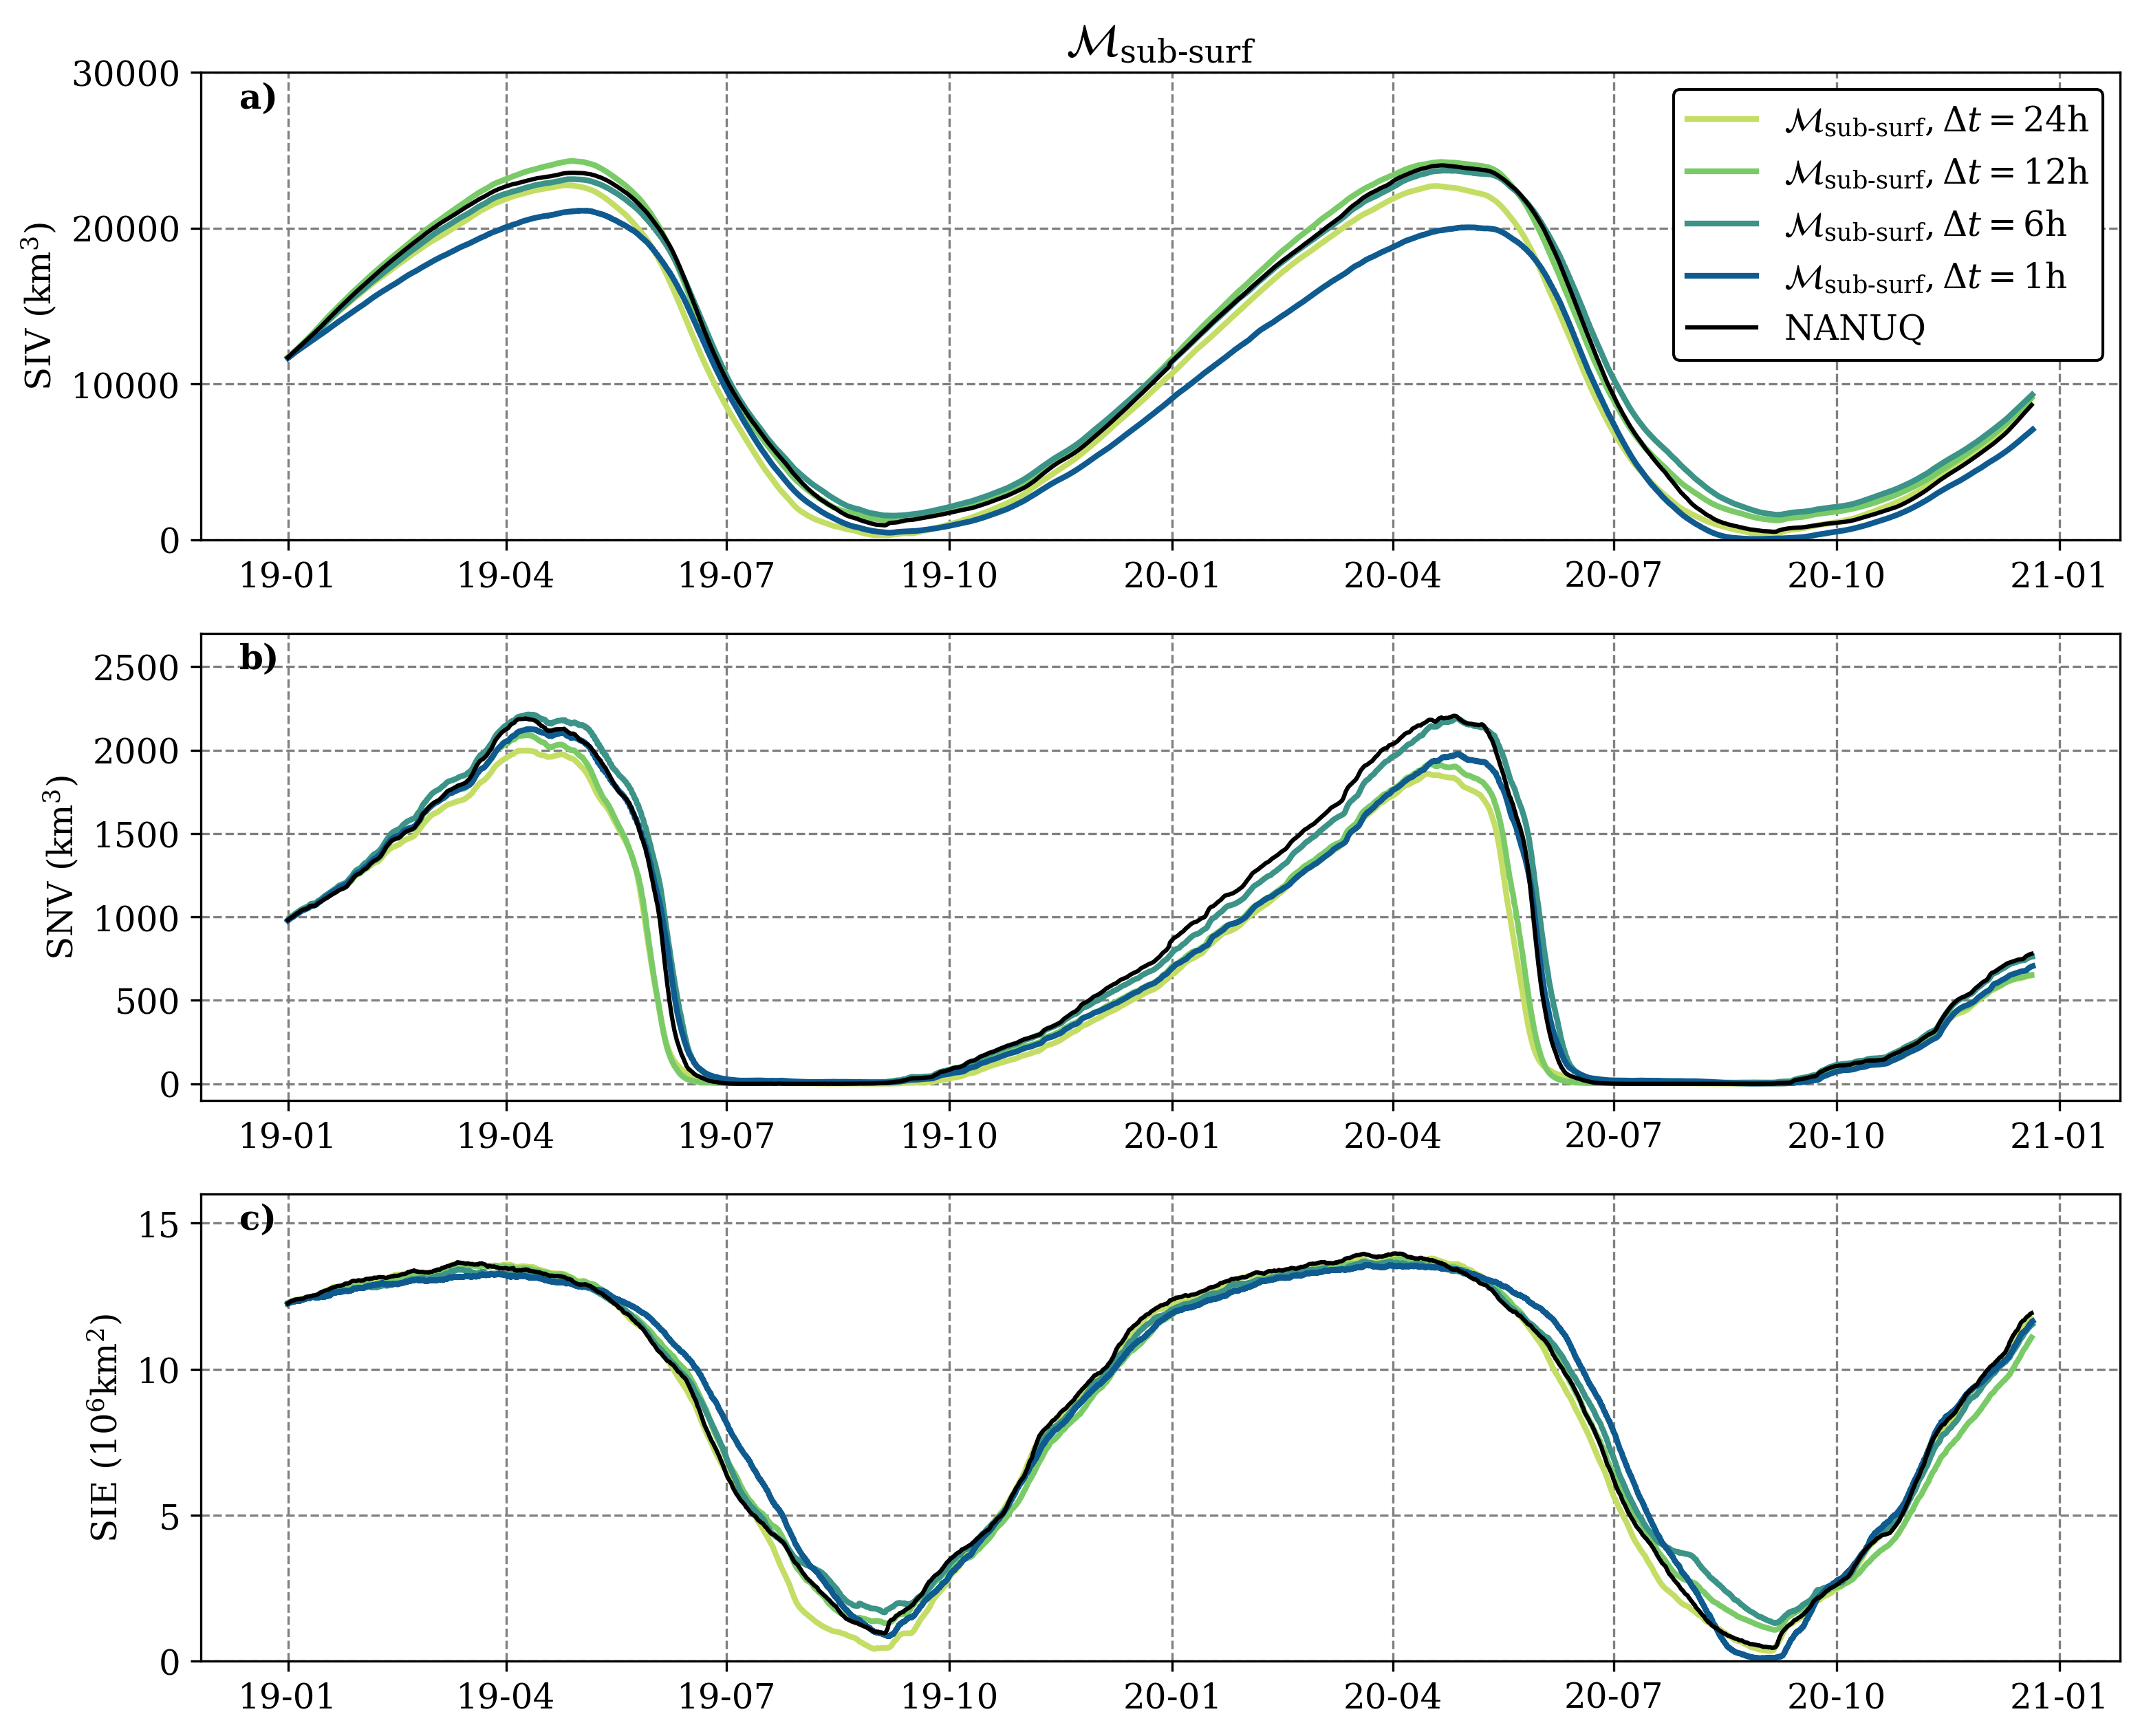

In [13]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_12h_bulk_ocean_TV01/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]

#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_12h_bulk_ocean_TV01/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
#nanuk_SA = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_12h_standalone_surface/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]

fig, (ax1, ax5, ax7) = plt.subplots(
    3, 1, figsize=(12,10), 
    gridspec_kw={'height_ratios':[1, 1, 1]}
)
N = np.arange(17280)
# --- Top panel: Sea ice volume ---
ax1.plot(time_plot[:720*24:24], np.nansum(np.where(pred_24h[:720,1]>0.15, pred_24h[:720,0]*area/1e9, np.nan),axis=(1,2)), 
          label=r'$\mathcal{M}_{\text{sub-surf}}, \Delta t = 24$h', color=color_dict['24h'], linewidth=2)
ax1.plot(time_plot[:720*24:12], np.nansum(np.where(pred_12h[:720*2,1]>0.15, pred_12h[:720*2,0]*area/1e9, np.nan),axis=(1,2)), 
         label=r'$\mathcal{M}_{\text{sub-surf}}, \Delta t = 12$h', color=color_dict['12h'], linewidth=2)
ax1.plot(time_plot[:720*24:6], np.nansum(np.where(pred_6h[:720*4,1]>0.15, pred_6h[:720*4,0]*area/1e9, np.nan),axis=(1,2)), 
         label=r'$\mathcal{M}_{\text{sub-surf}}, \Delta t = 6$h', color=color_dict['6h'], linewidth=2)
ax1.plot(time_plot[:720*24:1], np.nansum(np.where(pred_1h[:720*24,1]>0.15, pred_1h[:720*24,0]*area/1e9, np.nan),axis=(1,2)), 
         label=r'$\mathcal{M}_{\text{sub-surf}}, \Delta t = 1$h', color=color_dict['1h'], linewidth=2)
ax1.plot(time_plot[:720*24:12], np.nansum(np.where(nanuq[:720*2,1]>0.15, nanuq[:720*2,0]*area/1e9, np.nan),axis=(1,2)), 
         label='NANUQ', color='k', linewidth=1.5)


ax1.set_ylabel('SIV ($\mathrm{km}^3$)', fontsize = 12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))



# --- Top panel: Sea ice volume ---
ax5.plot(time_plot[:720*24:24], np.nansum(np.where(pred_24h[:720,1]>0.15, pred_24h[:720,4]*area/1e9, np.nan),axis=(1,2)), 
          label='$\mathcal{M}_{\mathrm{sub-surf}}, \Delta t = 24$h', color=color_dict['24h'], linewidth=2)
ax5.plot(time_plot[:720*24:12], np.nansum(np.where(pred_12h[:720*2,1]>0.15, pred_12h[:720*2,4]*area/1e9, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{sub-surf}}, \Delta t = 12$h', color=color_dict['12h'], linewidth=2)
ax5.plot(time_plot[:720*24:6], np.nansum(np.where(pred_6h[:720*4,1]>0.15, pred_6h[:720*4,4]*area/1e9, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{sub-surf}}, \Delta t = 6$h', color=color_dict['6h'], linewidth=2)
ax5.plot(time_plot[:720*24:1], np.nansum(np.where(pred_1h[:720*24,1]>0.15, pred_1h[:720*24,4]*area/1e9, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{sub-surf}}, \Delta t = 1$h', color=color_dict['1h'], linewidth=2)
ax5.plot(time_plot[:720*24:12], np.nansum(np.where(nanuq[:720*2,1]>0.15, nanuq[:720*2,4]*area/1e9, np.nan),axis=(1,2)), 
         label='NANUQ', color='k', linewidth=1.5)

ax5.set_ylabel('SNV ($\mathrm{km}^3$)', fontsize = 12)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))





# --- Bottom panel: Sea ice concentration ---
ax7.plot(time_plot[:720*24:24],np.nansum(np.where(pred_24h[:720,1]>0.15, area/1e12, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{no \\; ocean}}, \Delta t = 24$h', color=color_dict['24h'], linewidth=2)
ax7.plot(time_plot[:720*24:12], np.nansum(np.where(pred_12h[:720*2,1]>0.15, area/1e12, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{no \\; ocean}}, \Delta t = 12$h', color=color_dict['12h'], linewidth=2)
ax7.plot(time_plot[:720*24:6], np.nansum(np.where(pred_6h[:720*4,1]>0.15, area/1e12, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{no \\; ocean}}, \Delta t = 6$h', color=color_dict['6h'], linewidth=2)
ax7.plot(time_plot[:720*24:1], np.nansum(np.where(pred_1h[:720*24,1]>0.15, area/1e12, np.nan),axis=(1,2)), 
         label='$\mathcal{M}_{\mathrm{no \\; ocean}}, \Delta t = 1$h', color=color_dict['1h'], linewidth=2)
ax7.plot(time_plot[:720*24:12], np.nansum(np.where(nanuq[:720*2,1]>0.15, area/1e12, np.nan),axis=(1,2)), 
         label='NANUQ', color='k', linewidth=1.5)


#ax4.legend(fontsize = 12)
ax7.set_ylabel('SIE ($10^6\mathrm{km}^2$)', fontsize = 12)
ax7.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))



#plt.suptitle("Seasonal evolution of SIV, SNV and SIE", fontsize = 16)
ax1.tick_params(axis='both', labelsize=12)
ax5.tick_params(axis='both', labelsize=12)
ax7.tick_params(axis='both', labelsize=12)

ax1.set_title(r'$\mathcal{M}_{\text{sub-surf}}$', fontsize = 16)

#legend1 = ax3.legend(fontsize=12, loc='center left')

# Add the first legend back
#ax3.add_artist(legend1)
#ax3.legend(handles=color_handles, title='Data input', frameon=True, fontsize = 12,
#                  loc='lower left')

ax1.legend(fontsize = 12)
#ax3.legend(fontsize = 12)
#ax4.legend(fontsize = 12)

#ax5.legend(fontsize = 12)
#ax6.legend(fontsize = 12)

ax1.set_ylim([-1e-1, 30000])


ax5.set_ylim([-1e2, 2700])

ax7.set_ylim([0, 16])
labels = ['a)', 'b)', 'c)']
axes = [ax1, ax5, ax7]

for ax, label in zip(axes, labels):
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight='bold',
            va='top',
            ha='left')
# --- Zoom-in inset for first months ---
plt.savefig('fig06.pdf', transparent = True, dpi = 300)


# Fig 07 SIV distibution

In [81]:
mask2 = mask[:-1]

In [5]:
time_plot = ds.time_counter[:24*360:24]
time_plot

#avg_1h_nanuq = np.load('daily_avg_1h_nanuq.npy')
#avg_6h_nanuq = np.load('daily_avg_6h_nanuq.npy')
avg_12h_nanuq = np.load('daily_avg_1h_nanuq.npy')[0]
#avg_24h_nanuq = np.load('daily_avg_24h_nanuq.npy')

avg_1h = np.load('daily_avg_1h_pred.npy')[0]
avg_6h = np.load('daily_avg_6h_pred.npy')[0]
avg_12h = np.load('daily_avg_12h_pred.npy')[0]
avg_24h = np.load('daily_avg_24h_pred.npy')[0]


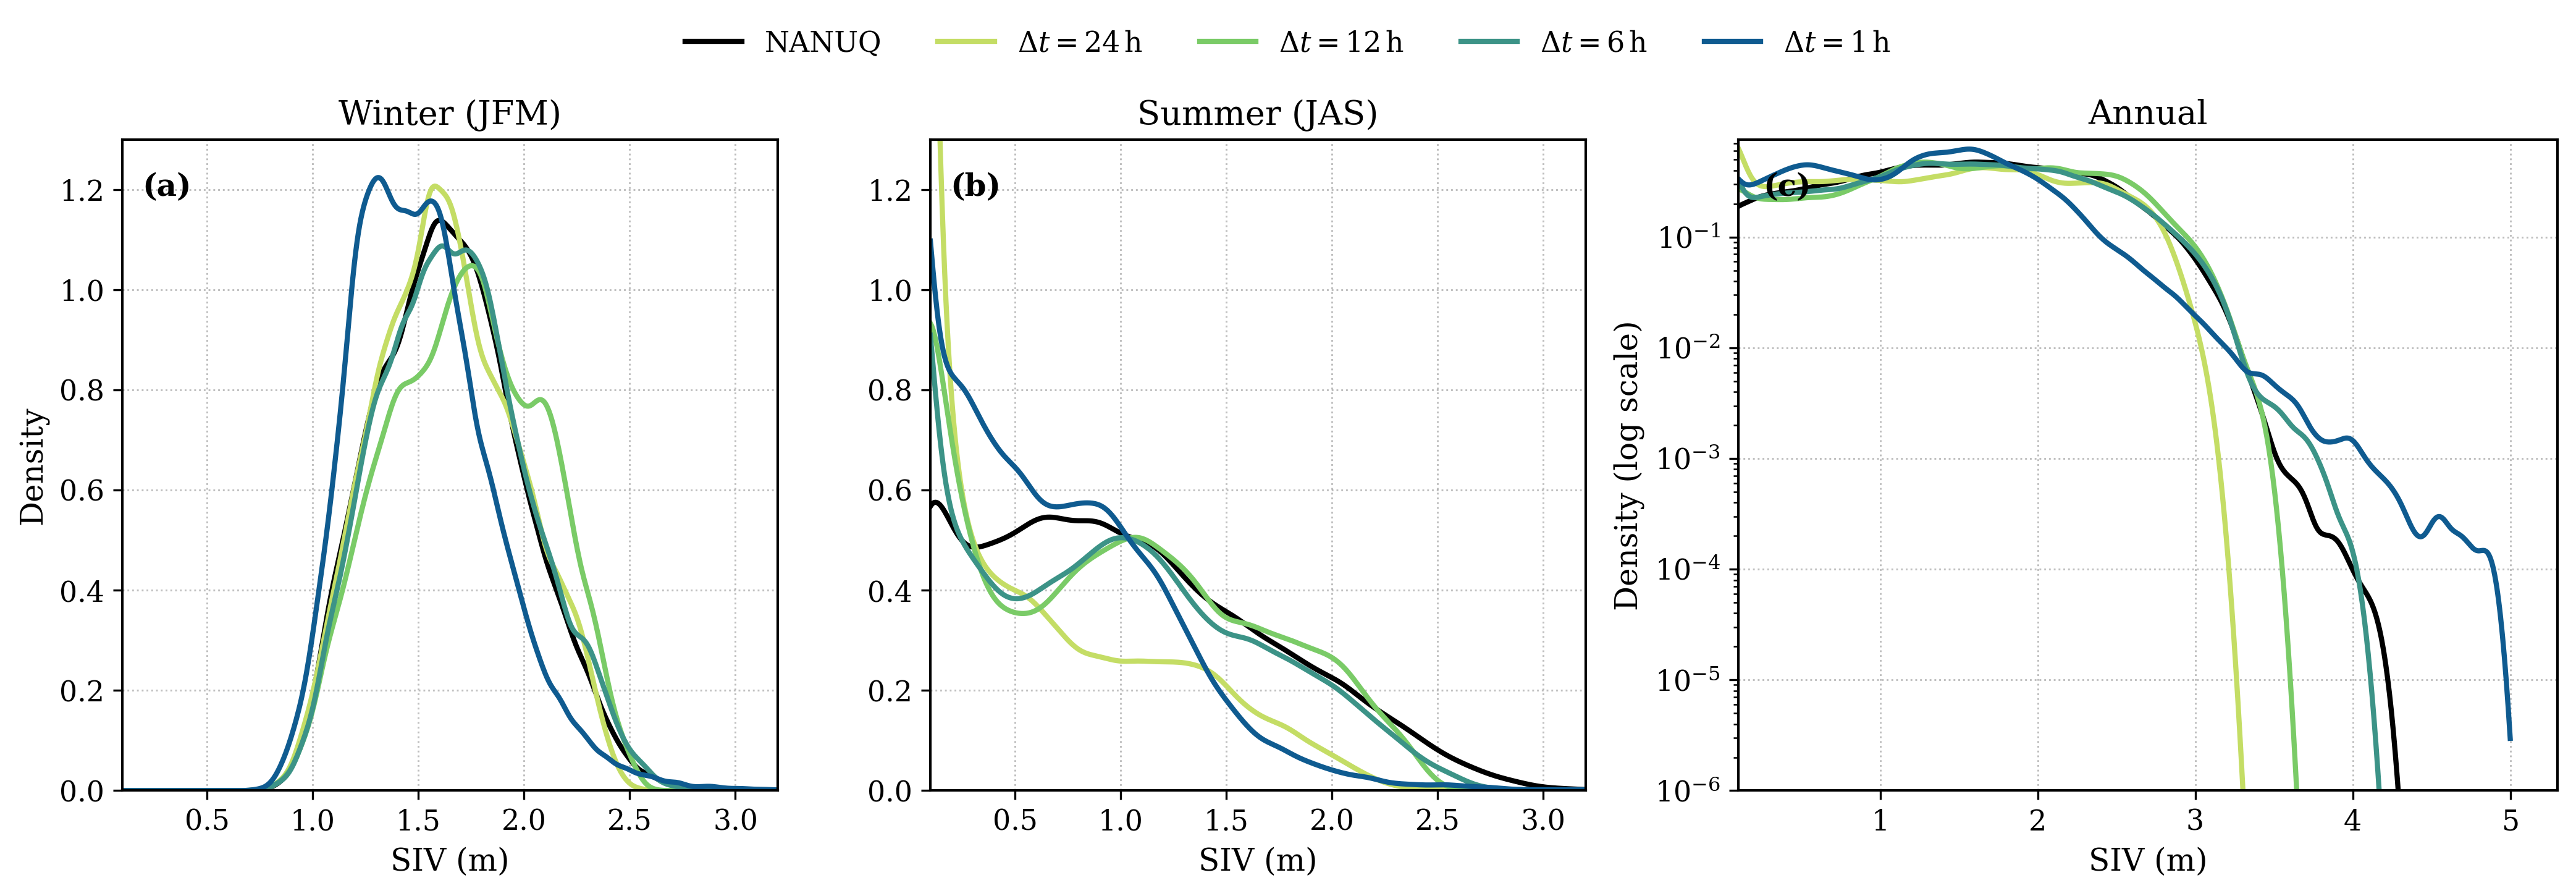

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ======================================================
# Settings
# ======================================================

threshold = 0.01

labels_base = [
    'NANUQ',
    r'$\Delta t = 24\,\mathrm{h}$',
    r'$\Delta t = 12\,\mathrm{h}$',
    r'$\Delta t = 6\,\mathrm{h}$',
    r'$\Delta t = 1\,\mathrm{h}$'
]

colors = [
    'k',
    color_dict["24h"],
    color_dict["12h"],
    color_dict["6h"],
    color_dict["1h"]
]

months = time_plot.dt.month.values

seasons = {
    "Winter (JFM)": [1, 2, 3],
    "Summer (JAS)": [7, 8, 9],
    "Annual": np.arange(1, 13)
}

# ======================================================
# Robust x-limit helper
# ======================================================

def seasonal_xlim(datasets, percentile=99.7, min_max=2.5):
    all_data = np.concatenate(datasets)
    all_data = all_data[np.isfinite(all_data)]

    if len(all_data) == 0:
        return min_max

    xmax = np.percentile(all_data, percentile)
    return max(min_max, xmax * 1.05)

# ======================================================
# Figure
# ======================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 4.5),
    gridspec_kw={'width_ratios': [1, 1, 1.25]}
)

legend_handles = None

for ax, (season_name, season_months) in zip(axes, seasons.items()):

    idx = np.where(np.isin(months, season_months))[0]

    datasets = [
        (avg_12h_nanuq[idx, 0] * mask_CA_nan).flatten(),
        (avg_24h[idx, 0] * mask_CA_nan).flatten(),
        (avg_12h[idx, 0] * mask_CA_nan).flatten(),
        (avg_6h[idx, 0] * mask_CA_nan).flatten(),
        (avg_1h[idx, 0] * mask_CA_nan).flatten(),
    ]

    # clean
    datasets = [d[d > threshold] for d in datasets]

    # ==================================================
    # x-limits (season-specific)
    # ==================================================

    if season_name == "Winter (JFM)":
        x_max = seasonal_xlim(datasets, percentile=1, min_max=5)

    elif season_name == "Summer (JAS)":
        x_max = seasonal_xlim(datasets, percentile=1, min_max=5)

    else:  # Annual
        x_max = seasonal_xlim(datasets, percentile=1, min_max=5)

    x_grid = np.linspace(0.1, x_max, 800)

    # ==================================================
    # KDE plotting
    # ==================================================

    max_density = 0

    for data, label, color in zip(datasets, labels_base, colors):

        if len(data) < 10:
            continue

        kde = gaussian_kde(data)
        y = kde(x_grid)

        max_density = max(max_density, y.max())

        if season_name == "Annual":
            ax.semilogy(
                x_grid,
                y,
                lw=2,
                color=color,
                label=label
            )
        else:
            ax.plot(
                x_grid,
                y,
                lw=2,
                color=color,
                label=label
            )

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # ==================================================
    # Styling
    # ==================================================

    ax.set_title(season_name, fontsize=13)
    ax.set_xlim(0.1, x_max)

    if season_name == "Annual":
        ax.set_ylim(1e-6, max_density * 1.2 )
        ax.set_xlim(0.1, 5.3)
    else:
        ax.set_ylim(0, 1.3)
        ax.set_xlim(0.1, 3.2)

    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

    ax.tick_params(labelsize=11)

# ======================================================
# Labels
# ======================================================

axes[0].set_ylabel("Density", fontsize=12)
axes[2].set_ylabel("Density (log scale)", fontsize=12)

for ax in axes:
    ax.set_xlabel("SIV (m)", fontsize=12)

# ======================================================
# Panel labels
# ======================================================

for ax, lab in zip(axes, ["(a)", "(b)", "(c)"]):
    ax.text(
        0.03, 0.95, lab,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ======================================================
# Legend
# ======================================================

leg = fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "SIV_distribution_seasonal.pdf",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=[leg]
)

plt.show()

# Fig 08: Maps drift  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean

threshold = 0.02  # m/s

pred_6h = np.load(path_6h + 'test_process_True_freq_720_cycle_1_pred_0.npy')[:, :, :, 5:-5]
nanuq = np.load(path_6h + 'test_process_True_freq_720_cycle_1_truth_0.npy')[:, :, :, 5:-5]

mask = np.load("../utils/mask_nanuk1.npy")[:-1]
mask_nan = mask.astype(float)        # make sure it's float
mask_nan[mask_nan == 0] = np.nan     # replace 0 with NaN

# ======================================================
# Fields
# ======================================================
u_nanuq = nanuq[:, 2].mean(axis=0)
v_nanuq = nanuq[:, 3].mean(axis=0)
u_ref = pred_6h[:, 2].mean(axis=0)
v_ref = pred_6h[:, 3].mean(axis=0)

speed_nanuq = np.sqrt(u_nanuq**2 + v_nanuq**2)
speed_ref = np.sqrt(u_ref**2 + v_ref**2)

# difference field (forecast - observation)
diff_speed = speed_ref - speed_nanuq

# consistent color scaling for the two speed panels
vmax = np.nanpercentile(
    np.concatenate([speed_nanuq.ravel(), speed_ref.ravel()]),
    99
)
vmin = 0

# symmetric diverging scale for the difference panel
diff_abs_max = 0.07

# ======================================================
# Figure
# ======================================================
mask_bg_color = "#d4d4d4"  # shows only behind masked (land/NaN) pixels

fig, axes = plt.subplots(
    1, 3, figsize=(15.5, 5.5),
    sharex=True, sharey=True,
    constrained_layout=True
)

fields = [
    ("NANUQ", u_nanuq, v_nanuq, speed_nanuq, cmocean.cm.thermal, vmin, vmax),
    (r"$\mathcal{M}_{\text{sub-surf}}$, 6h", u_ref, v_ref, speed_ref, cmocean.cm.thermal, vmin, vmax),
    (r"$\mathcal{M}_{\text{sub-surf}}$ $-$ NANUQ", None, None, diff_speed, cmocean.cm.balance, -diff_abs_max, diff_abs_max),
]

step = 3

for i, (ax, (title, u_mean, v_mean, field, cmap, vlo, vhi)) in enumerate(zip(axes, fields)):
    # facecolor only shows through where imshow data is masked
    ax.set_facecolor(mask_bg_color)

    im = ax.imshow(
        np.ma.masked_array(field, mask=1 - mask_nan),
        origin='lower',
        cmap=cmap,
        vmin=vlo,
        vmax=vhi
    )
    ax.set_title(title, fontsize=13, pad=8)

    # quiver only on the two speed panels, not the difference panel
    if u_mean is not None:
        y_idx, x_idx = np.mgrid[
            0:u_mean.shape[0]:step,
            0:u_mean.shape[1]:step
        ]
        u_sub = u_mean[::step, ::step]
        v_sub = v_mean[::step, ::step]
        speed_sub = np.sqrt(u_sub**2 + v_sub**2)

        u_plot = np.where(speed_sub > threshold, u_sub, np.nan)
        v_plot = np.where(speed_sub > threshold, v_sub, np.nan)

        ax.quiver(
            x_idx, y_idx, u_plot, v_plot,
            color='white',
            scale=None,
            width=0.003,
            pivot='mid'
        )

    # clean styling
    ax.set_aspect('equal')
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # store the two ScalarMappables we'll need for colorbars
    if i == 0:
        im_speed = im
    elif i == 2:
        im_diff = im

# ======================================================
# Labels
# ======================================================
axes[0].set_ylabel("Y", fontsize=12)
for ax in axes:
    ax.set_xlabel("X", fontsize=12)

# panel labels
for ax, lab in zip(axes, ["(a)", "(b)", "(c)"]):
    ax.text(
        0.03, 0.95, lab,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        color="k"
    )

# ======================================================
# Colorbars
# ======================================================
# shared colorbar for the two speed panels (a, b)
cbar_speed = fig.colorbar(
    im_speed,
    ax=axes[:2],
    location='right',
    shrink=0.85,
    pad=0.02,
    aspect=25,
    label='Drift speed (m/s)'
)
cbar_speed.ax.tick_params(labelsize=10)
cbar_speed.outline.set_visible(True)

# separate colorbar for the difference panel (c)
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[2],
    location='right',
    shrink=0.85,
    pad=0.02,
    aspect=25,
    label='Speed difference (m/s)'
)
cbar_diff.ax.tick_params(labelsize=10)
cbar_diff.outline.set_visible(True)

# ======================================================
# Save
# ======================================================
plt.savefig("fig08.pdf", dpi=300, bbox_inches="tight")
plt.show()
    

# Fig09 SID analysis

## Save daily forecasts

In [10]:
tot_nanuq_1h = np.zeros((12, 8640, 5, 128, 118))
tot_nanuq_6h = np.zeros((12, 1440, 5, 128, 118))
tot_nanuq_12h = np.zeros((12, 720, 5, 128, 118))
tot_nanuq_24h = np.zeros((12, 360, 5, 128, 118))

tot_pred_1h = np.zeros((12, 8640, 5, 128, 118))
tot_pred_6h = np.zeros((12, 1440, 5, 128, 118))
tot_pred_12h = np.zeros((12, 720, 5, 128, 118))
tot_pred_24h = np.zeros((12, 360, 5, 128, 118))

for i in trange(12):
    tot_nanuq_1h[i] = np.load(path_1h + 'test_process_True_freq_720_cycle_12_truth_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_nanuq_6h[i] = np.load(path_6h + 'test_process_True_freq_720_cycle_12_truth_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_nanuq_12h[i] = np.load(path_12h + 'test_process_True_freq_720_cycle_12_truth_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_nanuq_24h[i] = np.load(path_24h + 'test_process_True_freq_720_cycle_12_truth_{}.npy'.format(str(i)))[:,:,:,5:-5]
    
    tot_pred_1h[i] = np.load(path_1h + 'test_process_True_freq_720_cycle_12_pred_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_pred_6h[i] = np.load(path_6h + 'test_process_True_freq_720_cycle_12_pred_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_pred_12h[i] = np.load(path_12h + 'test_process_True_freq_720_cycle_12_pred_{}.npy'.format(str(i)))[:,:,:,5:-5]
    tot_pred_24h[i] = np.load(path_24h + 'test_process_True_freq_720_cycle_12_pred_{}.npy'.format(str(i)))[:,:,:,5:-5]



100%|█████████████████████████████████████████████████████████████████████████████████| 12/12 [01:04<00:00,  5.34s/it]


In [12]:
avg_1h = np.zeros((12, 360, 5, 128, 118))
for j in trange(12):
    avg_1h[j] = np.array([
        tot_pred_6h[j,4*i:4*i+4].mean(axis=0)
        for i in range(np.shape(tot_pred_6h)[1]//4)
    ])
np.save('daily_avg_1h_pred.npy', avg_1h)

avg_1h = np.zeros((12, 360, 5, 128, 118))
for j in trange(12):
    avg_1h[j] = np.array([
        tot_pred_6h[j,4*i:4*i+4].mean(axis=0)
        for i in range(np.shape(tot_pred_6h)[1]//4)
    ])
np.save('daily_avg_6h_pred.npy', avg_1h)

avg_1h = np.zeros((12, 360, 5, 128, 118))
for j in trange(12):
    avg_1h[j] = np.array([
        tot_pred_6h[j,4*i:4*i+4].mean(axis=0)
        for i in range(np.shape(tot_pred_6h)[1]//4)
    ])
np.save('daily_avg_12h_pred.npy', avg_1h)

avg_1h = np.zeros((12, 360, 5, 128, 118))
for j in trange(12):
    avg_1h[j] = np.array([
        tot_pred_6h[j,4*i:4*i+4].mean(axis=0)
        for i in range(np.shape(tot_pred_6h)[1]//4)
    ])
np.save('daily_avg_24h_pred.npy', avg_1h)

100%|█████████████████████████████████████████████████████████████████████████████████| 12/12 [00:04<00:00,  2.56it/s]


## Load daily forecasts

In [14]:
avg_1h_nanuq = np.load('daily_avg_1h_nanuq.npy')
avg_6h_nanuq = np.load('daily_avg_6h_nanuq.npy')
avg_12h_nanuq = np.load('daily_avg_12h_nanuq.npy')
avg_24h_nanuq = np.load('daily_avg_24h_nanuq.npy')

avg_1h = np.load('daily_avg_1h_pred.npy')
avg_6h = np.load('daily_avg_6h_pred.npy')
avg_12h = np.load('daily_avg_12h_pred.npy')
avg_24h = np.load('daily_avg_24h_pred.npy')

def add_marginals(ax, x, y, bins=50, color='blue', alpha=0.6):
    """Add marginal histograms to a scatter axis."""
    divider = make_axes_locatable(ax)

    #ax_histx = divider.append_axes("top", size="20%", pad=0.05, sharex=ax)
    ax_histy = divider.append_axes("right", size="25%", pad=0.25, sharey=ax)

    # Remove tick labels
    #plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    #ax_histx.tick_params(axis="y", left=False)
    ax_histy.tick_params(axis="x", bottom=False)

    # Histograms
    #ax_histx.hist(x, bins=bins, density=True, color=color, alpha=alpha)
    ax_histy.hist(y, bins=bins, density=True, orientation='horizontal',
                  color=color, alpha=alpha)

    # Match limits
    #ax_histx.set_xlim(ax.get_xlim())
    ax_histy.set_ylim(ax.get_ylim())
    ax_histy.set_xlim([0, 9])

## Compute azimuthal difference

In [16]:
def angle_diff(theta_pred, theta_true):
    """
    Smallest signed angle difference in radians, in [-pi, pi]
    """
    return np.arctan2(
        np.sin(theta_pred - theta_true),
        np.cos(theta_pred - theta_true)
    )

In [18]:
theta_true = np.arctan2(avg_24h_nanuq[:,:360, 3], avg_24h_nanuq[:,:360, 2])
theta_pred = np.arctan2(avg_24h[:,:360, 3], avg_24h[:,:360, 2])

dtheta24 = angle_diff(theta_pred, theta_true)
mask = (avg_24h_nanuq[:,:360,1]>0.15)&(avg_24h[:,:360,1]>0.15)&(np.abs(avg_24h_nanuq[:,:360,2])>1e-2) & (np.abs(avg_24h_nanuq[:,:360,3])>1e-2) &  (np.abs(avg_24h[:,:360,3])>1e-2) & (np.abs(avg_24h[:,:360,3])>1e-2)
dtheta24 = np.where(mask, dtheta24, np.nan)
dtheta24 = dtheta24[np.isfinite(dtheta24)]

theta_true = np.arctan2(avg_12h_nanuq[:,:360, 3], avg_12h_nanuq[:,:360, 2])
theta_pred = np.arctan2(avg_12h[:,:360, 3], avg_12h[:,:360, 2])

dtheta12 = angle_diff(theta_pred, theta_true)
mask = (avg_12h_nanuq[:,:360,1]>0.15)&(avg_12h[:,:360,1]>0.15)&(np.abs(avg_12h_nanuq[:,:360,2])>1e-2) & (np.abs(avg_12h_nanuq[:,:360,3])>1e-2) &  (np.abs(avg_12h[:,:360,3])>1e-2) & (np.abs(avg_12h[:,:360,3])>1e-2)
dtheta12 = np.where(mask, dtheta12, np.nan)
dtheta12 = dtheta12[np.isfinite(dtheta12)]

theta_true = np.arctan2(avg_6h_nanuq[:,:360, 3], avg_6h_nanuq[:,:360, 2])
theta_pred = np.arctan2(avg_6h[:,:360, 3], avg_6h[:,:360, 2])

dtheta6 = angle_diff(theta_pred, theta_true)
mask = (avg_6h_nanuq[:,:360,1]>0.15)&(avg_6h[:,:360,1]>0.15)&(np.abs(avg_6h_nanuq[:,:360,2])>1e-2) & (np.abs(avg_6h_nanuq[:,:360,3])>1e-2) &  (np.abs(avg_6h[:,:360,3])>1e-2) & (np.abs(avg_6h[:,:360,3])>1e-2)
dtheta6 = np.where(mask, dtheta6, np.nan)
dtheta6 = dtheta6[np.isfinite(dtheta6)]

theta_true = np.arctan2(avg_1h_nanuq[:,:360, 3], avg_1h_nanuq[:,:360, 2])
theta_pred = np.arctan2(avg_1h[:,:360, 3], avg_1h[:,:360, 2])
mask = (avg_1h_nanuq[:,:360,1]>0.15)&(avg_1h[:,:360,1]>0.15)&(np.abs(avg_1h_nanuq[:,:360,2])>1e-2) & (np.abs(avg_1h_nanuq[:,:360,3])>1e-2) &  (np.abs(avg_1h[:,:360,3])>1e-2) & (np.abs(avg_1h[:,:360,3])>1e-2)
dtheta1 = angle_diff(theta_pred, theta_true)

dtheta1 = np.where(mask, dtheta1, np.nan)
dtheta1 = dtheta1[np.isfinite(dtheta1)]


## Plot SID scatterplot

In [ ]:
import matplotlib.gridspec as gridspec

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a figure with two subplots
# Create a figure with a custom layout
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

# Scatter plots (2x2 grid)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, 0])  # Bottom-left
ax4 = fig.add_subplot(gs[1, 1])  # Bottom-right

# Histogram (rightmost column, spanning both rows)
#ax_hist = fig.add_subplot(gs[:, 2])

ax1.scatter(np.where(avg_24h_nanuq[:,:360,1]>0.15, np.sqrt(avg_24h_nanuq[:,:360,2]**2 +avg_24h_nanuq[:,:360,3]**2), np.nan),np.where(avg_24h[:,:360,1]>0.15, np.sqrt(avg_24h[:,:360,2]**2 +avg_24h[:,:360,3]**2) , np.nan), alpha = 0.05, s=0.5 , color = color_dict['24h'])
#ax1.scatter(np.where(nanuq[:360,1]>0.15, np.sqrt(nanuq[:360,2]**2 +nanuq[:360,3]**2), np.nan),np.where(pred_24h_sa[:360,1]>0.15, np.sqrt(pred_24h[:360,2]**2 +pred_24h[:360,3]**2) , np.nan), alpha = 0.12, s=1 )

ax1.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax1.set_xlim([-0.02, 0.6])
ax1.set_ylim([-0.02, 0.6])
ax1.set_title(r'$\mathcal{M}_{\text{sub-surf}}$, 24h', fontsize=16)

#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_12h_bulk_ocean_avg/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
ax2.scatter(np.where(avg_12h_nanuq[:,:360,1]>0.15, np.sqrt(avg_12h_nanuq[:,:360,2]**2 +avg_12h_nanuq[:,:360,3]**2), np.nan),np.where(avg_12h[:,:360,1]>0.15, np.sqrt(avg_12h[:,:360,2]**2 +avg_12h[:,:360,3]**2) , np.nan), alpha = 0.05, s=0.5, color = color_dict['12h'] )
#ax2.scatter(np.where(nanuq[:720,1]>0.15, np.sqrt(nanuq[:720,2]**2 +nanuq[:720,3]**2), np.nan),np.where(pred_12h_sa[:720,1]>0.15, np.sqrt(pred_12h[:720,2]**2 +pred_12h[:720,3]**2) , np.nan), alpha = 0.06, s=1 )

ax2.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax2.set_xlim([-0.02, 0.6])
ax2.set_ylim([-0.02, 0.6])
ax2.set_title(r'$\mathcal{M}_{\text{sub-surf}}$, 12h', fontsize=16)


#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_6h_bulk_ocean_avg/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
ax3.scatter(np.where(avg_6h_nanuq[:,:360,1]>0.15, np.sqrt(avg_6h_nanuq[:,:360,2]**2 +avg_6h_nanuq[:,:360,3]**2), np.nan),np.where(avg_6h[:,:360,1]>0.15, np.sqrt(avg_6h[:,:360,2]**2 +avg_6h[:,:360,3]**2) , np.nan), alpha = 0.05, s=0.5, color = color_dict['6h'])
#ax3.scatter(np.where(nanuq[:1440,1]>0.15, np.sqrt(nanuq[:1440,2]**2 +nanuq[:1440,3]**2), np.nan),np.where(pred_6h_sa[:1440,1]>0.15, np.sqrt(pred_6h[:1440,2]**2 +pred_6h[:1440,3]**2) , np.nan), alpha = 0.03, s=1 )

ax3.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax3.set_xlim([-0.02, 0.6])
ax3.set_ylim([-0.02, 0.6])
ax3.set_title(r'$\mathcal{M}_{\text{sub-surf}}$, 6h', fontsize=16)


#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_1h_bulk_ocean_TV01/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
ax4.scatter(np.where(avg_1h_nanuq[:,:360,1]>0.15, np.sqrt(avg_1h_nanuq[:,:360,2]**2 +avg_1h_nanuq[:,:360,3]**2), np.nan),np.where(avg_1h[:,:360,1]>0.15, np.sqrt(avg_1h[:,:360,2]**2 +avg_1h[:,:360,3]**2) , np.nan), alpha = 0.05, s=0.5, color = color_dict['1h'])
#ax4.scatter(np.where(nanuq[:8640,1]>0.15, np.sqrt(nanuq[:8640,2]**2 +nanuq[:8640,3]**2), np.nan),np.where(pred_1h_sa[:8640,1]>0.15, np.sqrt(pred_1h[:8640,2]**2 +pred_1h[:8640,3]**2) , np.nan), alpha = 0.005, s=1 )

ax4.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax4.set_xlim([-0.02, 0.6])
ax4.set_ylim([-0.02, 0.6])
ax4.set_title(r'$\mathcal{M}_{\text{sub-surf}}$, 1h', fontsize=16)

ax1.set_ylabel('Emulated SID', fontsize=16)
ax1.set_xlabel('Simulated SID', fontsize=16)

ax2.set_ylabel('Emulated SID', fontsize=16)
ax2.set_xlabel('Simulated SID', fontsize=16)

ax3.set_ylabel('Emulated SID', fontsize=16)
ax3.set_xlabel('Simulated SID', fontsize=16)

ax4.set_ylabel('Emulated SID', fontsize=16)
ax4.set_xlabel('Simulated SID', fontsize=16)

x = np.where(
    avg_1h_nanuq[:,:360, 1] > 0.15,
    np.sqrt(avg_1h_nanuq[:,:360, 2]**2 + avg_1h_nanuq[:,:360, 3]**2),
    np.nan
)

y = np.where(
    avg_1h[:,:360, 1] > 0.15,
    np.sqrt(avg_1h[:,:360, 2]**2 + avg_1h[:,:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax4, x_valid, y_valid, bins=1000, color = color_dict['1h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax4.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax4.transAxes,
    fontsize = 16,
    va="top"
)

x = np.where(
    avg_6h_nanuq[:,:360, 1] > 0.15,
    np.sqrt(avg_6h_nanuq[:,:360, 2]**2 + avg_6h_nanuq[:,:360, 3]**2),
    np.nan
)

y = np.where(
    avg_6h[:,:360, 1] > 0.15,
    np.sqrt(avg_6h[:,:360, 2]**2 + avg_6h[:,:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax3, x_valid, y_valid, bins=1000, color = color_dict['6h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax3.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax3.transAxes,
    fontsize = 16,
    va="top"
)

x = np.where(
    (avg_12h_nanuq[:,:360, 1] > 0.15) & (np.sqrt(avg_12h_nanuq[:,:360, 2]**2+avg_12h_nanuq[:,:360, 3]**2) > 1e-3),
    np.sqrt(avg_12h_nanuq[:,:360, 2]**2 + avg_12h_nanuq[:,:360, 3]**2),
    np.nan
)

y = np.where(
    (avg_12h[:,:360, 1] > 0.15) & (np.sqrt(avg_12h_nanuq[:,:360, 2]**2+avg_12h_nanuq[:,:360, 3]**2) > 1e-3),
    np.sqrt(avg_12h[:,:360, 2]**2 + avg_12h[:,:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y) 
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax2, x_valid, y_valid, bins=1000, color = color_dict['12h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax2.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax2.transAxes,
    fontsize = 16,
    va="top"
)

x = np.where(
    avg_24h_nanuq[:,:360, 1] > 0.15,
    np.sqrt(avg_24h_nanuq[:,:360, 2]**2 + avg_24h_nanuq[:,:360, 3]**2),
    np.nan
)

y = np.where(
    avg_24h[:,:360, 1] > 0.15,
    np.sqrt(avg_24h[:,:360, 2]**2 + avg_24h[:,:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax1, x_valid, y_valid, bins=1000, color = color_dict['24h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax1.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax1.transAxes,
    fontsize = 16,
    va="top"
)

# Adjust layout


ax_hist = fig.add_subplot(gs[:, 2], projection="polar")

ax_hist.hist(dtheta24, bins=600, density=True, label = '$\Delta\mathrm{t}$ = 24h', color = color_dict['24h'])
ax_hist.hist(dtheta12, bins=600, density=True, alpha = 0.7, label = '$\Delta\mathrm{t}$ = 12h', color = color_dict['12h'])
ax_hist.hist(dtheta6, bins=600, density=True, alpha = 0.5, label = '$\Delta\mathrm{t}$ = 6h', color = color_dict['6h'])
ax_hist.hist(dtheta1, bins=600, density=True, alpha = 0.3, label = '$\Delta\mathrm{t}$ = 1h', color = color_dict['1h'])
ax_hist.legend(fontsize = 10, loc = 'center left')
ax_hist.set_theta_zero_location("N")
ax_hist.set_theta_direction(-1)
mean_err24 = np.degrees(np.arctan2(
    np.nanmean(np.sin(dtheta24)),
    np.nanmean(np.cos(dtheta24))
))

std_err24 = np.degrees(np.sqrt(
    -2 * np.log(
        np.sqrt(
            np.nanmean(np.cos(dtheta24))**2 +
            np.nanmean(np.sin(dtheta24))**2
        )
    )
))

mean_err12 = np.degrees(np.arctan2(
    np.nanmean(np.sin(dtheta12)),
    np.nanmean(np.cos(dtheta12))
))

std_err12 = np.degrees(np.sqrt(
    -2 * np.log(
        np.sqrt(
            np.nanmean(np.cos(dtheta12))**2 +
            np.nanmean(np.sin(dtheta12))**2
        )
    )
))

mean_err6 = np.degrees(np.arctan2(
    np.nanmean(np.sin(dtheta6)),
    np.nanmean(np.cos(dtheta6))
))

std_err6 = np.degrees(np.sqrt(
    -2 * np.log(
        np.sqrt(
            np.nanmean(np.cos(dtheta6))**2 +
            np.nanmean(np.sin(dtheta6))**2
        )
    )
))

mean_err1 = np.degrees(np.arctan2(
    np.nanmean(np.sin(dtheta1)),
    np.nanmean(np.cos(dtheta1))
))

std_err1 = np.degrees(np.sqrt(
    -2 * np.log(
        np.sqrt(
            np.nanmean(np.cos(dtheta1))**2 +
            np.nanmean(np.sin(dtheta1))**2
        )
    )
))

stats_text = (
    r"$\Delta t = 24$h: "
    f"mean = {mean_err24:.1f}°, std = {std_err24:.1f}°\n"
    r"$\Delta t = 12$h: "
    f"mean = {mean_err12:.1f}°, std = {std_err12:.1f}°\n"
    r"$\Delta t = 6$h: "
    f"mean = {mean_err6:.1f}°, std = {std_err6:.1f}°\n"
    r"$\Delta t = 1$h: "
    f"mean = {mean_err1:.1f}°, std = {std_err1:.1f}°"
)
fig.text(
    0.78, 0.2,              # centered, bottom
    stats_text,
    ha="center",
    va="bottom",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)
ax_hist.set_yticklabels([])
ax_hist.set_title('SID azimutal errors', fontsize = 13)
plt.savefig('fig09.png', transparent = True, dpi = 400)


# Fig 10 Plot PSD

In [ ]:
from scipy import signal

nanuq = np.load(path_1h + 'test_process_True_freq_720_cycle_1_truth_0.npy')
pred_1h = np.load(path_1h + 'test_process_True_freq_720_cycle_1_pred_0.npy')
pred_6h = np.load(path_6h + 'test_process_True_freq_720_cycle_1_pred_0.npy')
pred_12h = np.load(path_12h + 'test_process_True_freq_720_cycle_1_pred_0.npy')
pred_24h = np.load(path_24h + 'test_process_True_freq_720_cycle_1_pred_0.npy')



In [ ]:
time_numeric = (time_plot - time_plot[0]).dt.total_seconds() / 3600  # Convertir en heures depuis le début

# Exemple de données : pred_1h de forme (Nt, Nx, Ny)
Nt1, Nx, Ny = pred_1h[:,0,70:90,80:100].shape
Nt6, Nx, Ny = pred_6h[:,0,70:90,80:100].shape
Nt12, Nx, Ny = pred_12h[:,0,70:90,80:100].shape
Nt24, Nx, Ny = pred_24h[:,0,70:90,80:100].shape

N_x, N_y = Nx, Ny
#pred_1h_detrended = np.zeros_like(pred_1h[:,0,60:110, 40:90])
#nanuq_detrended = np.zeros_like(pred_1h[:,0,60:110, 40:90])
# Pour chaque pixel (Nx, Ny), calculer la tendance et la soustraire
# On utilise np.polyfit avec une boucle vectorisée sur les axes spatiaux
#for i in range(Nx):
#    for j in range(Ny):
#        coeffs = np.polyfit(time_numeric, pred_1h[:, 0, i, j], 1)
#        trend = np.polyval(coeffs, time_numeric)
#        pred_1h_detrended[:, i, j] = pred_1h[:, 0, i, j] - trend
#        coeffs = np.polyfit(time_numeric, pred_1h[:, 0, i, j], 1)
#        trend_nanuk = np.polyval(coeffs, time_numeric)
#        nanuq_detrended[:, i, j] = nanuq[:, 0, i, j] - trend_nanuk
#print(np.shape(pred_1h_detrended))

In [ ]:
from scipy.signal import welch

for name, pred, fs in [
    ('test', pred_1h, 1.0), 
    
]:
    N_time = pred_1h.shape[0]
    #psd = np.zeros((N_x, N_y, N_time // 2 + 1))  # Temporary, actual size set by welch

    # Initialize frequency array (will be set by welch)
    freqs = None
    
    
    
    for i in range(N_x):
        for j in range(N_y):
            
            f1, psd1_ij = welch(pred_1h[:, 0, 70+i,80+j], fs=fs, nperseg=N_time//4, detrend = 'constant', scaling = 'spectrum' )
            f6, psd6_ij = welch(pred_6h[:, 0, 70+i,80+j], fs=fs/6, nperseg=N_time//24, detrend = 'constant', scaling = 'spectrum' )
            f12, psd12_ij = welch(pred_12h[:, 0,70+i,80+j], fs=fs/12, nperseg=N_time//(4*12), detrend = 'constant', scaling = 'spectrum' )
            f24, psd24_ij = welch(pred_24h[:, 0, 70+i,80+j], fs=fs/24, nperseg=N_time//(4*24), detrend = 'constant', scaling = 'spectrum' )
            f, psd_nanuq_ij = welch(nanuq[:,0,70+i,80+j], fs=fs, nperseg=N_time//4, detrend = 'constant', scaling = 'spectrum' )
            if freqs is None:
                freqs = f
                # Initialize PSD array with correct shape
                psd1 = np.zeros((N_x, N_y, len(f1)))
                psd6 = np.zeros((N_x, N_y, len(f6)))
                psd12 = np.zeros((N_x, N_y, len(f12)))
                psd24 = np.zeros((N_x, N_y, len(f24)))
                
                psd_nanuq = np.zeros((N_x, N_y, len(f)))
            psd1[i, j, :] = psd1_ij
            psd6[i, j, :] = psd6_ij
            psd12[i, j, :] = psd12_ij
            psd24[i, j, :] = psd24_ij
            psd_nanuq[i, j, :] = psd_nanuq_ij
    # Save PSD and frequency arrays
    np.save(f'psd1.npy', psd1)
    np.save(f'freqs1.npy', f1)
    
    np.save(f'psd6.npy', psd6)
    np.save(f'freqs6.npy', f6)
    
    np.save(f'psd12.npy', psd12)
    np.save(f'freqs12.npy', f12)
    
    np.save(f'psd24.npy', psd24)
    np.save(f'freqs24.npy', f24)

    


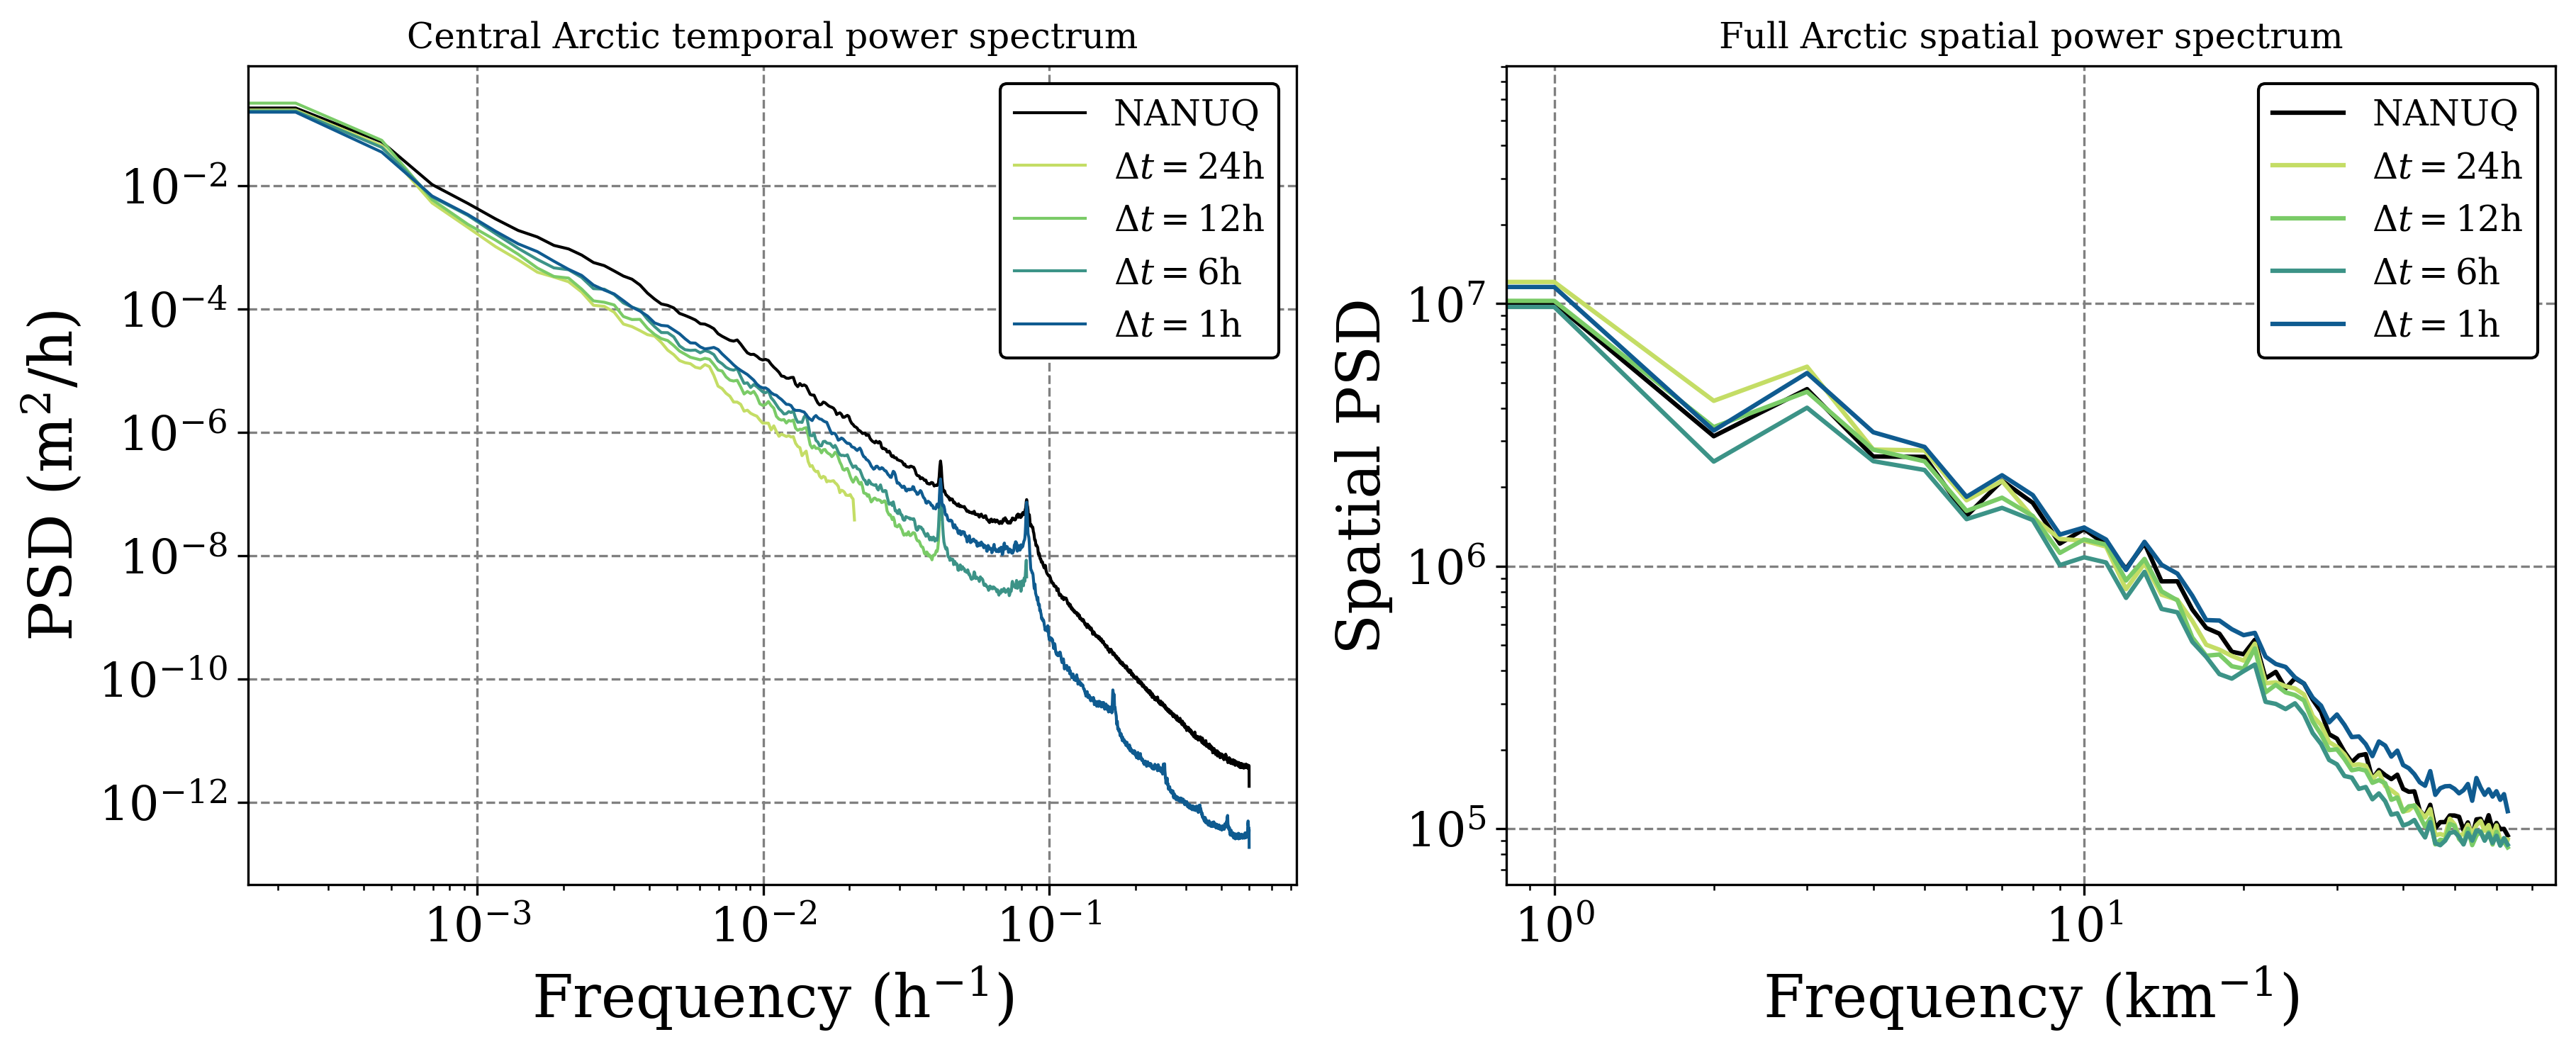

In [13]:
spsd1 = np.load('PSD_spatial_nanuq_1h_final.npy')
spsd6 = np.load('PSD_spatial_nanuq_6h_final.npy')
spsd12 = np.load('PSD_spatial_nanuq_12h_final.npy')
spsd24 = np.load('PSD_spatial_nanuq_24h_final.npy')
spsd_nanuq = np.load('PSD_spatial_nanuq_1h_truth.npy')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.loglog(f1, psd_nanuq.mean(axis = (0, 1)), color = 'k', linewidth = 1, label = "NANUQ")

ax1.loglog(f24, psd24.mean(axis = (0, 1)), color = color_dict['24h'], linewidth = 1, label = "$\Delta t = 24$h")
ax1.loglog(f12, psd12.mean(axis = (0, 1)), color = color_dict['12h'], linewidth = 1, label = "$\Delta t = 12$h")

ax1.loglog(f6, psd6.mean(axis = (0, 1)), color = color_dict['6h'], linewidth = 1, label = "$\Delta t = 6$h")

ax1.loglog(f1, psd1.mean(axis = (0, 1)), color = color_dict['1h'], linewidth = 1, label = "$\Delta t = 1$h")


ax1.set_xlabel('Frequency ($\mathrm{h}^{-1}$)')
ax1.set_ylabel('PSD ($\mathrm{m}^2/\mathrm{h}$)')
ax1.set_title('Central Arctic temporal power spectrum' , fontsize = 12)
ax1.legend(fontsize = 12)

ax2.loglog( spsd_nanuq.mean(axis = (0, 1)), color = 'k', linewidth = 1.5, label = 'NANUQ')
ax2.loglog( spsd24.mean(axis = (0, 1)),color = color_dict['24h'], linewidth = 1.5, label = "$\Delta t = 24$h")
ax2.loglog( spsd12.mean(axis = (0, 1)), color = color_dict['12h'], linewidth = 1.5, label = "$\Delta t = 12$h")
ax2.loglog( spsd6.mean(axis = (0, 1)), color = color_dict['6h'], linewidth = 1.5, label = "$\Delta t = 6$h")
ax2.loglog( spsd1.mean(axis = (0, 1)), color = color_dict['1h'], linewidth = 1.5, label = "$\Delta t = 1$h")
ax2.legend(fontsize = 12)

ax2.set_xlabel('Frequency ($\mathrm{km}^{-1}$)')
ax2.set_ylabel('Spatial PSD')
ax2.set_title('Full Arctic spatial power spectrum', fontsize= 12)

plt.savefig('spatial_temporal_PSD.png', dpi = 400, bbox_inches="tight")

# Fig 11: Fram Strait

In [3]:
ds = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
ds = ds.sel(time_counter=ds.time_counter.dt.year.isin([2019, 2020]))
ds= ds.resample(time_counter="24H", offset="12h", label="right", closed="right").mean()
ds = ds.rename({'nav_lon': 'lon','nav_lat': 'lat'})
ds = ds.assign_coords(lat=(("y","x"), ds.lat.values),
                      lon=(("y","x"), ds.lon.values))
ds = ds.isel(time_counter = slice(0, 720))

mask = np.load("../utils/mask_reduced_MIZ.npy")[:,5:-5]
mask_nan = mask.astype(float)        # make sure it’s float
mask_nan[mask_nan == 0] = np.nan     # replace 0 with NaN
import pandas as pd
export_6h_coupled_bulk = np.load("monthly_export_6h_bulk.npy")
export_6h_coupled_bulk = pd.Series(export_6h_coupled_bulk, index=pd.to_datetime(ds.time_counter.values)) 

export_6h_coupled_wo_ocean = np.load("monthly_export_6h_no_oce.npy")
export_6h_coupled_wo_ocean = pd.Series(export_6h_coupled_wo_ocean, index=pd.to_datetime(ds.time_counter.values)) 

export_nanuk_coupled = np.load("monthly_export_nanuq.npy")
export_nanuk_coupled = pd.Series(export_nanuk_coupled, index=pd.to_datetime(ds.time_counter.values)) 


pred_6h_coupled_bulk = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/test_process_True_freq_720_cycle_1_pred_0.npy')
pred_6h_coupled_wo_ocean = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_wo_ocean/test_process_True_freq_720_cycle_1_pred_0.npy')

drift_6h_coupled_bulk = np.sqrt(pred_6h_coupled_bulk[:,2,:,5:-5]**2*mask_nan + pred_6h_coupled_bulk[:,3,:,5:-5]**2*mask_nan)
drift_6h_coupled_wo_ocean = np.sqrt(pred_6h_coupled_wo_ocean[:,2,:,5:-5]**2*mask_nan + pred_6h_coupled_wo_ocean[:,3,:,5:-5]**2*mask_nan)

nanuk_coupled = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/test_process_True_freq_720_cycle_1_truth_0.npy')

drift_nanuk_coupled = np.sqrt(nanuk_coupled[:,2,:,5:-5]**2*mask_nan + nanuk_coupled[:,3,:,5:-5]**2*mask_nan)


In [ ]:
tick_params(axis='both', labelsize=10)

time_series = pd.Series(ds2.time_counter)

# Function to compute rolling mean and then spatial mean
def plot_rolling_mean(data, ax, color, linestyle, label=None):
    # Compute spatial mean (nanmean over lat, lon)
    spatial_mean = np.nanmean(data, axis=(1, 2))
    # Create a pandas Series for rolling mean
    s = pd.Series(spatial_mean, index=time_series)
    # Compute rolling mean with window=4
    rolling = s.rolling(window=4*7, center=True).mean()
    # Plot
    ax.plot(time_series, rolling, color=color, linestyle=linestyle, label=label, linewidth = 1.5)




In [ ]:
#proj = ccrs.NorthPolarStereo()

fig, ax2 = plt.subplots(1, 1, figsize=(8, 3))


ax2.plot(-export_nanuk_coupled.resample("M").mean(), label = "NANUQ", color = 'k', linewidth = 1.5)
#ax2.plot(-export_nanuk_sa.resample("M").mean(), label = "NANUQ - standalone", linestyle = 'dashed', color = 'k')

ax2.plot(-export_6h_coupled_bulk.resample("M").mean(), label=r'$\mathcal{M}_{\text{sub-surf}}\;\Delta t = 6$h', color = color_dict['6h'], linestyle = 'solid' , linewidth = 1.5)
ax2.plot(-export_6h_coupled_wo_ocean.resample("M").mean(), label='$\mathcal{M}_{\mathrm{atmo}}\;\Delta t = 6$h', color = color_dict['6h'], linestyle = 'dashed' , linewidth = 1.5)


ax2.set_title('Fram Strait monthly export', fontsize= 12)
ax2.set_ylabel('Sea ice export ($\mathrm{km}^3/\mathrm{month}$)', fontsize= 12)

ax2.grid(alpha=0.3)

# Monthly ticks, nice formatting
#ax2.xaxis.set_major_locator(mticker.MonthLocator())
#ax2.xaxis.set_major_formatter(mticker.DateFormatter("%b"))

ax2.legend(frameon=True, fontsize=10)
ax2.tick_params(axis='both', labelsize=10)


plt.savefig('fig11.pdf', dpi = 400)

# Fig 12 EREA6/JRA55-do

In [34]:
ds2 = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
ds2 = ds2.sel(time_counter=ds2.time_counter.dt.year.isin([2019, 2020])).isel(time_counter=slice(0, 2880*6, 6))

time_series = pd.Series(ds2.time_counter)
print(time_series)

/tmp/ipykernel_39175/3630946916.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds2 = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
/tmp/ipykernel_39175/3630946916.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds2 = xr.open_mfdataset('/summer/meom/MEOM-OPENDAP/simus_nanuq/NANUK1/old/NANUK1-CPL00-S/*/NANUK1-CPL00_1h_*_icemod.nc4').isel(y=slice(None,-1))
/tmp/ipykernel_39175/3630946916.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance

0      2019-01-01 00:30:00
1      2019-01-01 06:30:00
2      2019-01-01 12:30:00
3      2019-01-01 18:30:00
4      2019-01-02 00:30:00
               ...        
2875   2020-12-19 18:30:00
2876   2020-12-20 00:30:00
2877   2020-12-20 06:30:00
2878   2020-12-20 12:30:00
2879   2020-12-20 18:30:00
Length: 2880, dtype: datetime64[ns]


In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_marginals(ax, x, y, bins=50, color='blue', alpha=0.6):
    """Add marginal histograms to a scatter axis."""
    divider = make_axes_locatable(ax)

    #ax_histx = divider.append_axes("top", size="20%", pad=0.05, sharex=ax)
    ax_histy = divider.append_axes("right", size="25%", pad=0.25, sharey=ax)

    # Remove tick labels
    #plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    #ax_histx.tick_params(axis="y", left=False)
    ax_histy.tick_params(axis="x", bottom=False)

    # Histograms
    #ax_histx.hist(x, bins=bins, density=True, color=color, alpha=alpha)
    ax_histy.hist(y, bins=bins, density=True, orientation='horizontal',
                  color=color, alpha=alpha)

    # Match limits
    #ax_histx.set_xlim(ax.get_xlim())
    ax_histy.set_ylim(ax.get_ylim())
    ax_histy.set_xlim([0, 9])
    
    
avg_6h_full = np.load(path_6h + "test_process_True_freq_720_cycle_1_pred_0.npy")[0:2880:4]
avg_6h_reduced = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_reduced/test_process_True_freq_720_cycle_1_pred_0.npy')[0:2880:4]
avg_6h_jra = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_reduced/test_jra_True_cycle_1_pred_0.npy')[:2880:4]
avg_6h_nanuq = np.load(path_6h + "test_process_True_freq_720_cycle_1_truth_0.npy")[:2880:4]

time_plot = ds.time_counter

print(np.shape(avg_6h_full))
import matplotlib.gridspec as gridspec

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a figure with two subplots
# Create a figure with a custom layout
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

# Scatter plots (2x2 grid)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[0, 2])  # Bottom-left
ax4 = fig.add_subplot(gs[1, :])  # Bottom-right

# Histogram (rightmost column, spanning both rows)
#ax_hist = fig.add_subplot(gs[:, 2])

ax1.scatter(np.where(avg_6h_nanuq[:360,1]>0.15, np.sqrt(avg_6h_nanuq[:360,2]**2 +avg_6h_nanuq[:360,3]**2), np.nan),np.where(avg_6h_full[:360,1]>0.15, np.sqrt(avg_6h_full[:360,2]**2 +avg_6h_full[:360,3]**2) , np.nan), alpha = 0.05, s=0.5 , color = color_dict['6h'])
#ax1.scatter(np.where(nanuq[:360,1]>0.15, np.sqrt(nanuq[:360,2]**2 +nanuq[:360,3]**2), np.nan),np.where(pred_24h_sa[:360,1]>0.15, np.sqrt(pred_24h[:360,2]**2 +pred_24h[:360,3]**2) , np.nan), alpha = 0.12, s=1 )

ax1.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax1.set_xlim([-0.02, 0.6])
ax1.set_ylim([-0.02, 0.6])
ax1.set_title(r'$\mathcal{M}_{\text{sub-surf}}$, 6h, ERA5 forcings', fontsize=16)

#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_12h_bulk_ocean_avg/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
ax2.scatter(np.where(avg_6h_nanuq[:360,1]>0.15, np.sqrt(avg_6h_nanuq[:360,2]**2 +avg_6h_nanuq[:360,3]**2), np.nan),np.where(avg_6h_reduced[:360,1]>0.15, np.sqrt(avg_6h_reduced[:360,2]**2 +avg_6h_reduced[:360,3]**2) , np.nan), alpha = 0.05, s=0.5, color = color_dict['6h'] )
#ax2.scatter(np.where(nanuq[:720,1]>0.15, np.sqrt(nanuq[:720,2]**2 +nanuq[:720,3]**2), np.nan),np.where(pred_12h_sa[:720,1]>0.15, np.sqrt(pred_12h[:720,2]**2 +pred_12h[:720,3]**2) , np.nan), alpha = 0.06, s=1 )

ax2.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax2.set_xlim([-0.02, 0.6])
ax2.set_ylim([-0.02, 0.6])
ax2.set_title('$\mathcal{M}_{\mathrm{red}}$, 6h, ERA5 forcings', fontsize=16)


#nanuq = np.load('/summer/meom/workdir/ducharlo/results/TV/run_UNet_nanuk1_6h_bulk_ocean_avg/post_2_process_True_cycle_1_truth_0.npy')[:,:,:,5:-5]
ax3.scatter(np.where(avg_6h_nanuq[:360,1]>0.15, np.sqrt(avg_6h_nanuq[:360,2]**2 +avg_6h_nanuq[:360,3]**2), np.nan),np.where(avg_6h_jra[:360,1]>0.15, np.sqrt(avg_6h_jra[:360,2]**2 +avg_6h_jra[:360,3]**2) , np.nan), alpha = 0.05, s=0.5, color = color_dict['6h'])
#ax3.scatter(np.where(nanuq[:1440,1]>0.15, np.sqrt(nanuq[:1440,2]**2 +nanuq[:1440,3]**2), np.nan),np.where(pred_6h_sa[:1440,1]>0.15, np.sqrt(pred_6h[:1440,2]**2 +pred_6h[:1440,3]**2) , np.nan), alpha = 0.03, s=1 )

ax3.plot(np.linspace(0, 1), np.linspace(0,1), linestyle = 'dashed', linewidth = 0.1, color = 'k')
ax3.set_xlim([-0.02, 0.6])
ax3.set_ylim([-0.02, 0.6])
ax3.set_title('$\mathcal{M}_{\mathrm{red}}$, 6h, JRA55 forcings', fontsize=16)


#ax4.set_xlim([-0.02, 0.6])
#ax4.set_ylim([-0.02, 0.6])
#ax4.set_title('$\mathcal{M}_{\mathrm{bulk}}$, 1h', fontsize=16)

ax1.set_ylabel('Emulated SID', fontsize=16)
ax1.set_xlabel('Simulated SID', fontsize=16)

ax2.set_ylabel('Emulated SID', fontsize=16)
ax2.set_xlabel('Simulated SID', fontsize=16)

ax3.set_ylabel('Emulated SID', fontsize=16)
ax3.set_xlabel('Simulated SID', fontsize=16)



x = np.where(
    (avg_6h_nanuq[:360, 1] > 0.15) & (np.sqrt(avg_6h_nanuq[:360, 2]**2+avg_6h_nanuq[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_nanuq[:360, 2]**2 + avg_6h_nanuq[:360, 3]**2),
    np.nan
)

y = np.where(
    (avg_6h_jra[:360, 1] > 0.15) & (np.sqrt(avg_6h_jra[:360, 2]**2+avg_6h_jra[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_jra[:360, 2]**2 + avg_6h_jra[:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax3, x_valid, y_valid, bins=1000, color = color_dict['6h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax3.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax3.transAxes,
    fontsize = 16,
    va="top"
)

x = np.where(
    (avg_6h_nanuq[:360, 1] > 0.15) & (np.sqrt(avg_6h_nanuq[:360, 2]**2+avg_6h_nanuq[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_nanuq[:360, 2]**2 + avg_6h_nanuq[:360, 3]**2),
    np.nan
)

y = np.where(
    (avg_6h_reduced[:360, 1] > 0.15) & (np.sqrt(avg_6h_reduced[:360, 2]**2+avg_6h_reduced[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_reduced[:360, 2]**2 + avg_6h_reduced[:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y) 
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax2, x_valid, y_valid, bins=1000, color = color_dict['6h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax2.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax2.transAxes,
    fontsize = 16,
    va="top"
)

x = np.where(
    (avg_6h_nanuq[:360, 1] > 0.15) & (np.sqrt(avg_6h_nanuq[:360, 2]**2+avg_6h_nanuq[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_nanuq[:360, 2]**2 + avg_6h_nanuq[:360, 3]**2),
    np.nan
)

y = np.where(
    (avg_6h_full[:360, 1] > 0.15) & (np.sqrt(avg_6h_full[:360, 2]**2+avg_6h_full[:360, 3]**2) > 1e-3),
    np.sqrt(avg_6h_full[:360, 2]**2 + avg_6h_full[:360, 3]**2),
    np.nan
)
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]
add_marginals(ax1, x_valid, y_valid, bins=1000, color = color_dict['6h'])

r = np.corrcoef(x_valid, y_valid)[0, 1]
ax1.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax1.transAxes,
    fontsize = 16,
    va="top"
)

# Adjust layout
ax4.plot(time_plot[:720*6:6], np.nansum(np.where(avg_6h_full[:720,1,:,5:-5]>0.15, avg_6h_full[:720,0,:,5:-5]*area/1e9, np.nan), axis = (1, 2)), color = color_dict['6h'], label = r'$\mathcal{M}_{\text{sub-surf}}$, 6h, ERA5 forcings')

ax4.plot(time_plot[:720*6:6],np.nansum(np.where(avg_6h_reduced[:720,1,:,5:-5]>0.15, avg_6h_reduced[:720,0,:,5:-5]*area/1e9, np.nan), axis = (1, 2)), color = color_dict['6h'], linestyle = 'dashed', label = '$\mathcal{M}_{\mathrm{red}}$, 6h, ERA5 forcings')

ax4.plot(time_plot[:720*6:6],np.nansum(np.where(avg_6h_jra[:720,1,:,5:-5]>0.15, avg_6h_jra[:720,0,:,5:-5]*area/1e9, np.nan), axis = (1, 2)), color = color_dict['6h'], linestyle = 'dotted', label = '$\mathcal{M}_{\mathrm{red}}$, 6h, JRA55 forcings')

ax4.plot(time_plot[:720*6:6], np.nansum(np.where(avg_6h_nanuq[:720,1,:,5:-5]>0.15, avg_6h_nanuq[:720,0,:,5:-5]*area/1e9, np.nan), axis = (1, 2)), color = 'k', label = 'NANUQ')
ax4.legend(fontsize = 16)
ax4.set_ylabel('SIV ($\mathrm{km}^3$)', fontsize = 16)
#ax_hist = fig.add_subplot(gs[:, 2], projection="polar")

#ax_hist.hist(dtheta24, bins=600, density=True, label = '$\Delta\mathrm{t}$ = 24h', color = color_dict['24h'])
#ax_hist.hist(dtheta12, bins=600, density=True, alpha = 0.7, label = '$\Delta\mathrm{t}$ = 12h', color = color_dict['12h'])
#ax_hist.hist(dtheta6, bins=600, density=True, alpha = 0.5, label = '$\Delta\mathrm{t}$ = 6h', color = color_dict['6h'])
#ax_hist.hist(dtheta1, bins=600, density=True, alpha = 0.3, label = '$\Delta\mathrm{t}$ = 1h', color = color_dict['1h'])
#ax_hist.legend(fontsize = 10, loc = 'center left')
#ax_hist.set_theta_zero_location("N")
#ax_hist.set_theta_direction(-1)
#mean_err24 = np.degrees(np.arctan2(
#    np.nanmean(np.sin(dtheta24)),
#    np.nanmean(np.cos(dtheta24))
#))

#std_err24 = np.degrees(np.sqrt(
#    -2 * np.log(
#        np.sqrt(
#            np.nanmean(np.cos(dtheta24))**2 +
#            np.nanmean(np.sin(dtheta24))**2
#        )
#    )
#))

#mean_err12 = np.degrees(np.arctan2(
#    np.nanmean(np.sin(dtheta12)),
#    np.nanmean(np.cos(dtheta12))
#))

#std_err12 = np.degrees(np.sqrt(
#    -2 * np.log(
#        np.sqrt(
#            np.nanmean(np.cos(dtheta12))**2 +
#            np.nanmean(np.sin(dtheta12))**2
#        )
#    )
#))

#mean_err6 = np.degrees(np.arctan2(
#    np.nanmean(np.sin(dtheta6)),
#    np.nanmean(np.cos(dtheta6))
#))

#std_err6 = np.degrees(np.sqrt(
#    -2 * np.log(
#        np.sqrt(
#            np.nanmean(np.cos(dtheta6))**2 +
#           np.nanmean(np.sin(dtheta6))**2
#        )
#    )
#))

#mean_err1 = np.degrees(np.arctan2(
#    np.nanmean(np.sin(dtheta1)),
#    np.nanmean(np.cos(dtheta1))
#))

#std_err1 = np.degrees(np.sqrt(
#    -2 * np.log(
#        np.sqrt(
#            np.nanmean(np.cos(dtheta1))**2 +
#            np.nanmean(np.sin(dtheta1))**2
#        )
#    )
#))

#stats_text = (
#    r"$\Delta t = 24$h: "
#    f"mean = {mean_err24:.1f}°, std = {std_err24:.1f}°\n"
#   r"$\Delta t = 12$h: "
#    f"mean = {mean_err12:.1f}°, std = {std_err12:.1f}°\n"
#    r"$\Delta t = 6$h: "
#    f"mean = {mean_err6:.1f}°, std = {std_err6:.1f}°\n"
#    r"$\Delta t = 1$h: "
#    f"mean = {mean_err1:.1f}°, std = {std_err1:.1f}°"
#)
#fig.text(
#    0.78, 0.2,              # centered, bottom
#    stats_text,
#    ha="center",
#    va="bottom",
#    fontsize=10,
#    bbox=dict(
#        facecolor="white",
#        edgecolor="black"
#    )
#)
#ax_hist.set_yticklabels([])
#ax_hist.set_title('SID azimutal errors', fontsize = 13)
plt.savefig('fig12.png', transparent = True, dpi = 400)

# Fig 13: Plot SIC correlations

In [10]:
corr_map_truth = np.load('corr_map_truth_sic.npy')
corr_map_pred6h = np.load('corr_map_pred6h_sic.npy')
corr_map_pred6h_atmo = np.load('corr_map_pred6h_jra_sic.npy')

corr_time_truth = np.load('corr_time_truth_sic.npy')
corr_time_pred = np.load('corr_time_nanuq6_sic.npy')
corr_time_pred6h_atmo = np.load('corr_time_nanuq6_jra_sic.npy')

obs_sic= xr.open_dataset('data_test_sic_obs.nc')
time = obs_sic.time[:720]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Choose the colormap (e.g., 'thermal')
cmap = cmocean.cm.haline

# Sample N colors from the colormap
N = 9  # Number of colors to sample
colors = cmap(np.linspace(0, 1, N))

# Create a dictionary for easy access
#color_dict = {f"color_{i}": colors[i] for i in range(N)}
color_dict = {}
color_dict["1h"]=colors[2]
color_dict["6h"]=colors[4]
color_dict["12h"]=colors[6]
color_dict["24h"]=colors[7]

# --- Projection ---
proj = ccrs.NorthPolarStereo(central_longitude=0)  # adjust central_longitude to your domain
data_crs = ccrs.PlateCarree()  # lat/lon data is always PlateCarree

# --- Layout ---
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, height_ratios=[2.5, 1], hspace=0.05, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax_time = fig.add_subplot(gs[1, :])

# --- Helper to plot one map ---
def plot_corr(ax, data, title):
    ax.set_extent([-180, 180, 50, 90], crs=data_crs)
    
    im = ax.pcolormesh(
        lon, lat, data,
        vmin=0, vmax=1,
        cmap=cmocean.cm.thermal,
        transform=data_crs,
        shading='auto'
    )
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE, zorder=2, linewidth=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=11, pad=6)
    
    # Compute and annotate average correlation (ignoring NaNs)
    avg_corr = np.nanmean(data)
    ax.text(
        0.5, -0.02,
        f"$\\bar{{r}}$ = {avg_corr:.3f}",
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=10,
    )
    
    return im
corr_map_truth = np.load('corr_map_truth_sic.npy')
corr_map_pred6h = np.load('corr_map_pred6h_sic.npy')
corr_map_pred6h_jra = np.load('corr_map_pred6h_jra_sic.npy')

corr_time_truth = np.load('corr_time_truth_sic.npy')
corr_time_pred = np.load('corr_time_nanuq6_sic.npy')
corr_time_pred6h_jra = np.load('corr_time_nanuq6_jra_sic.npy')

obs_sic= xr.open_dataset('data_test_sic_obs.nc')
time = obs_sic.time[:720]
im1 = plot_corr(ax1, corr_map_truth,     "NANUQ")
im2 = plot_corr(ax2, corr_map_pred6h, r"$\mathcal{M}_{\text{sub-surf}}$ ERA5")
im3 = plot_corr(ax3, corr_map_pred6h_jra, "$\mathcal{M}_{\mathrm{red}}$ JRA55")

# Shared colorbar
cbar = fig.colorbar(
    im1, ax=[ax1, ax2, ax3],
    orientation="vertical",
    label="Correlation",
    shrink=0.85,
    pad=0.02
)


ax_time.plot(time, corr_time_truth,         color='k',                linestyle='solid',  label=r'NANUQ')
ax_time.plot(time, corr_time_pred,        color=color_dict['6h'],   linestyle='solid',  label=r'$\mathcal{M}_{\text{sub-surf}}$, ERA5 forcings')
ax_time.plot(time, corr_time_pred6h_jra,   color=color_dict['6h'],   linestyle='dashed', label=r'$\mathcal{M}_{\mathrm{red}}$ JRA55 forcings')
ax_time.set_ylabel("Correlation")
ax_time.set_xlabel("Time step")
ax_time.legend(fontsize = 11)
ax_time.set_ylim(-0, 1)
ax_time.grid(alpha=0.3)

#plt.suptitle("Spatial and temporal correlation", fontsize=13)
plt.savefig("fig13.pdf", bbox_inches="tight")
plt.show()

# Fig 14 Plot SID drift correlation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Choose the colormap (e.g., 'thermal')
cmap = cmocean.cm.haline

# Sample N colors from the colormap
N = 9  # Number of colors to sample
colors = cmap(np.linspace(0, 1, N))

color_dict = {}
color_dict["1h"] = colors[2]
color_dict["6h"] = colors[4]
color_dict["12h"] = colors[6]
color_dict["24h"] = colors[7]

# --- Projection ---
proj = ccrs.NorthPolarStereo(central_longitude=0)
data_crs = ccrs.PlateCarree()

# --- Layout ---
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, height_ratios=[2.5, 1], hspace=0.05, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax_time = fig.add_subplot(gs[1, :])

# --- Helper to plot one map ---
def plot_corr(ax, data, title):
    ax.set_extent([-180, 180, 50, 90], crs=data_crs)

    im = ax.pcolormesh(
        lon, lat, data,
        vmin=0, vmax=1,
        cmap=cmocean.cm.thermal,
        transform=data_crs,
        shading='auto'
    )
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgray')
    ax.add_feature(cfeature.COASTLINE, zorder=2, linewidth=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=11, pad=6)

    return im

corr_map_truth = np.load('6h_corr_nanuq.npy')
corr_map_pred6h = np.load('6h_corr_nainuq_bulk.npy')
corr_map_pred6h_jra = np.load('6h_corr_nainuq_jra.npy')
corr_time_truth = np.load('6h_corr_nanuq_time.npy')
corr_time_pred = np.load('6h_corr_nainuq_bulk_time.npy')
corr_time_pred6h_jra = np.load('6h_corr_nainuq_jra_time.npy')
obs_sic = xr.open_dataset('data_test_sic_obs.nc')
time = obs_sic.time[:720]

im1 = plot_corr(ax1, corr_map_truth, "NANUQ")
im2 = plot_corr(ax2, corr_map_pred6h, r"$\mathcal{M}_{\text{sub-surf}}$ ERA5")
im3 = plot_corr(ax3, corr_map_pred6h_jra, r"$\mathcal{M}_{\mathrm{red}}$ JRA55")

# ======================================================
# Shared colorbar, matched to map row height
# ======================================================
# Force a draw so axes positions (post-cartopy-clipping) are finalized
fig.canvas.draw()

pos1 = ax1.get_position()
pos3 = ax3.get_position()

cbar_width = 0.015
cbar_pad = 0.012

cbar_ax = fig.add_axes([
    pos3.x1 + cbar_pad,   # left edge: just right of the last map
    pos3.y0,              # bottom: aligned with bottom of map row
    cbar_width,           # width
    pos1.y1 - pos1.y0     # height: exactly the map row height
])

cbar = fig.colorbar(im1, cax=cbar_ax, orientation="vertical", label="Correlation")

# --- Time series panel ---
ax_time.plot(time, corr_time_truth, color='k', linestyle='solid', label=r'NANUQ', linewidth=1)
ax_time.plot(time, corr_time_pred, color=color_dict['6h'], linestyle='solid',
             label=r'$\mathcal{M}_{\text{sub-surf}}$, ERA5', linewidth=1)
ax_time.plot(time, corr_time_pred6h_jra, color=color_dict['6h'], linestyle='dashed',
             label=r'$\mathcal{M}_{\mathrm{red}}$ JRA55', linewidth=1)
ax_time.set_ylabel("Correlation", fontsize = 11)
ax_time.set_xlabel("Time", fontsize = 11)
ax_time.legend(fontsize=11)
ax_time.set_ylim(-0.5, 1)
ax_time.grid(alpha=0.3)

plt.savefig("fig14.pdf", bbox_inches="tight")
plt.show()

In [35]:
print(corr_time_truth.mean())  
print(corr_time_pred.mean())

0.801310219895693
0.8148887823314588


# Fig A2 6h grid search

In [ ]:
norm = np.load('/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h/sea_ice_std_input.npy')

import matplotlib.lines as mlines
#bulk_1h = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_1h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_10/post_2_process_True_cycle_1_pred_0.npy')
#bulk_6h = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_1/post_2_process_True_cycle_1_pred_0.npy')
#bulk_12h = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_12h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_0.1/post_2_process_True_cycle_1_pred_0.npy')
#bulk_24h = np.load('/summer/sasip/workdir/ducharlo/results/2026/grid_24h_new_ts/lambda_bias_0_lambda_TV_0.1_lambda_PINN_1/post_2_process_True_cycle_1_pred_0.npy')


dt = [1, 6, 12, 24]
TV = [0.1, 0.1, 0.1, 0.1]
PINN = [10, 1, 0.1, 1]
# Define the parameter values
lambda_bias_values = [0, 1, 5, 10]
lambda_TV_values = [0, 0.05, 0.07, 0.1, 1]
lambda_PINN_values = [0, 0.1, 1, 5, 10]

# Initialize 3D arrays to store the results
results_st = np.full((4, 5, 5, 5), np.nan)
results_lt = np.full((4, 5, 5, 5), np.nan)

# Base directories where the results are saved
base_dir1 = '/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts/'
base_dir2 = '/summer/sasip/workdir/ducharlo/results/2026/grid_6h_new_ts_2/'

# Loop over the parameter values
for i, lambda_bias in enumerate(lambda_bias_values):
    for j, lambda_TV in enumerate(lambda_TV_values):
        for k, lambda_PINN in enumerate(lambda_PINN_values):
            # Construct the directory name
            dir_name = f'lambda_bias_{lambda_bias}_lambda_TV_{lambda_TV}_lambda_PINN_{lambda_PINN}'

            # Check both base directories for the file
            file_found = False
            for base_dir in [base_dir1, base_dir2]:
                file_path_st = os.path.join(base_dir, dir_name, 'test_results/post_2_process_cycle_600_fs_mean.npy')
                file_path_lt = os.path.join(base_dir, dir_name, 'test_results/post_2_process_cycle_1_fs_mean.npy')

                if os.path.exists(file_path_st) and os.path.exists(file_path_lt):
                    results_st[i, j, k] = np.load(file_path_st)[:, 40].mean(axis=0)
                    results_lt[i, j, k] = np.load(file_path_lt)[0].mean(axis=0)
                    file_found = True
                    break

            if not file_found:
                print(f"Warning: Files not found for {dir_name}")

# Optionally, print or save the results
print("Short-term results shape:", results_st.shape)
print("Long-term results shape:", results_lt.shape)
results_pers_lt = np.load(os.path.join(base_dir, dir_name, 'test_results/post_2_process_cycle_1_fs_mean_pers.npy'))[0].mean(axis = 0)
results_pers_st = np.load(os.path.join(base_dir, dir_name, 'test_results/post_2_process_cycle_600_fs_mean_pers.npy'))[:,40].mean(axis = 0)
results_st_flat = results_st[:, :, :, 0].flatten()
results_lt_flat = results_lt[:, :, :, 0].flatten()

# Create a list to store colors and markers for each point
colors = []
markers = []

plt.figure(figsize=(8, 5))

# Loop over the lambda values to assign colors and markers
for i, lambda_bias in enumerate(lambda_bias_values):
    for j, lambda_TV in enumerate(lambda_TV_values):
        for k, lambda_PINN in enumerate(lambda_PINN_values):
            # Assign colors based on lambda values (example: use a colormap)
            color = plt.cm.viridis(i / len(lambda_bias_values))
            colors.append(color)
            s=[10, 50, 70, 100, 120]
            # Assign markers based on lambda values (example: use different markers)
            marker_list = ['o', 's', '^', '<', '>', 'D', '*']
            marker = marker_list[j]
            markers.append(marker)

            # Create the scatter plot
            scatter = plt.scatter(
                np.mean(norm*results_st[i, j, k]),
                np.mean(norm*results_lt[i, j, k]),
                c=color,
                marker=marker,  # Default marker, will be overridden by loop
                s=s[k],
                alpha=0.7,
                edgecolors='black',
                linewidths=0.5
                )

# Create a legend for lambda values
legend_elements = [
    mlines.Line2D([], [], color=plt.cm.viridis(i / len(lambda_bias_values)), marker='o', linestyle='None',
                  markersize=10, label=rf'$\lambda_{{\mathrm{{bias}}}}$={lambda_bias}')
    for i, lambda_bias in enumerate(lambda_bias_values)
] + [
    mlines.Line2D([], [], color='gray', marker=marker, linestyle='None',
                  markersize=10, label=rf'$\lambda_{{\mathrm{{TV}}}}$={lambda_TV}')
    for marker, lambda_TV in zip(['o', 's', '^', '<', '>'], lambda_TV_values)
] + [
    mlines.Line2D([], [], color='gray', marker='D', linestyle='None',
                  markersize=marker, label=rf'$\lambda_{{\mathrm{{PINN}}}}$={lambda_PINN}')
    for marker, lambda_PINN in zip([1, 5, 7, 10, 13], lambda_PINN_values)
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 14)
plt.xlabel('10 day nRMSE (-)', fontsize = 14)
plt.ylabel('1 year nRMSE(-)', fontsize = 14)
plt.title(r'$\mathcal{M}_{\text{sub-surf}},\; \Delta t = 6$h grid search results', fontsize = 14)
plt.grid(True)
plt.tight_layout()
plt.tick_params(axis='both', labelsize=14)

plt.savefig("fig16.pdf")

# Fig C1 ablation evaluation

In [6]:
fs_1h_full = np.load(path_1h + "test_results/test_post_2_process_cycle_1_fs_mean.npy")
fs_1h_reduced = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_1h_reduced/test_results/test_post_2_process_cycle_1_fs_mean.npy')
#fs_1h_era = np.load('/summer/sasip/workdir/ducharlo/results/TV/run_UNet_nanuk1_1h_reduced/')

fs_6h_full = np.load(path_6h + "test_results/test_post_2_process_cycle_1_fs_mean.npy")
fs_6h_reduced = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_reduced/test_results/test_post_2_process_cycle_1_fs_mean.npy')
fs_6h_jra = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_6h_reduced/test_results/jra_cycle_1_fs_mean.npy')

fs_12h_full = np.load(path_12h +  "test_results/test_post_2_process_cycle_1_fs_mean.npy")
fs_12h_reduced = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_12h_reduced/test_results/test_post_2_process_cycle_1_fs_mean.npy')
fs_12h_jra = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_12h_reduced/test_results/jra_cycle_1_fs_mean.npy')


fs_24h_full = np.load(path_24h + "test_results/test_post_2_process_cycle_1_fs_mean.npy")
fs_24h_reduced = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_24h_reduced/test_results/test_post_2_process_cycle_1_fs_mean.npy')
fs_24h_jra = np.load('/summer/sasip/workdir/ducharlo/results/run_UNet_nanuk1_24h_reduced/test_results/jra_cycle_1_fs_mean.npy')


In [7]:
N_t = np.arange(8640)

In [ ]:
import matplotlib.dates as mdates

time = time_plot[:17280]
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize = (12, 8))

#ax1.plot(time, fs_1h_full[0,:,0], color = color_dict["1h"], label = '$\Delta t =1$h', linewidth = 1)
#ax1.plot(time, fs_1h_reduced[0,:,0], color = color_dict["1h"], linestyle = 'dashed', linewidth = 1)

#ax1.plot(time[::6], fs_6h_full[0,:,0], color = color_dict["6h"], label = '$\Delta t =6$h', linewidth = 1)
ax1.plot(time[::6], fs_6h_reduced[0,:,0], color = color_dict["6h"], linestyle = 'dashed', linewidth = 1)
ax1.plot(time[::6], fs_6h_jra[0,:,0], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

#ax1.plot(time[::12], fs_12h_full[0,:,0], color = color_dict["12h"], label = '$\Delta t =11$h', linewidth = 1)
ax1.plot(time[::12], fs_12h_reduced[0,:,0], color = color_dict["12h"], linestyle = 'dashed', linewidth = 1)
ax1.plot(time[::12], fs_12h_jra[0,:,0], color = color_dict["12h"], linestyle = 'dotted', linewidth = 1)

#ax1.plot(time[::24], fs_24h_full[0,:,0], color = color_dict["24h"], label = '$\Delta t =24$h', linewidth = 1)
ax1.plot(time[::24], fs_24h_reduced[0,:,0], color = color_dict["24h"], linestyle = 'dashed', linewidth = 1)
ax1.plot(time[::24], fs_24h_jra[0,:,0], color = color_dict["24h"], linestyle = 'dotted', linewidth = 1)

ax1.legend(fontsize = 11)

#ax2.plot(time, fs_1h_full[0,:,1], color = color_dict["1h"], label = '$\Delta t =1$h', linewidth = 1)
#ax2.plot(time, fs_1h_reduced[0,:,1], color = color_dict["1h"], linestyle = 'dashed', linewidth = 1)

#ax2.plot(time[::6], fs_6h_full[0,:,1], color = color_dict["6h"], label = '$\Delta t =6$h', linewidth = 1)
ax2.plot(time[::6], fs_6h_reduced[0,:,1], color = color_dict["6h"], linestyle = 'dashed', linewidth = 1)
ax2.plot(time[::6], fs_6h_jra[0,:,1], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

#ax2.plot(time[::12], fs_12h_full[0,:,1], color = color_dict["12h"], label = '$\Delta t =11$h', linewidth = 1)
ax2.plot(time[::12], fs_12h_reduced[0,:,1], color = color_dict["12h"], linestyle = 'dashed', linewidth = 1)
ax2.plot(time[::12], fs_12h_jra[0,:,1], color = color_dict["12h"], linestyle = 'dotted', linewidth = 1)

#ax2.plot(time[::24], fs_24h_full[0,:,1], color = color_dict["24h"], label = '$\Delta t =24$h', linewidth = 1)
ax2.plot(time[::24], fs_24h_reduced[0,:,1], color = color_dict["24h"], linestyle = 'dashed', linewidth = 1)
ax2.plot(time[::24], fs_24h_jra[0,:,1], color = color_dict["24h"], linestyle = 'dotted', linewidth = 1)


#ax3.plot(time, fs_1h_full[0,:,2], color = color_dict["1h"], label = '$\Delta t =1$h', linewidth = 1)
#ax3.plot(time, fs_1h_reduced[0,:,2], color = color_dict["1h"], linestyle = 'dashed', linewidth = 1)

#ax3.plot(time[::6], fs_6h_full[0,:,2], color = color_dict["6h"], label = '$\Delta t =6$h', linewidth = 1)
ax3.plot(time[::6], fs_6h_reduced[0,:,2], color = color_dict["6h"], linestyle = 'dashed', linewidth = 1)
ax3.plot(time[::6], fs_6h_jra[0,:,2], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

#ax3.plot(time[::12], fs_12h_full[0,:,2], color = color_dict["12h"], label = '$\Delta t =11$h', linewidth = 1)
ax3.plot(time[::12], fs_12h_reduced[0,:,2], color = color_dict["12h"], linestyle = 'dashed', linewidth = 1)
ax3.plot(time[::12], fs_12h_jra[0,:,2], color = color_dict["12h"], linestyle = 'dotted', linewidth = 1)

#ax3.plot(time[::24], fs_24h_full[0,:,2], color = color_dict["24h"], label = '$\Delta t =24$h', linewidth = 1)
ax3.plot(time[::24], fs_24h_reduced[0,:,2], color = color_dict["24h"], linestyle = 'dashed', linewidth = 1)
ax3.plot(time[::24], fs_24h_jra[0,:,2], color = color_dict["24h"], linestyle = 'dotted', linewidth = 1)


#ax4.plot(time, fs_1h_full[0,:,4], color = color_dict["1h"], label = '$\Delta t =1$h', linewidth = 1)
#ax4.plot(time, fs_1h_reduced[0,:,4], color = color_dict["1h"], linestyle = 'dashed', linewidth = 1)

#ax4.plot(time[::6], fs_6h_full[0,:,4], color = color_dict["6h"], label = '$\Delta t =6$h', linewidth = 1)
ax4.plot(time[::6], fs_6h_reduced[0,:,4], color = color_dict["6h"], linestyle = 'dashed', linewidth = 1)
ax4.plot(time[::6], fs_6h_jra[0,:,4], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

#ax4.plot(time[::12], fs_12h_full[0,:,4], color = color_dict["12h"], label = '$\Delta t =11$h', linewidth = 1)
ax4.plot(time[::12], fs_12h_reduced[0,:,4], color = color_dict["12h"], linestyle = 'dashed', linewidth = 1)
ax4.plot(time[::12], fs_12h_jra[0,:,4], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

#ax4.plot(time[::24], fs_24h_full[0,:,4], color = color_dict["24h"], label = '$\Delta t =24$h', linewidth = 1)
ax4.plot(time[::24], fs_24h_reduced[0,:,4], color = color_dict["24h"], linestyle = 'dashed', linewidth = 1)
ax4.plot(time[::24], fs_24h_jra[0,:,4], color = color_dict["6h"], linestyle = 'dotted', linewidth = 1)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

ax1.tick_params(labelsize=11)
ax2.tick_params(labelsize=11)
ax3.tick_params(labelsize=11)
ax4.tick_params(labelsize=11)

ax1.set_ylabel("SIV RMSE (m)", fontsize = 11)
ax2.set_ylabel("SIC RMSE", fontsize = 11)
ax3.set_ylabel("$\mathrm{SID}_x$ RMSE (m/s)", fontsize = 11)
ax4.set_ylabel("SNV RMSE(m)", fontsize = 11)
plt.suptitle('All atmospheric forcings (solid) vs reduced atmospheric forcings (dashed)', fontsize = 12)
plt.savefig("ablation_fs.pdf")

# Fig C2 : JRA/ERA distribution 

In [ ]:
inputs_era = xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_24h_reduced/test/data_2019_merged.nc')
inputs_jra = xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_24h_reduced/test/data_2019_jra_merged.nc')

inputs_era = inputs_era.isel(time = slice(0, -1, 24))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (20, 20))

ax1.hist(inputs_jra.uas.data.flatten(), bins = 1000, log = False, label = "JRA55")
ax1.hist(inputs_era.u10.data.flatten(), bins = 1000, alpha = 0.5, log = False, label = "ERA5")
ax1.set_ylim([0, 12000])
ax1.legend()

ax2.hist(inputs_jra.vas.data.flatten(), bins = 1000, log = False, label = "JRA55")
ax2.hist(inputs_era.v10.data.flatten(), bins = 1000, alpha = 0.5, log = False, label = "ERA5")
ax2.legend()
ax2.set_ylim([0, 12000])


ax3.hist(inputs_jra.tas.data.flatten(), bins = 1000, log = False, label = "JRA55")
ax3.hist(inputs_era.var167.data.flatten(), bins = 1000, alpha = 0.5, log = False, label = "ERA5")
ax3.legend()
ax3.set_ylim([0, 80000])
ax3.set_xlim([-1, 1])


ax4.hist(inputs_jra.tprecip.data.flatten(), bins = 10000, log = True, label = "JRA55")
ax4.hist(inputs_era.var55.data.flatten(), bins = 10000, alpha = 0.5, log = True, label = "ERA5")
ax4.legend()
ax4.set_ylim([0, 100000])
ax4.set_xlim([-1, 40])

ax1.set_title('10 meter meridional winds')
ax2.set_title('10 meter zonal winds')
ax3.set_title('2 meter temperature')
ax4.set_title('Mean precipitation rate')


plt.savefig('hist_jra_era.png', dpi = 600)

# Fig D1: ACF

In [ ]:
ds_1h_input=xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h_reduced/val/data_2018_sea_ice_input_normalized.nc')
ds_1h_output=xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h_reduced/val/data_2018_sea_ice_output_normalized.nc')
ds_6h_input=xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_6h_reduced/val/data_2018_sea_ice_input_normalized.nc')
ds_6h_output=xr.open_dataset('/summer/sasip/workdir/ducharlo/dataset/nanuk1_6h_reduced/val/data_2018_sea_ice_output_normalized.nc')

In [24]:
"""
Signal-to-noise ratio analysis of SID tendencies at 1h vs 6h resolution.

Hypothesis: the 1h emulator underperforms on SID because the 1h tendencies
(network outputs) have a much lower signal-to-noise ratio than the 6h
tendencies, making them intrinsically harder to learn.

Run this on a machine with access to /summer/sasip/...
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Load datasets (fixed naming bug: _input vs _output)
# ------------------------------------------------------------------
base_1h = '/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h_reduced/val/'
base_6h = '/summer/sasip/workdir/ducharlo/dataset/nanuk1_6h_reduced/val/'

ds_1h_input  = xr.open_dataset(base_1h + 'data_2018_sea_ice_input_normalized.nc')
ds_1h_output = xr.open_dataset(base_1h + 'data_2018_sea_ice_output_normalized.nc')
ds_6h_input  = xr.open_dataset(base_6h + 'data_2018_sea_ice_input_normalized.nc')
ds_6h_output = xr.open_dataset(base_6h + 'data_2018_sea_ice_output_normalized.nc')

# Adjust these variable names to match your actual dataset
SID_X = "u_ice"   # e.g. could be "sid_x", "siu", etc — check ds.data_vars
SID_Y = "v_ice"

print("1h output variables:", list(ds_1h_output.data_vars))
print("6h output variables:", list(ds_6h_output.data_vars))


def snr_map(ds_output, var, time_dim="time"):
    """
    Per-grid-cell signal-to-noise ratio of the tendency:
    SNR = |mean(tendency)| / std(tendency), computed over time.
    """
    tendency = ds_output[var]
    mu = tendency.mean(dim=time_dim)
    sigma = tendency.std(dim=time_dim)
    snr = np.abs(mu) / sigma.where(sigma > 0)
    return snr


def domain_avg_snr(ds_output, var, time_dim="time"):
    """
    Scalar global SNR: ratio of the area-mean absolute tendency
    to the area-mean temporal std of the tendency. More robust
    than per-cell SNR when many cells have near-zero variance.
    """
    tendency = ds_output[var]
    mu_abs = np.abs(tendency).mean()
    sigma = tendency.std(dim=time_dim).mean()
    return float(mu_abs / sigma)


# ------------------------------------------------------------------
# 2. Compute per-cell SNR maps for SID_x at both resolutions
# ------------------------------------------------------------------
snr_1h_x = snr_map(ds_1h_output, SID_X)
snr_6h_x = snr_map(ds_6h_output, SID_X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
vmax = np.nanpercentile(np.concatenate([snr_1h_x.values.ravel(),
                                         snr_6h_x.values.ravel()]), 95)
snr_1h_x.plot(ax=axes[0], vmin=0, vmax=vmax, cmap="viridis", add_colorbar=True)
axes[0].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 1\,$h")
snr_6h_x.plot(ax=axes[1], vmin=0, vmax=vmax, cmap="viridis", add_colorbar=True)
axes[1].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 6\,$h")
plt.tight_layout()
plt.savefig("snr_maps_sid_x.png", dpi=150)
plt.close()

# ------------------------------------------------------------------
# 3. Global scalar SNR comparison (bar chart) across variables
# ------------------------------------------------------------------
variables = [SID_X, SID_Y]  # extend with SIV, SIC, SNV for comparison
snr_1h_vals = [domain_avg_snr(ds_1h_output, v) for v in variables]
snr_6h_vals = [domain_avg_snr(ds_6h_output, v) for v in variables]

x = np.arange(len(variables))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, snr_1h_vals, width, label=r"$\Delta t = 1\,$h")
ax.bar(x + width/2, snr_6h_vals, width, label=r"$\Delta t = 6\,$h")
ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("Domain-averaged SNR")
ax.set_title("Tendency SNR: 1h vs 6h")
ax.legend()
plt.tight_layout()
plt.savefig("snr_bar_comparison.png", dpi=150)
plt.close()

print("Global SNR (1h):", dict(zip(variables, snr_1h_vals)))
print("Global SNR (6h):", dict(zip(variables, snr_6h_vals)))

# ------------------------------------------------------------------
# 4. Lag-1 autocorrelation of the tendency (area-averaged time series)
#    A noise-dominated signal -> autocorrelation near 0
#    A physically-driven signal -> non-negligible autocorrelation
# ------------------------------------------------------------------
def lag1_autocorr(ts):
    ts = ts - ts.mean()
    return float(np.corrcoef(ts[:-1], ts[1:])[0, 1])

ts_1h_x = ds_1h_output[SID_X].mean(dim=[d for d in ds_1h_output[SID_X].dims if d != "time"]).values
ts_6h_x = ds_6h_output[SID_X].mean(dim=[d for d in ds_6h_output[SID_X].dims if d != "time"]).values

print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: {lag1_autocorr(ts_1h_x):.3f}")
print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: {lag1_autocorr(ts_6h_x):.3f}")

# ------------------------------------------------------------------
# 5. Histogram comparison of tendency distributions
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ds_1h_output[SID_X].values.ravel(), bins=200, density=True,
        alpha=0.5, label=r"$\Delta t = 1\,$h", range=(-3, 3))
ax.hist(ds_6h_output[SID_X].values.ravel(), bins=200, density=True,
        alpha=0.5, label=r"$\Delta t = 6\,$h", range=(-3, 3))
ax.set_xlabel(r"Normalized $\Delta\mathrm{SID}_x$ tendency")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("tendency_histograms.png", dpi=150)
plt.close()

print("Done. Check snr_maps_sid_x.png, snr_bar_comparison.png, tendency_histograms.png")

1h output variables: ['sivolu', 'siconc', 'u_ice', 'v_ice', 'snvolu']
6h output variables: ['sivolu', 'siconc', 'u_ice', 'v_ice', 'snvolu']
Global SNR (1h): {'u_ice': 0.47393170107903576, 'v_ice': 0.47014100588603763}
Global SNR (6h): {'u_ice': 0.4979873835733234, 'v_ice': 0.49214053487306914}
Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: 0.872
Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: 0.930
Done. Check snr_maps_sid_x.png, snr_bar_comparison.png, tendency_histograms.png


In [8]:
"""
Signal-to-noise ratio analysis of SID tendencies at 1h vs 6h resolution.

Hypothesis: the 1h emulator underperforms on SID because the 1h tendencies
(network outputs) have a much lower signal-to-noise ratio than the 6h
tendencies, making them intrinsically harder to learn.

Run this on a machine with access to /summer/sasip/...
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Load datasets (fixed naming bug: _input vs _output)
# ------------------------------------------------------------------
base_1h = '/summer/sasip/workdir/ducharlo/dataset/nanuk1_1h_reduced/val/'
base_6h = '/summer/sasip/workdir/ducharlo/dataset/nanuk1_6h_reduced/val/'

ds_1h_input  = xr.open_dataset(base_1h + 'data_2018_sea_ice_input_normalized.nc')
ds_1h_output = xr.open_dataset(base_1h + 'data_2018_sea_ice_output_normalized.nc')
ds_6h_input  = xr.open_dataset(base_6h + 'data_2018_sea_ice_input_normalized.nc')
ds_6h_output = xr.open_dataset(base_6h + 'data_2018_sea_ice_output_normalized.nc')

# Adjust these variable names to match your actual dataset
SID_X = "u_ice"   # e.g. could be "sid_x", "siu", etc — check ds.data_vars
SID_Y = "v_ice"

print("1h output variables:", list(ds_1h_output.data_vars))
print("6h output variables:", list(ds_6h_output.data_vars))
print("1h input variables :", list(ds_1h_input.data_vars))


def to_ocean_mask(mask_array):
    """
    Convert a land/ocean numpy mask into a boolean ocean mask
    (True = ocean, False = land), handling either convention:
      - 1 = ocean, 0 = land
      - 1 = land,  0 = ocean
    Adjust the `>` test below if your mask uses a different convention.
    Also squeezes out any singleton dimensions (e.g. a leftover
    time/channel axis of size 1).
    """
    mask_array = np.asarray(mask_array)
    #mask_array = np.squeeze(mask_array)
    return mask_array > 0  # <-- flip to `mask_array == 0` if 1 means land


def spatial_dims_of(da, time_dim="time"):
    """Return the dims of a DataArray excluding the time dimension."""
    return [d for d in da.dims if d != time_dim]


def mask_as_dataarray(ocean_mask, da, time_dim="time"):
    """
    Wrap a 2D numpy ocean mask into an xarray DataArray whose dims
    match the spatial dims of `da` (i.e. all dims except time),
    matched by name rather than position.
    """
    sdims = spatial_dims_of(da, time_dim)
    if ocean_mask.ndim != len(sdims):
        raise ValueError(
            f"Mask has {ocean_mask.ndim} dims {ocean_mask.shape}, "
            f"but data has {len(sdims)} spatial dims {sdims} "
            f"with shape {[da.sizes[d] for d in sdims]}. "
            "Check that the mask matches the grid used for this resolution."
        )
    return xr.DataArray(ocean_mask, dims=sdims)


def snr_map(ds_output, var, ocean_mask, time_dim="time"):
    """
    Per-grid-cell signal-to-noise ratio of the tendency:
    SNR = |mean(tendency)| / std(tendency), computed over time,
    restricted to ocean pixels (land set to NaN beforehand).
    """
    da = ds_output[var]
    mask_da = mask_as_dataarray(ocean_mask, da, time_dim)
    tendency = da.where(mask_da)
    mu = tendency.mean(dim=time_dim, skipna=True)
    sigma = tendency.std(dim=time_dim, skipna=True)
    snr = np.abs(mu) / sigma.where(sigma > 0)
    return snr


def domain_avg_snr(ds_output, var, ocean_mask, time_dim="time"):
    """
    Scalar global SNR over ocean pixels only: ratio of the
    spatial-mean absolute tendency to the spatial-mean temporal std
    of the tendency.
    """
    da = ds_output[var]
    mask_da = mask_as_dataarray(ocean_mask, da, time_dim)
    tendency = da.where(mask_da)
    mu_abs = np.abs(tendency).mean(skipna=True)
    sigma = tendency.std(dim=time_dim, skipna=True).mean(skipna=True)
    return float(mu_abs / sigma)


# Provide your land/ocean numpy masks here (one per resolution, in case
# the grids differ in shape between the 1h and 6h datasets — otherwise
# reuse the same array for both)
land_ocean_mask_1h = mask2.reshape((1, 128, 128)) # <-- update path
land_ocean_mask_6h = mask2.reshape((1, 128, 128)) # <-- update path

ocean_mask_1h = to_ocean_mask(land_ocean_mask_1h)
ocean_mask_6h = to_ocean_mask(land_ocean_mask_6h)

# --- debug: confirm shapes line up before masking ---
print("ds_1h_output[SID_X].dims  :", ds_1h_output[SID_X].dims)
print("ds_1h_output[SID_X].shape :", ds_1h_output[SID_X].shape)
print("ocean_mask_1h.shape       :", ocean_mask_1h.shape)
print("ds_6h_output[SID_X].dims  :", ds_6h_output[SID_X].dims)
print("ds_6h_output[SID_X].shape :", ds_6h_output[SID_X].shape)
print("ocean_mask_6h.shape       :", ocean_mask_6h.shape)


# ------------------------------------------------------------------
# 2. Compute per-cell SNR maps for SID_x at both resolutions
#    (land pixels masked to NaN -> shown as blank, not colored)
# ------------------------------------------------------------------
snr_1h_x = snr_map(ds_1h_output, SID_X, ocean_mask_1h)
snr_6h_x = snr_map(ds_6h_output, SID_X, ocean_mask_6h)

# Re-apply the land mask explicitly for plotting (land -> NaN).
# snr_1h_x/snr_6h_x already have only the spatial dims (time was
# collapsed inside snr_map), so we can match the mask directly.
snr_1h_x_plot = snr_1h_x.where(xr.DataArray(ocean_mask_1h, dims=snr_1h_x.dims))
snr_6h_x_plot = snr_6h_x.where(xr.DataArray(ocean_mask_6h, dims=snr_6h_x.dims))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
vmax = np.nanpercentile(
    np.concatenate([snr_1h_x_plot.values.ravel(), snr_6h_x_plot.values.ravel()]), 95
)
cmap = plt.cm.viridis.copy()
cmap.set_bad("white")  # land / masked pixels render as white, not yellow

snr_1h_x_plot.plot(ax=axes[0], vmin=0, vmax=vmax, cmap=cmap, add_colorbar=True)
axes[0].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 1\,$h")
snr_6h_x_plot.plot(ax=axes[1], vmin=0, vmax=vmax, cmap=cmap, add_colorbar=True)
axes[1].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 6\,$h")
plt.tight_layout()
plt.savefig("snr_maps_sid_x.png", dpi=150)
plt.close()

# ------------------------------------------------------------------
# 3. Global scalar SNR comparison (bar chart) across variables
#    (ocean pixels only)
# ------------------------------------------------------------------
variables = [SID_X, SID_Y]  # extend with SIV, SIC, SNV for comparison
snr_1h_vals = [domain_avg_snr(ds_1h_output, v, ocean_mask_1h) for v in variables]
snr_6h_vals = [domain_avg_snr(ds_6h_output, v, ocean_mask_6h) for v in variables]

x = np.arange(len(variables))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, snr_1h_vals, width, label=r"$\Delta t = 1\,$h")
ax.bar(x + width/2, snr_6h_vals, width, label=r"$\Delta t = 6\,$h")
ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("Domain-averaged SNR")
ax.set_title("Tendency SNR: 1h vs 6h")
ax.legend()
plt.tight_layout()
plt.savefig("snr_bar_comparison.png", dpi=150)
plt.close()

print("Global SNR (1h):", dict(zip(variables, snr_1h_vals)))
print("Global SNR (6h):", dict(zip(variables, snr_6h_vals)))

# ------------------------------------------------------------------
# 4. Lag-1 autocorrelation of the tendency (area-averaged time series)
#    A noise-dominated signal -> autocorrelation near 0
#    A physically-driven signal -> non-negligible autocorrelation
# ------------------------------------------------------------------
def lag1_autocorr(ts):
    ts = ts - ts.mean()
    return float(np.corrcoef(ts[:-1], ts[1:])[0, 1])

# Spatial mean restricted to ocean pixels only
spatial_dims_1h = spatial_dims_of(ds_1h_output[SID_X])
spatial_dims_6h = spatial_dims_of(ds_6h_output[SID_X])

mask_da_1h = mask_as_dataarray(ocean_mask_1h, ds_1h_output[SID_X])
mask_da_6h = mask_as_dataarray(ocean_mask_6h, ds_6h_output[SID_X])

ts_1h_x = ds_1h_output[SID_X].where(mask_da_1h).mean(dim=spatial_dims_1h, skipna=True).values
ts_6h_x = ds_6h_output[SID_X].where(mask_da_6h).mean(dim=spatial_dims_6h, skipna=True).values

print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: {lag1_autocorr(ts_1h_x):.3f}")
print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: {lag1_autocorr(ts_6h_x):.3f}")

# ------------------------------------------------------------------
# 5. Histogram comparison of tendency distributions (ocean pixels only)
# ------------------------------------------------------------------
vals_1h = ds_1h_output[SID_X].where(mask_da_1h).values
vals_6h = ds_6h_output[SID_X].where(mask_da_6h).values
vals_1h = vals_1h[~np.isnan(vals_1h)]
vals_6h = vals_6h[~np.isnan(vals_6h)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals_1h, bins=200, density=True,
        alpha=0.5, label=r"$\Delta t = 1\,$h", range=(-3, 3))
ax.hist(vals_6h, bins=200, density=True,
        alpha=0.5, label=r"$\Delta t = 6\,$h", range=(-3, 3))
ax.set_xlabel(r"Normalized $\Delta\mathrm{SID}_x$ tendency")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("tendency_histograms.png", dpi=150)
plt.close()

print("Done. Check snr_maps_sid_x.png, snr_bar_comparison.png, tendency_histograms.png")

1h output variables: ['sivolu', 'siconc', 'u_ice', 'v_ice', 'snvolu']
6h output variables: ['sivolu', 'siconc', 'u_ice', 'v_ice', 'snvolu']
1h input variables : ['sivolu', 'siconc', 'u_ice', 'v_ice', 'snvolu']
ds_1h_output[SID_X].dims  : ('time', 'prec', 'y', 'x')
ds_1h_output[SID_X].shape : (8757, 1, 128, 128)
ocean_mask_1h.shape       : (1, 128, 128)
ds_6h_output[SID_X].dims  : ('time', 'prec', 'y', 'x')
ds_6h_output[SID_X].shape : (8742, 1, 128, 128)
ocean_mask_6h.shape       : (1, 128, 128)
Global SNR (1h): {'u_ice': 0.47393175403307336, 'v_ice': 0.4701409813641186}
Global SNR (6h): {'u_ice': 0.49798737095203705, 'v_ice': 0.4921405567746697}
Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: 0.872
Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: 0.930
Done. Check snr_maps_sid_x.png, snr_bar_comparison.png, tendency_histograms.png


In [7]:
mask2 = np.empty((128, 128))
mask2[:,5:-5] = mask_nan
mask2[:,:5] = np.nan
mask2[:,-5:] = np.nan
mask2

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(128, 128))

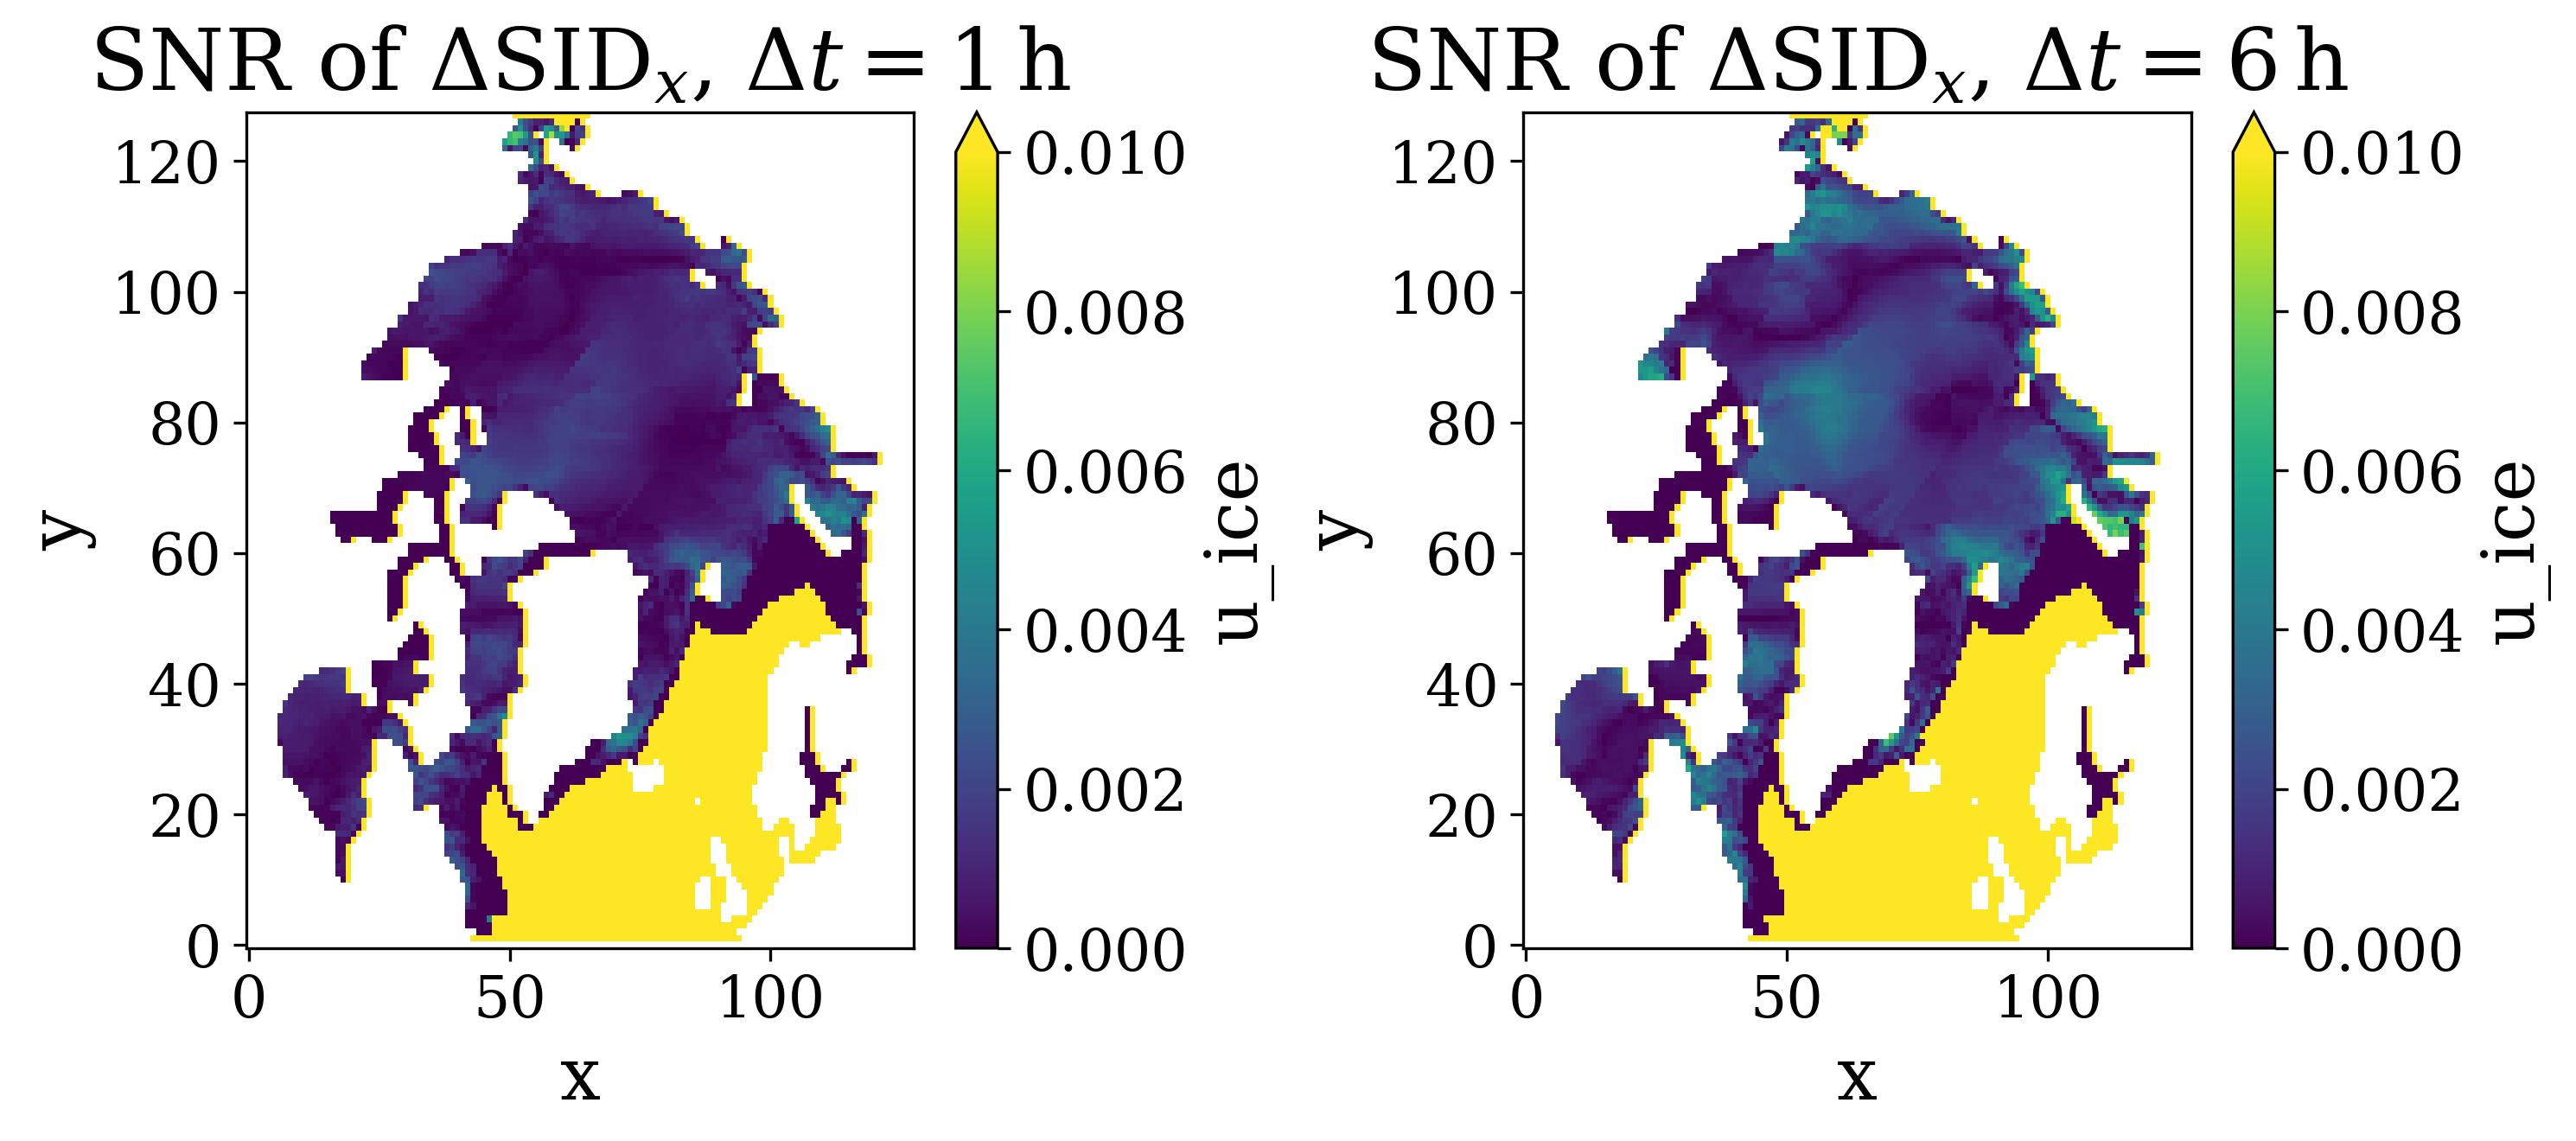

In [42]:
snr_1h_x_plot = snr_1h_x.where(xr.DataArray(ocean_mask_1h, dims=snr_1h_x.dims))
snr_6h_x_plot = snr_6h_x.where(xr.DataArray(ocean_mask_6h, dims=snr_6h_x.dims))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
vmax = 0.01
cmap = plt.cm.viridis.copy()
cmap.set_bad("white")  # land / masked pixels render as white, not yellow

snr_1h_x_plot.plot(ax=axes[0], vmin=0, vmax=vmax, cmap=cmap, add_colorbar=True)
axes[0].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 1\,$h")
snr_6h_x_plot.plot(ax=axes[1], vmin=0, vmax=vmax, cmap=cmap, add_colorbar=True)
axes[1].set_title(r"SNR of $\Delta\mathrm{SID}_x$, $\Delta t = 6\,$h")
plt.tight_layout()
plt.savefig("snr_maps_sid_x.png", dpi=150)

Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: 0.872
Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: 0.930


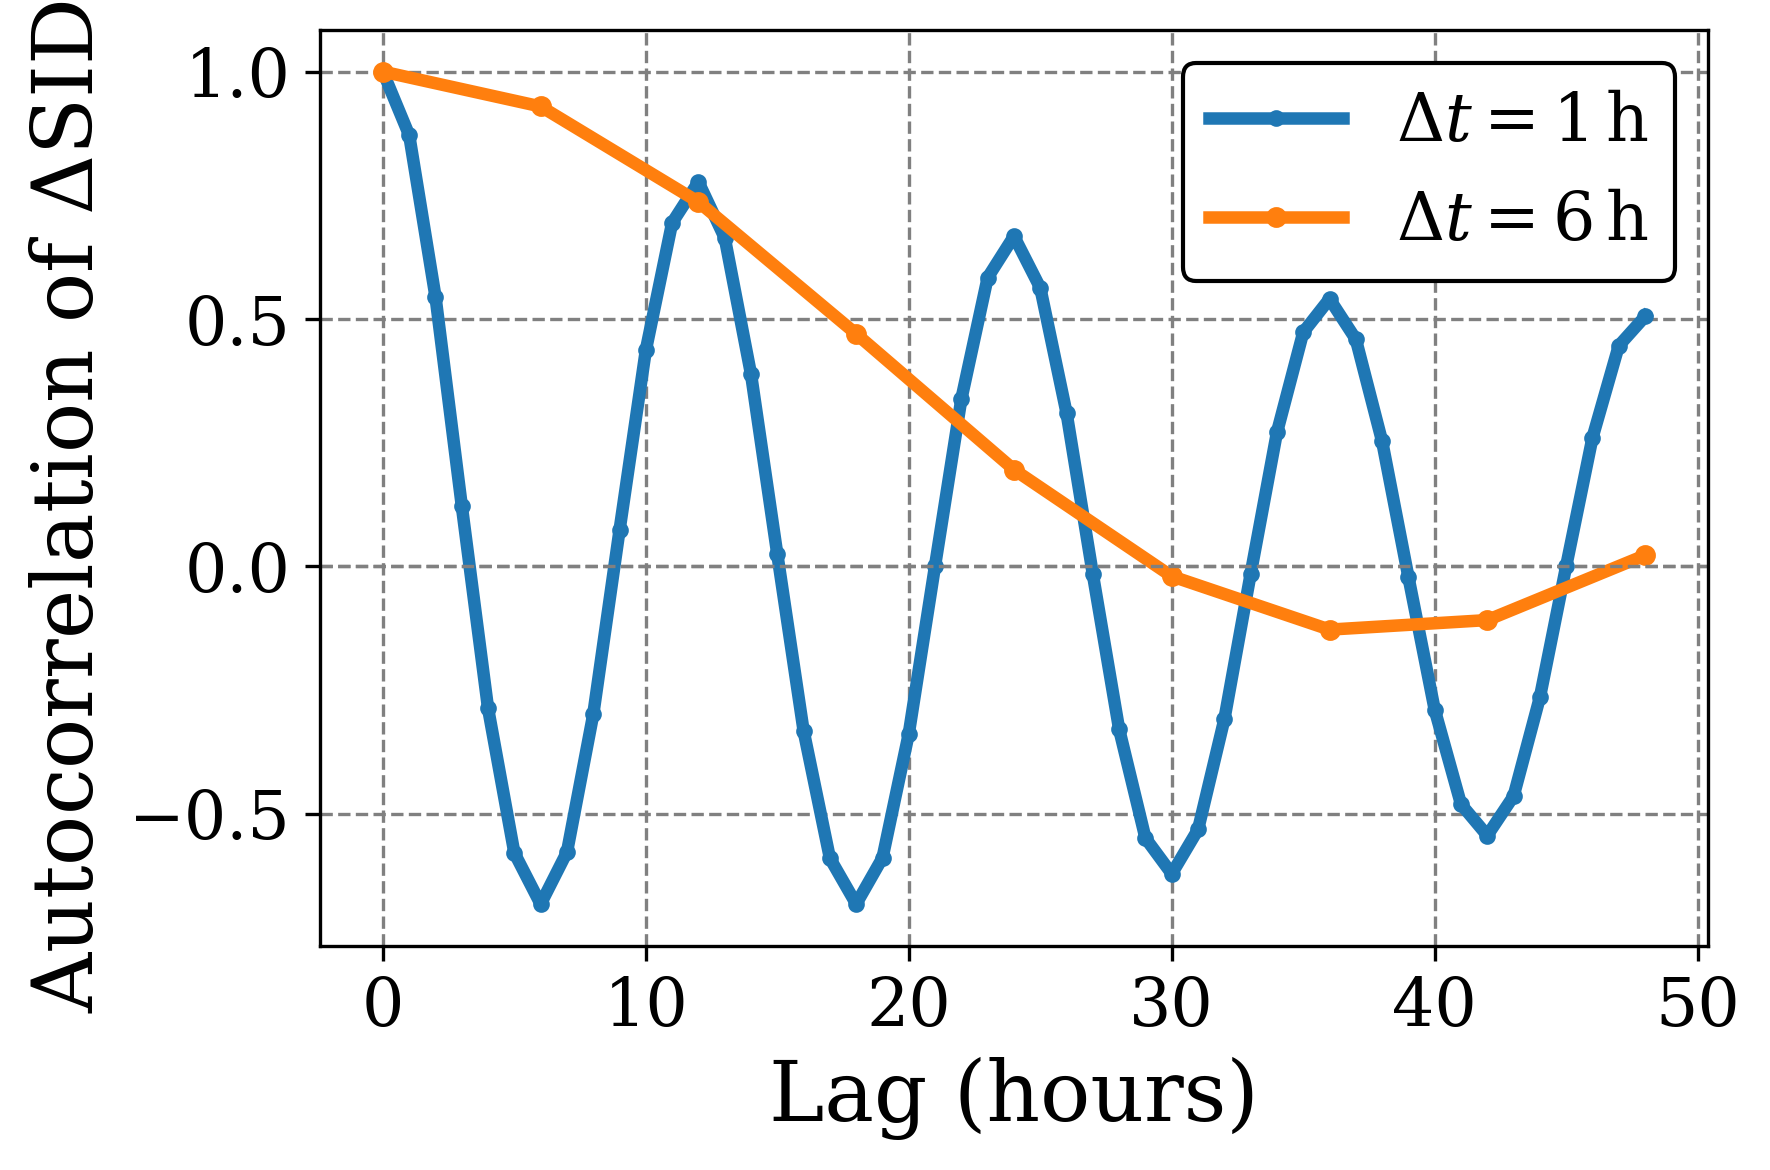

In [10]:
def acf(ts, max_lag):
    """
    Autocorrelation function of a 1D time series for lags 0..max_lag.
    Returns an array of length max_lag + 1, with acf[0] = 1.
    """
    ts = np.asarray(ts)
    ts = ts - np.nanmean(ts)
    n = len(ts)
    var = np.nanvar(ts)
    out = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        if lag == 0:
            out[lag] = 1.0
        else:
            cov = np.nanmean(ts[:n - lag] * ts[lag:])
            out[lag] = cov / var
    return out
# Spatial mean restricted to ocean pixels only
spatial_dims_1h = spatial_dims_of(ds_1h_output[SID_X])
spatial_dims_6h = spatial_dims_of(ds_6h_output[SID_X])
 
mask_da_1h = mask_as_dataarray(ocean_mask_1h, ds_1h_output[SID_X])
mask_da_6h = mask_as_dataarray(ocean_mask_6h, ds_6h_output[SID_X])
 
ts_1h_x = ds_1h_output[SID_X].where(mask_da_1h).mean(dim=spatial_dims_1h, skipna=True).values
ts_6h_x = ds_6h_output[SID_X].where(mask_da_6h).mean(dim=spatial_dims_6h, skipna=True).values
 
# Choose max_lag so both curves span a comparable physical duration.
# E.g. 48 lags at 1h = 48h, 8 lags at 6h = 48h -- adjust as needed.
max_lag_hours = 48
max_lag_1h = max_lag_hours // 1
max_lag_6h = max_lag_hours // 6
 
acf_1h_x = acf(ts_1h_x, max_lag_1h)
acf_6h_x = acf(ts_6h_x, max_lag_6h)
 
lags_1h_hours = np.arange(max_lag_1h + 1) * 1
lags_6h_hours = np.arange(max_lag_6h + 1) * 6
 
print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 1h: {acf_1h_x[1]:.3f}")
print(f"Lag-1 autocorrelation of domain-avg SID_x tendency, 6h: {acf_6h_x[1]:.3f}")
 
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lags_1h_hours, acf_1h_x, marker="o", markersize=3,
        label=r"$\Delta t = 1\,$h")
ax.plot(lags_6h_hours, acf_6h_x, marker="o", markersize=4,
        label=r"$\Delta t = 6\,$h")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel(r"Autocorrelation of $\Delta\mathrm{SID}_x$")
#ax.set_title("Tendency autocorrelation vs. lag")
ax.legend()
plt.tight_layout()
plt.savefig("acf_vs_lag.png", dpi=150)

Lag-1 ACF (spatial-mean-first), 1h: 0.872
Lag-1 ACF (spatial-mean-first), 6h: 0.930
Lag-1 ACF (pixel-wise, then averaged), 1h: 0.746
Lag-1 ACF (pixel-wise, then averaged), 6h: 0.955


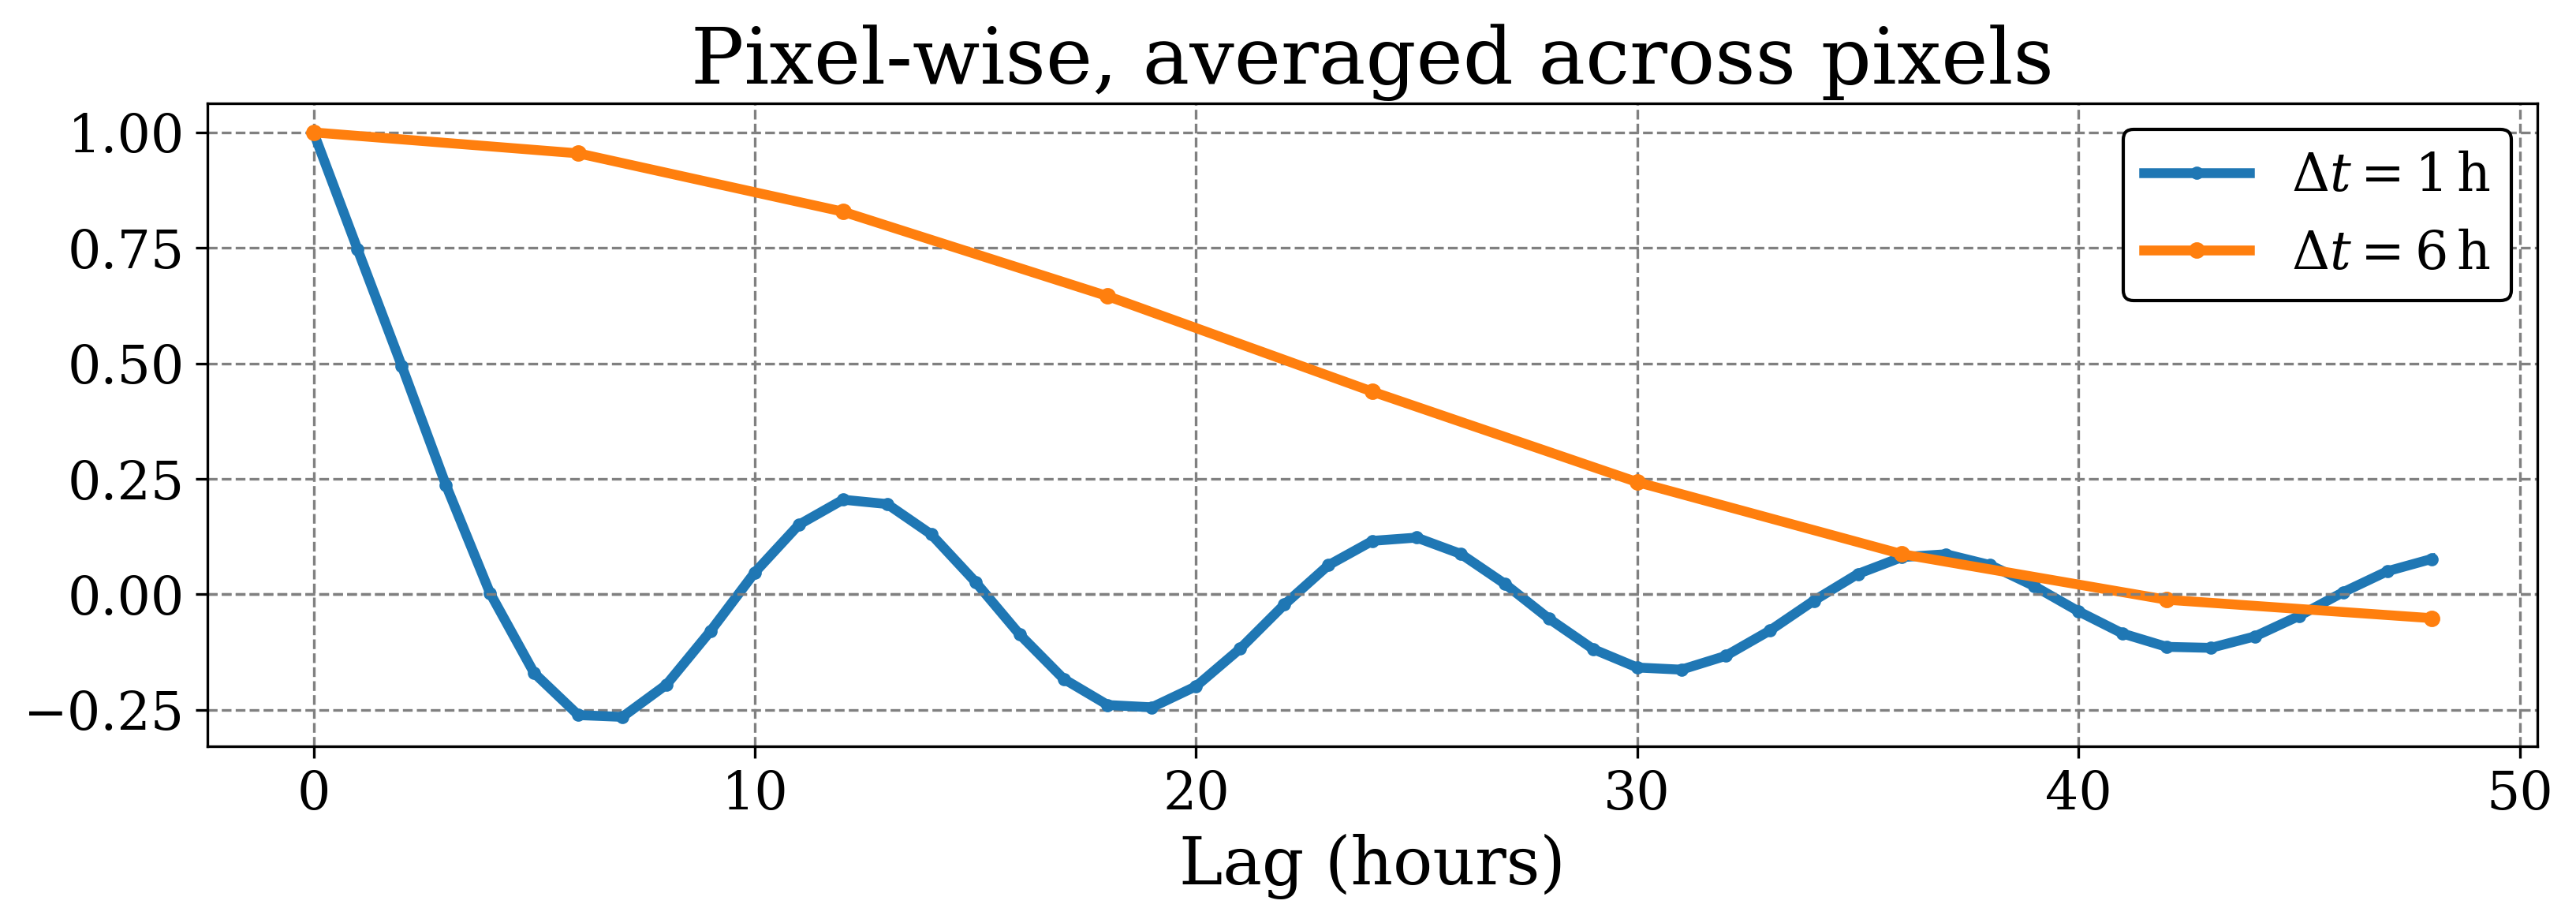

In [11]:
def acf_pixelwise(da, ocean_mask, max_lag, time_dim="time"):
    """
    Compute the ACF independently at each spatial pixel (time series
    along `time_dim`), then average the resulting ACF curves across
    all ocean pixels.
 
    `da` is assumed to have `time_dim` plus exactly the spatial dims
    matched by `ocean_mask`. Returns an array of length max_lag + 1.
    """
    sdims = spatial_dims_of(da, time_dim)
    # Move time to the first axis, flatten spatial dims afterward
    arr = da.transpose(time_dim, *sdims).values  # shape (T, *spatial)
    T = arr.shape[0]
    arr_flat = arr.reshape(T, -1)               # shape (T, P)
    mask_flat = ocean_mask.reshape(-1)          # shape (P,)
 
    ocean_idx = np.where(mask_flat)[0]
    arr_ocean = arr_flat[:, ocean_idx]          # shape (T, P_ocean)
 
    # Demean each pixel's time series
    arr_ocean = arr_ocean - np.nanmean(arr_ocean, axis=0, keepdims=True)
    var_ocean = np.nanvar(arr_ocean, axis=0)    # shape (P_ocean,)
    valid = var_ocean > 0                       # drop dead/constant pixels
 
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        cov = np.nanmean(
            arr_ocean[:T - lag, valid] * arr_ocean[lag:, valid], axis=0
        )
        pixel_acf = cov / var_ocean[valid]
        out[lag] = np.nanmean(pixel_acf)
    return out
 

# Spatial mean restricted to ocean pixels only
spatial_dims_1h = spatial_dims_of(ds_1h_output[SID_X])
spatial_dims_6h = spatial_dims_of(ds_6h_output[SID_X])
 
mask_da_1h = mask_as_dataarray(ocean_mask_1h, ds_1h_output[SID_X])
mask_da_6h = mask_as_dataarray(ocean_mask_6h, ds_6h_output[SID_X])
 
ts_1h_x = ds_1h_output[SID_X].where(mask_da_1h).mean(dim=spatial_dims_1h, skipna=True).values
ts_6h_x = ds_6h_output[SID_X].where(mask_da_6h).mean(dim=spatial_dims_6h, skipna=True).values
 
# Choose max_lag so both curves span a comparable physical duration.
# E.g. 48 lags at 1h = 48h, 8 lags at 6h = 48h -- adjust as needed.
max_lag_hours = 48
max_lag_1h = max_lag_hours // 1
max_lag_6h = max_lag_hours // 6
 
# (a) spatial-mean-first ACF
acf_1h_x_meanfirst = acf(ts_1h_x, max_lag_1h)
acf_6h_x_meanfirst = acf(ts_6h_x, max_lag_6h)
 
# (b) pixel-wise ACF, averaged across pixels afterward
acf_1h_x_pixelwise = acf_pixelwise(ds_1h_output[SID_X], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise = acf_pixelwise(ds_6h_output[SID_X], ocean_mask_6h, max_lag_6h)
 
lags_1h_hours = np.arange(max_lag_1h + 1) * 1
lags_6h_hours = np.arange(max_lag_6h + 1) * 6
 
print(f"Lag-1 ACF (spatial-mean-first), 1h: {acf_1h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (spatial-mean-first), 6h: {acf_6h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 1h: {acf_1h_x_pixelwise[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 6h: {acf_6h_x_pixelwise[1]:.3f}")
 
fig, axes = plt.subplots(1, 1, figsize=(11, 4), sharey=True)
 
axes.plot(lags_1h_hours, acf_1h_x_pixelwise, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h")
axes.plot(lags_6h_hours, acf_6h_x_pixelwise, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h")
axes.axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes.set_xlabel("Lag (hours)")
axes.set_title("Pixel-wise, averaged across pixels")
axes.legend()
 
plt.tight_layout()
plt.savefig("acf_vs_lag.png", dpi=150)
 

Lag-1 ACF (spatial-mean-first), 1h: 0.999
Lag-1 ACF (spatial-mean-first), 6h: 0.999
Lag-1 ACF (pixel-wise, then averaged), 1h: 0.746
Lag-1 ACF (pixel-wise, then averaged), 6h: 0.955


NameError: name 'acf_1h_x_pixelwise_in' is not defined

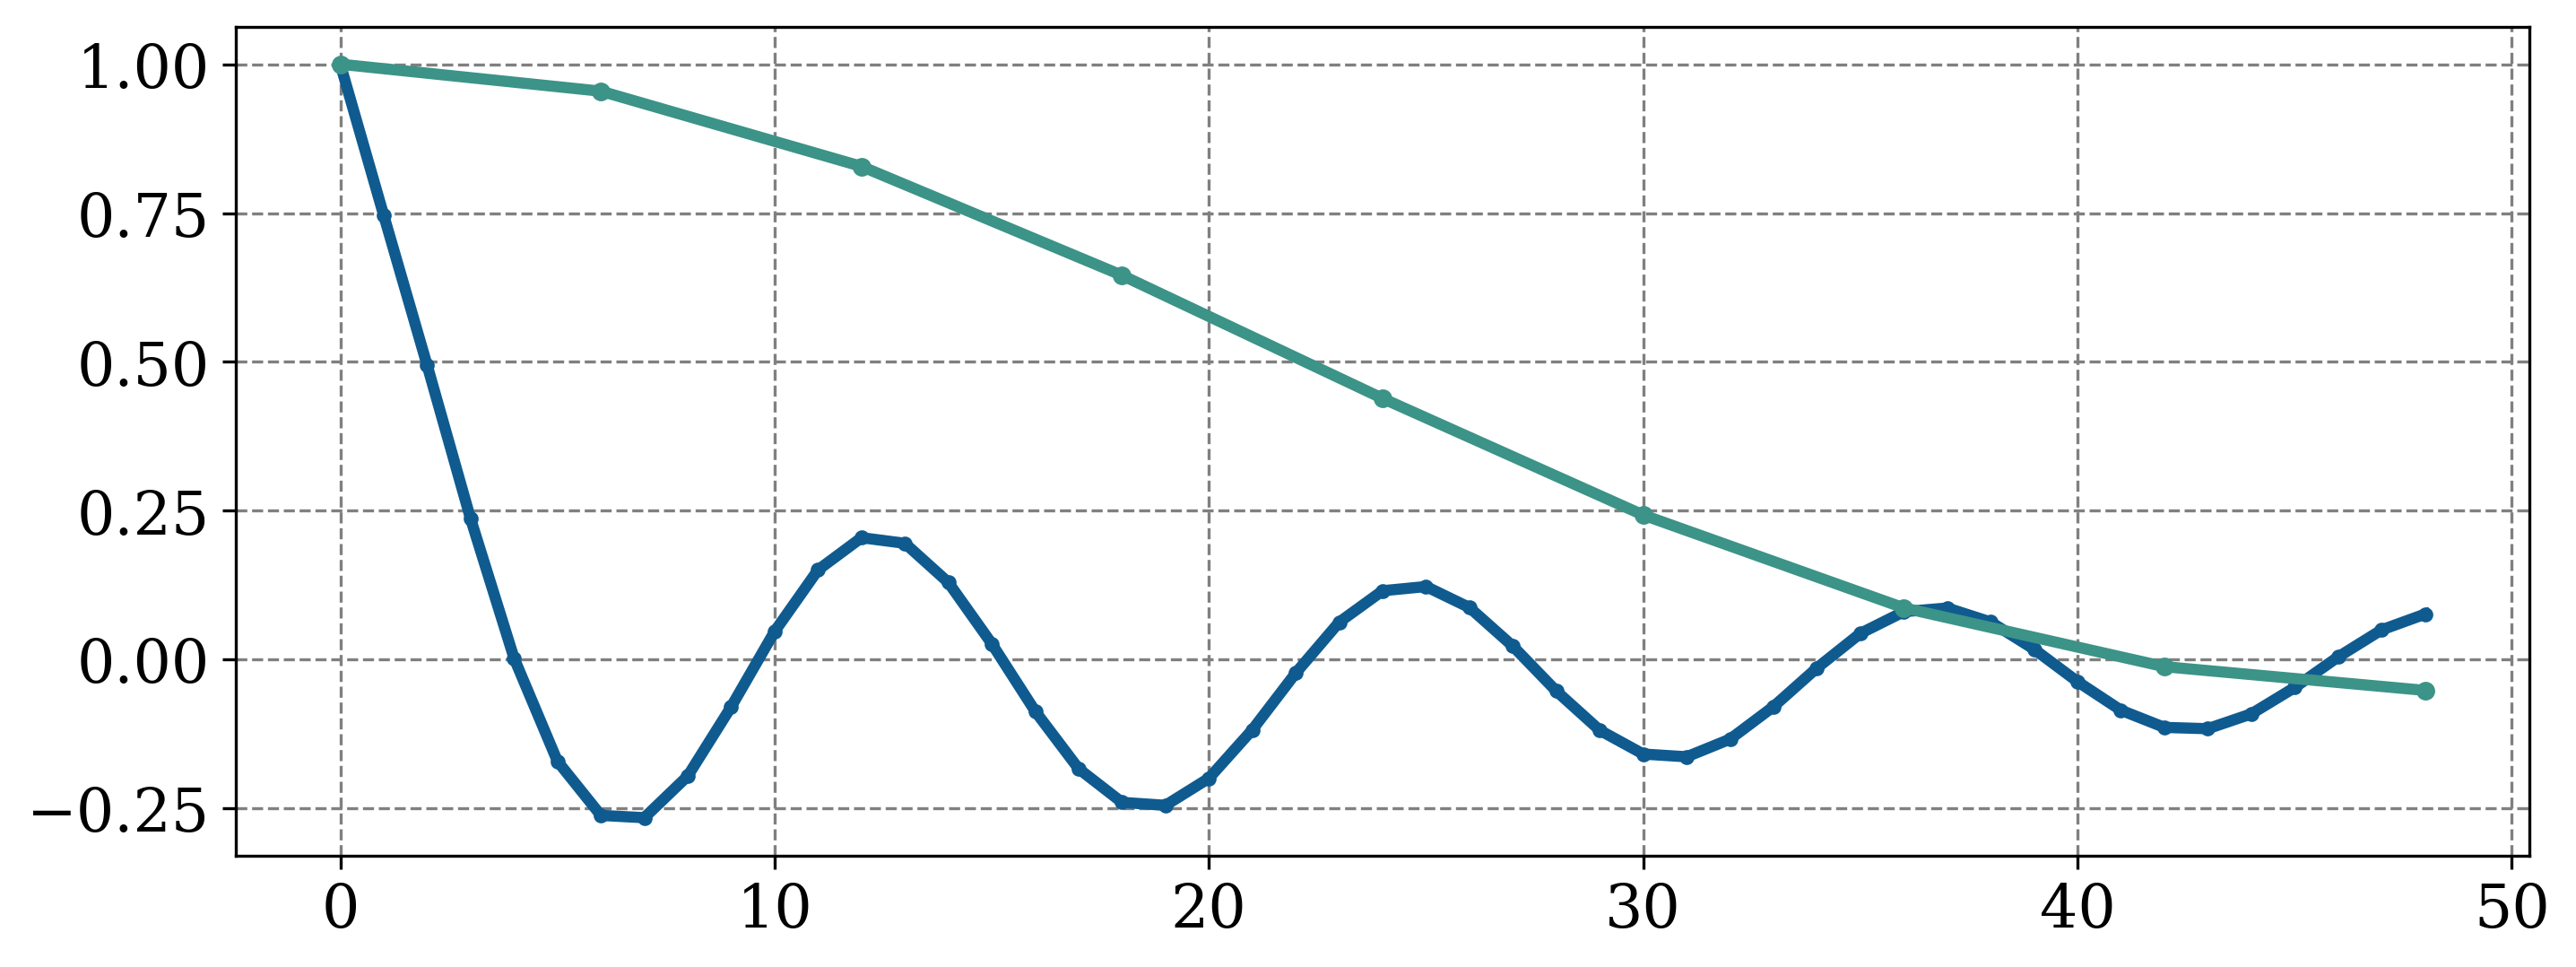

In [12]:
def acf_pixelwise(da, ocean_mask, max_lag, time_dim="time"):
    """
    Compute the ACF independently at each spatial pixel (time series
    along `time_dim`), then average the resulting ACF curves across
    all ocean pixels.
 
    `da` is assumed to have `time_dim` plus exactly the spatial dims
    matched by `ocean_mask`. Returns an array of length max_lag + 1.
    """
    sdims = spatial_dims_of(da, time_dim)
    # Move time to the first axis, flatten spatial dims afterward
    arr = da.transpose(time_dim, *sdims).values  # shape (T, *spatial)
    T = arr.shape[0]
    arr_flat = arr.reshape(T, -1)               # shape (T, P)
    mask_flat = ocean_mask.reshape(-1)          # shape (P,)
 
    ocean_idx = np.where(mask_flat)[0]
    arr_ocean = arr_flat[:, ocean_idx]          # shape (T, P_ocean)
 
    # Demean each pixel's time series
    arr_ocean = arr_ocean - np.nanmean(arr_ocean, axis=0, keepdims=True)
    var_ocean = np.nanvar(arr_ocean, axis=0)    # shape (P_ocean,)
    valid = var_ocean > 0                       # drop dead/constant pixels
 
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        cov = np.nanmean(
            arr_ocean[:T - lag, valid] * arr_ocean[lag:, valid], axis=0
        )
        pixel_acf = cov / var_ocean[valid]
        out[lag] = np.nanmean(pixel_acf)
    return out
 
SIV = "sivolu"
# Spatial mean restricted to ocean pixels only
spatial_dims_1h = spatial_dims_of(ds_1h_output[SIV])
spatial_dims_6h = spatial_dims_of(ds_6h_output[SIV])
 
mask_da_1h = mask_as_dataarray(ocean_mask_1h, ds_1h_output[SIV])
mask_da_6h = mask_as_dataarray(ocean_mask_6h, ds_6h_output[SIV])
 
ts_1h_x = ds_1h_output[SIV].where(mask_da_1h).mean(dim=spatial_dims_1h, skipna=True).values
ts_6h_x = ds_6h_output[SIV].where(mask_da_6h).mean(dim=spatial_dims_6h, skipna=True).values
 
# Choose max_lag so both curves span a comparable physical duration.
# E.g. 48 lags at 1h = 48h, 8 lags at 6h = 48h -- adjust as needed.
max_lag_hours = 48
max_lag_1h = max_lag_hours // 1
max_lag_6h = max_lag_hours // 6
 
# (a) spatial-mean-first ACF
acf_1h_x_meanfirst = acf(ts_1h_x, max_lag_1h)
acf_6h_x_meanfirst = acf(ts_6h_x, max_lag_6h)
 
# (b) pixel-wise ACF, averaged across pixels afterward
acf_1h_x_pixelwise_SIV = acf_pixelwise(ds_1h_output[SIV], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise_SIV = acf_pixelwise(ds_6h_output[SIV], ocean_mask_6h, max_lag_6h)
 
acf_1h_x_pixelwise_in_SIV = acf_pixelwise(ds_1h_input[SIV], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise_in_SIV = acf_pixelwise(ds_6h_input[SIV], ocean_mask_6h, max_lag_6h)

lags_1h_hours = np.arange(max_lag_1h + 1) * 1
lags_6h_hours = np.arange(max_lag_6h + 1) * 6
 
print(f"Lag-1 ACF (spatial-mean-first), 1h: {acf_1h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (spatial-mean-first), 6h: {acf_6h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 1h: {acf_1h_x_pixelwise[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 6h: {acf_6h_x_pixelwise[1]:.3f}")
 
fig, axes = plt.subplots(1, 1, figsize=(11, 4), sharey=True)
 
axes.plot(lags_1h_hours, acf_1h_x_pixelwise, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, tendencies", color = color_dict["1h"])
axes.plot(lags_6h_hours, acf_6h_x_pixelwise, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, tendencies", color = color_dict["6h"])
axes.plot(lags_1h_hours, acf_1h_x_pixelwise_in, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, full state", color = color_dict["1h"], linestyle = 'dashed' )
axes.plot(lags_6h_hours, acf_6h_x_pixelwise_in, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, full state", color = color_dict["6h"], linestyle = 'dashed' )
axes.axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes.set_xlabel("Lag (hours)")
axes.set_title("Pixel-wise, averaged across pixels")
axes.legend()
 
plt.tight_layout()
plt.savefig("acf_vs_lag_siv.png", dpi=150)
 

Lag-1 ACF (spatial-mean-first), 1h: 0.872
Lag-1 ACF (spatial-mean-first), 6h: 0.930
Lag-1 ACF (pixel-wise, then averaged), 1h: 0.746
Lag-1 ACF (pixel-wise, then averaged), 6h: 0.955


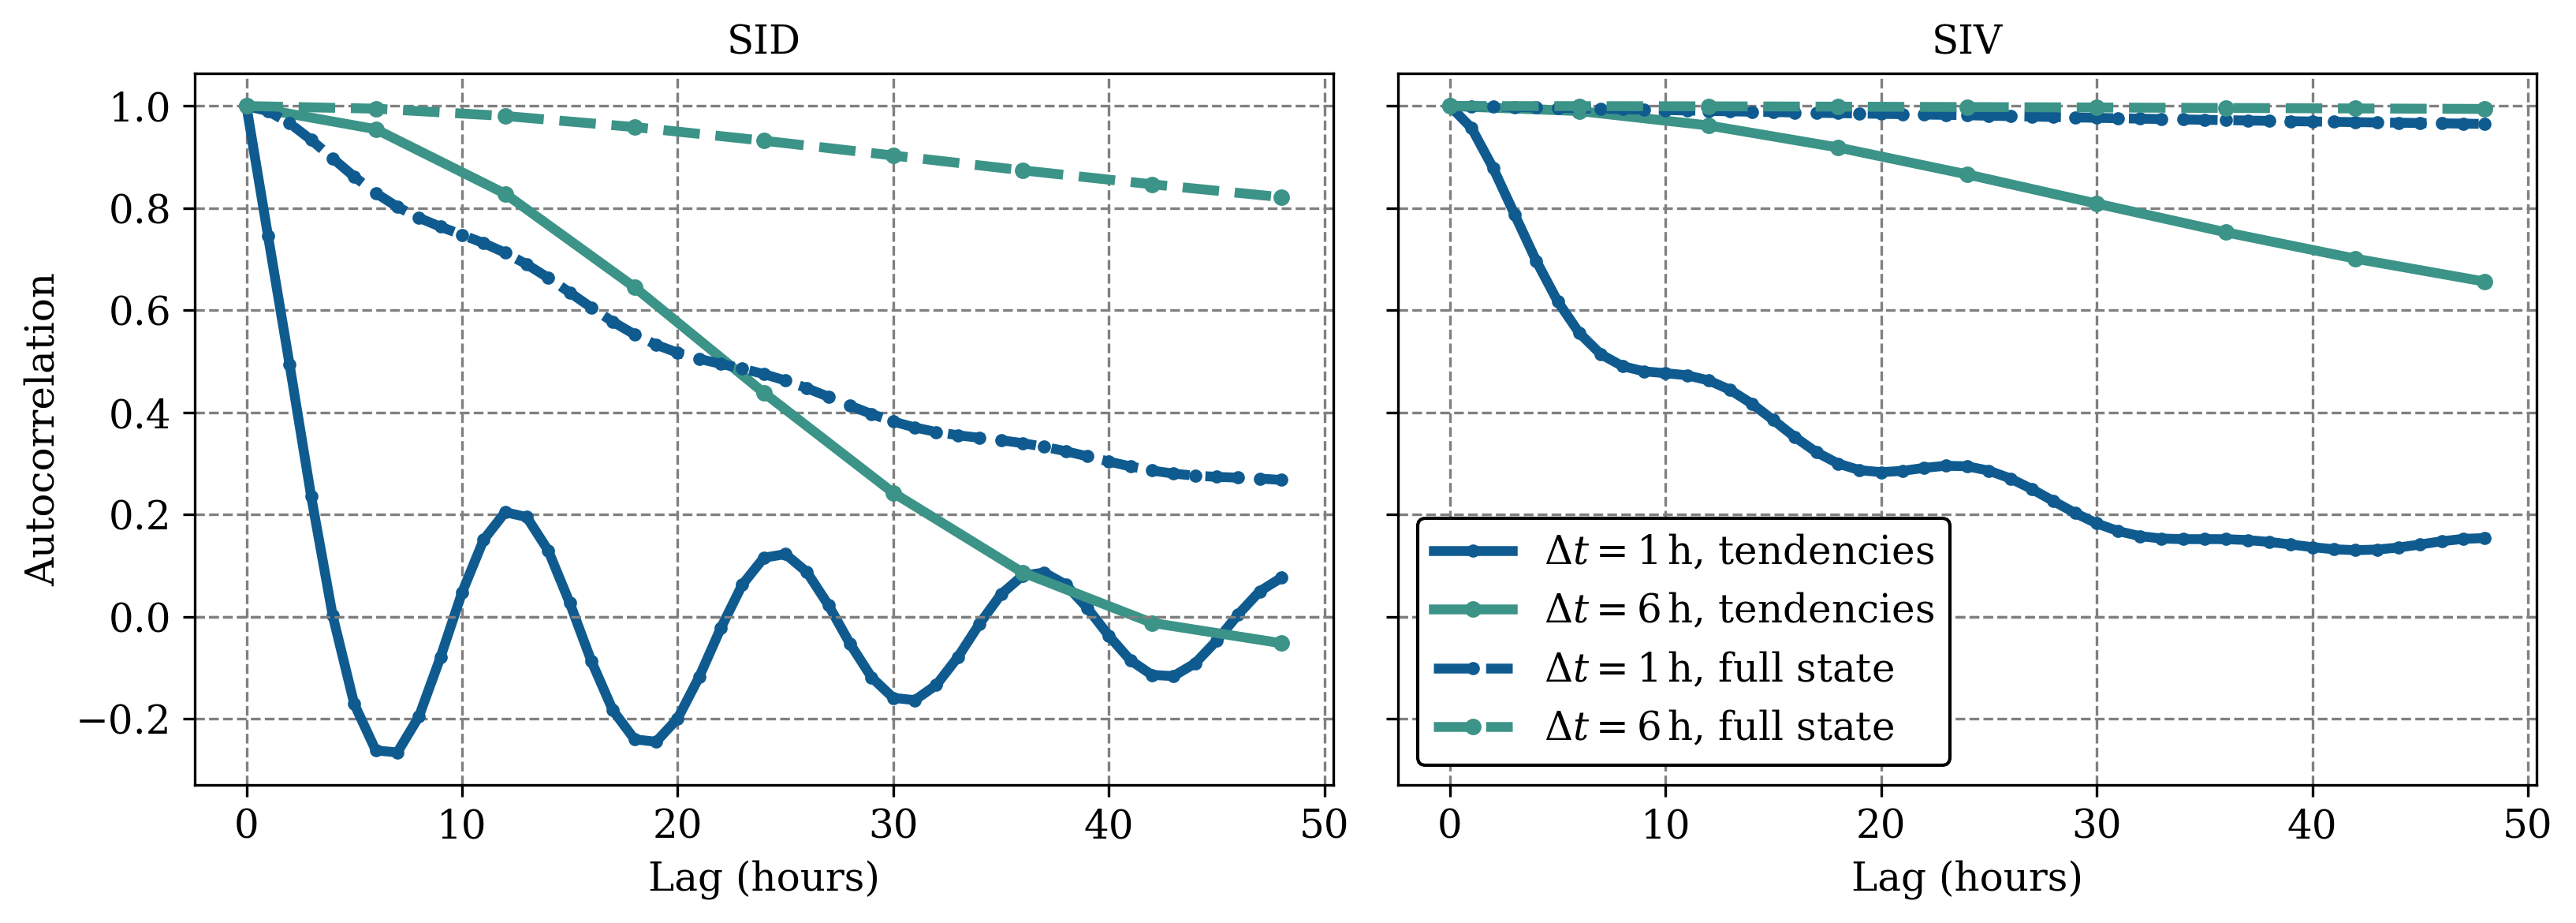

In [13]:
def acf_pixelwise(da, ocean_mask, max_lag, time_dim="time"):
    """
    Compute the ACF independently at each spatial pixel (time series
    along `time_dim`), then average the resulting ACF curves across
    all ocean pixels.
 
    `da` is assumed to have `time_dim` plus exactly the spatial dims
    matched by `ocean_mask`. Returns an array of length max_lag + 1.
    """
    sdims = spatial_dims_of(da, time_dim)
    # Move time to the first axis, flatten spatial dims afterward
    arr = da.transpose(time_dim, *sdims).values  # shape (T, *spatial)
    T = arr.shape[0]
    arr_flat = arr.reshape(T, -1)               # shape (T, P)
    mask_flat = ocean_mask.reshape(-1)          # shape (P,)
 
    ocean_idx = np.where(mask_flat)[0]
    arr_ocean = arr_flat[:, ocean_idx]          # shape (T, P_ocean)
 
    # Demean each pixel's time series
    arr_ocean = arr_ocean - np.nanmean(arr_ocean, axis=0, keepdims=True)
    var_ocean = np.nanvar(arr_ocean, axis=0)    # shape (P_ocean,)
    valid = var_ocean > 0                       # drop dead/constant pixels
 
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        cov = np.nanmean(
            arr_ocean[:T - lag, valid] * arr_ocean[lag:, valid], axis=0
        )
        pixel_acf = cov / var_ocean[valid]
        out[lag] = np.nanmean(pixel_acf)
    return out
 
SIV = "sivolu"
# Spatial mean restricted to ocean pixels only
spatial_dims_1h = spatial_dims_of(ds_1h_output[SID_X])
spatial_dims_6h = spatial_dims_of(ds_6h_output[SID_X])
 
mask_da_1h = mask_as_dataarray(ocean_mask_1h, ds_1h_output[SID_X])
mask_da_6h = mask_as_dataarray(ocean_mask_6h, ds_6h_output[SID_X])
 
ts_1h_x = ds_1h_output[SID_X].where(mask_da_1h).mean(dim=spatial_dims_1h, skipna=True).values
ts_6h_x = ds_6h_output[SID_X].where(mask_da_6h).mean(dim=spatial_dims_6h, skipna=True).values
 
# Choose max_lag so both curves span a comparable physical duration.
# E.g. 48 lags at 1h = 48h, 8 lags at 6h = 48h -- adjust as needed.
max_lag_hours = 48
max_lag_1h = max_lag_hours // 1
max_lag_6h = max_lag_hours // 6
 
# (a) spatial-mean-first ACF
acf_1h_x_meanfirst = acf(ts_1h_x, max_lag_1h)
acf_6h_x_meanfirst = acf(ts_6h_x, max_lag_6h)
 
# (b) pixel-wise ACF, averaged across pixels afterward
acf_1h_x_pixelwise = acf_pixelwise(ds_1h_output[SID_X], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise = acf_pixelwise(ds_6h_output[SID_X], ocean_mask_6h, max_lag_6h)
 
acf_1h_x_pixelwise_in = acf_pixelwise(ds_1h_input[SID_X], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise_in = acf_pixelwise(ds_6h_input[SID_X], ocean_mask_6h, max_lag_6h)

lags_1h_hours = np.arange(max_lag_1h + 1) * 1
lags_6h_hours = np.arange(max_lag_6h + 1) * 6
 
print(f"Lag-1 ACF (spatial-mean-first), 1h: {acf_1h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (spatial-mean-first), 6h: {acf_6h_x_meanfirst[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 1h: {acf_1h_x_pixelwise[1]:.3f}")
print(f"Lag-1 ACF (pixel-wise, then averaged), 6h: {acf_6h_x_pixelwise[1]:.3f}")
# (b) pixel-wise ACF, averaged across pixels afterward
acf_1h_x_pixelwise_SIV = acf_pixelwise(ds_1h_output[SIV], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise_SIV = acf_pixelwise(ds_6h_output[SIV], ocean_mask_6h, max_lag_6h)
 
acf_1h_x_pixelwise_in_SIV = acf_pixelwise(ds_1h_input[SIV], ocean_mask_1h, max_lag_1h)
acf_6h_x_pixelwise_in_SIV = acf_pixelwise(ds_6h_input[SIV], ocean_mask_6h, max_lag_6h)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
 
axes[0].plot(lags_1h_hours, acf_1h_x_pixelwise, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, tendencies", color = color_dict["1h"])
axes[0].plot(lags_6h_hours, acf_6h_x_pixelwise, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, tendencies", color = color_dict["6h"])
axes[0].plot(lags_1h_hours, acf_1h_x_pixelwise_in, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, full state", color = color_dict["1h"], linestyle = 'dashed' )
axes[0].plot(lags_6h_hours, acf_6h_x_pixelwise_in, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, full state", color = color_dict["6h"], linestyle = 'dashed' )
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Lag (hours)", fontsize = 12)
axes[0].set_title("SID", fontsize = 12)

axes[1].plot(lags_1h_hours, acf_1h_x_pixelwise_SIV, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, tendencies", color = color_dict["1h"])
axes[1].plot(lags_6h_hours, acf_6h_x_pixelwise_SIV, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, tendencies", color = color_dict["6h"])
axes[1].plot(lags_1h_hours, acf_1h_x_pixelwise_in_SIV, marker="o", markersize=3,
             label=r"$\Delta t = 1\,$h, full state", color = color_dict["1h"], linestyle = 'dashed' )
axes[1].plot(lags_6h_hours, acf_6h_x_pixelwise_in_SIV, marker="o", markersize=4,
             label=r"$\Delta t = 6\,$h, full state", color = color_dict["6h"], linestyle = 'dashed' )
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Lag (hours)", fontsize = 12)
axes[1].set_title("SIV", fontsize = 12)
axes[1].legend(fontsize = 12)

axes[0].set_ylabel("Autocorrelation", fontsize = 12)
#axes[1].set_ylabel("Autocorrelation", fontsize = 12)

axes[0].tick_params(axis='both', labelsize=12)
axes[1].tick_params(axis='both', labelsize=12)

axes[0].tick_params(axis='both', labelsize=12)
axes[1].tick_params(axis='both', labelsize=12)


plt.tight_layout()
plt.savefig("acf_vs_lag_sid_siv.pdf")
 